<span style="color:steelblue; text-align: left">

## What is Churn?
</span>

Churn refers to the loss of customers over a given period and represents a critical metric for subscription-based and service-oriented businesses. In practical terms, a churn event occurs when a customer stops purchasing a product, cancels a service, or ceases engagement with a platform.

The definition of churn varies according to the business model. In contractual settings, churn is directly observed through subscription cancellations. In non-contractual environments, it must be inferred from customer inactivity patterns, requiring deeper analytical treatment.

Churn can also be classified as voluntary or involuntary. Voluntary churn reflects a deliberate decision by the customer to discontinue the service, whereas involuntary churn occurs due to operational issues such as payment failures or expired billing information.

Understanding churn dynamics is essential for sustainable growth, as unmanaged customer attrition can significantly erode revenue and compromise long-term profitability.

<span style="color:steelblue; text-align: left">

## Impact of Churn on Annual Revenue
</span>

Even relatively low churn rates can produce substantial financial impact due to their cumulative effect over time. For instance, a company generating $50 million in annual recurring revenue (ARR) with a monthly churn rate of 2% would incur approximately $12 million in lost revenue over the course of a year.

This illustrates how churn, even at seemingly acceptable levels, can materially affect business performance if not actively managed.

<span style="color:steelblue; text-align: left">

## Business Problem
</span>

Customer churn has a direct and measurable impact on revenue. From a strategic perspective, retaining existing customers is typically more cost-efficient than acquiring new ones, making churn reduction a key lever for improving profitability.

The objective of this project is to identify customers at higher risk of churn and generate insights that support targeted retention strategies.


<span style="color:steelblue; text-align: left">

## Import modules and set parameters
</span>

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.ticker import MaxNLocator, NullFormatter, FuncFormatter

#from feature_engine.encoding import OrdinalEncoder

# Remove warnings
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

RANDOM_SEED = 738
np.random.seed(RANDOM_SEED)

Funções de apoio gráfico

In [2]:
def set_corporate_theme():
    """
    Corporate plotting theme inspired by editorial / financial charts,
    preserving strong readability.
    """
    sns.set_theme(style="ticks")

    mpl.rcParams['figure.dpi'] = 96
    mpl.rcParams['figure.figsize'] = (13.33, 6.5)

    # Titles
    mpl.rcParams['figure.titlesize'] = 22
    mpl.rcParams['figure.titleweight'] = 'bold'
    mpl.rcParams['axes.titlesize'] = 22
    mpl.rcParams['axes.titleweight'] = 'bold'
    mpl.rcParams['axes.titlepad'] = 20

    # Axis labels
    mpl.rcParams['axes.labelsize'] = 20
    mpl.rcParams['axes.labelweight'] = 'bold'

    # Axes / grid
    mpl.rcParams['axes.spines.right'] = False
    mpl.rcParams['axes.spines.left'] = False
    mpl.rcParams['axes.spines.top'] = False
    mpl.rcParams['axes.grid'] = True
    mpl.rcParams['axes.grid.axis'] = 'y'
    mpl.rcParams['grid.alpha'] = 0.45
    mpl.rcParams['grid.linewidth'] = 1.0
    mpl.rcParams['ytick.left'] = False

    # Legend
    mpl.rcParams['legend.title_fontsize'] = 14
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['legend.frameon'] = True
    mpl.rcParams['legend.framealpha'] = 1
    mpl.rcParams['legend.fancybox'] = True
    mpl.rcParams['legend.facecolor'] = 'white'
    mpl.rcParams['legend.edgecolor'] = 'gray'
    mpl.rcParams['legend.borderpad'] = 0.6

    # Lines / markers
    mpl.rcParams['lines.linewidth'] = 3
    mpl.rcParams['lines.markersize'] = 10

    # Pandas display
    pd.set_option('display.max_rows', 3000)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 2000)
    pd.options.display.max_colwidth = 1000


def add_corporate_header(
    fig,
    title,
    subtitle=None,
    x=0.015,
    y_title=0.93,
    y_subtitle=0.885,
    title_size=22,
    subtitle_size=16
):
    """
    Add a clean editorial-style title/subtitle without decorative line.
    """
    fig.text(
        x=x,
        y=y_title,
        s=title,
        ha='left',
        va='bottom',
        fontsize=title_size,
        fontweight='bold',
        color='#4a4a4a'
    )

    if subtitle:
        fig.text(
            x=x,
            y=y_subtitle,
            s=subtitle,
            ha='left',
            va='bottom',
            fontsize=subtitle_size,
            color='#4a4a4a'
        )


def add_corporate_footer(
    fig,
    text=None,
    enabled=False,
    x=0.08,
    y=0.04,
    fontsize=10,
    color="#4a4a4a"
):
    """
    Optional short footer note / insight.
    """
    if enabled and text:
        fig.text(
            x=x,
            y=y,
            s=text,
            ha='left',
            va='bottom',
            fontsize=fontsize,
            color=color
        )
        fig.subplots_adjust(bottom=0.15)
        #fig.text(0.08, 0.04, text, fontsize=10, alpha=0.7)

def format_corporate_axes(
    ax,
    hide_y_spine_only=False,
    hide_y_entirely=False,
    grid=True,
    grid_axis='y'
):
    """
    Axis formatter with three useful modes:
    - default: normal axes
    - hide_y_spine_only=True: hides left spine/tick marks, keeps y labels
    - hide_y_entirely=True: hides y axis completely
    """
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if hide_y_entirely:
        ax.get_yaxis().set_visible(False)
        ax.spines['left'].set_visible(False)
    elif hide_y_spine_only:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', left=False, labelleft=True)

    ax.tick_params(axis='x', labelsize=11, length=6, width=1.0, color="#2b2b2b")
    ax.tick_params(axis='y', labelsize=11, length=0, width=0.0, color="#2b2b2b")

    if grid:
        ax.grid(True, axis=grid_axis, alpha=0.45, linewidth=1.0, color="#bdbdbd")
    else:
        ax.grid(False)

<span style="color:steelblue; text-align: center">

## Customer Churn Prediction
</span>

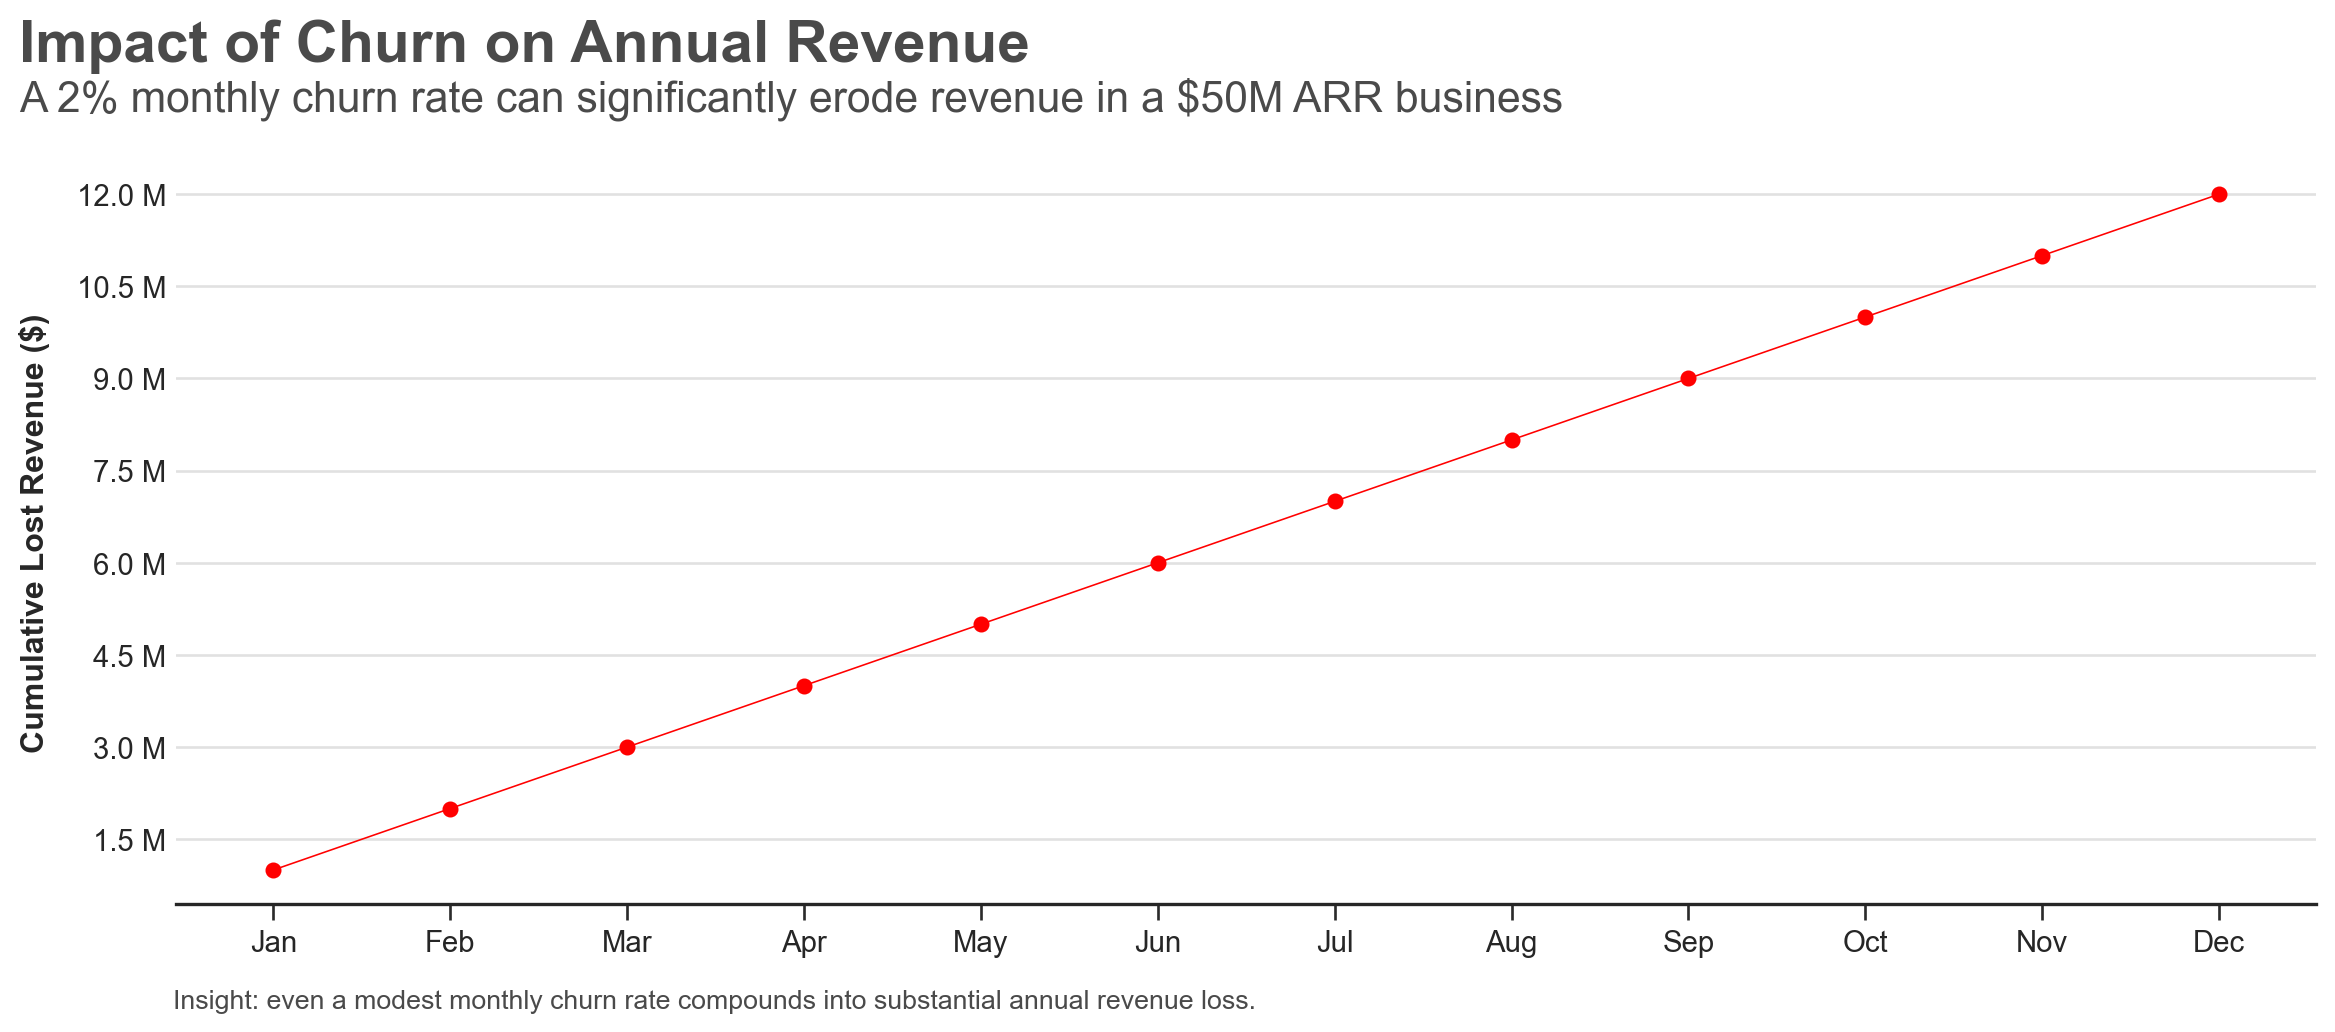

In [3]:
def plot_annual_churn_impact(
    annual_revenue=50_000_000,
    churn_rate=0.02,
    title="Impact of Churn on Annual Revenue",
    subtitle=None,
    footer_text=None,
    show_footer=False,
    line_color='red'
):
    """
    Plot cumulative annual revenue loss under a fixed monthly churn rate.

    Parameters
    ----------
    annual_revenue : int or float
        Annual recurring revenue.
    churn_rate : float
        Monthly churn rate (e.g., 0.02 for 2%).
    title : str
        Main chart title.
    subtitle : str or None
        Subtitle shown below the title.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    line_color : str
        Line color.
    """

    def revenue_formatter(x, pos):
        return f"{x / 1e6:.1f} M"

    # monthly and cumulative loss
    monthly_lost_revenue = annual_revenue * churn_rate
    cumulative_lost_revenue = [monthly_lost_revenue * i for i in range(1, 13)]

    months = list(range(1, 13))
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    fig, ax = plt.subplots(figsize=(12.33, 5.5), dpi=96)

    ax.plot(
        months,
        cumulative_lost_revenue,
        marker='.',
        color=line_color,
        linewidth=.6
    )

    # axes
    ax.set_ylabel('Cumulative Lost Revenue ($)', fontsize=12, labelpad=10)
    ax.set_xlabel('')
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)

    ax.yaxis.set_major_formatter(FuncFormatter(revenue_formatter))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # keep old-school readability: no left spine, but y labels remain
    format_corporate_axes(
        ax,
        hide_y_spine_only=True,
        hide_y_entirely=False,
        grid=True,
        grid_axis='y'
    )

    if subtitle is None:
        subtitle = (
            f"A {churn_rate:.0%} monthly churn rate can significantly erode "
            f"revenue in a ${annual_revenue/1e6:.0f}M ARR business"
        )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
set_corporate_theme()

plot_annual_churn_impact(
    annual_revenue=50_000_000,
    churn_rate=0.02,
    footer_text="Insight: even a modest monthly churn rate compounds into substantial annual revenue loss.",
    show_footer=True
)    

*A graph showing the cumulative revenue loss over 12 months under a 2% monthly churn rate. Each point represents the accumulated loss up to that month.*

<span style="color:steelblue; text-align: left">

### Types of Churn
</span>

Churn differs depending on the business model:

- **Contractual churn**: occurs when the customer explicitly cancels a subscription or service.
- **Non-contractual churn**: occurs when the customer simply stops purchasing or engaging, without any formal cancellation.

<span style="color:steelblue; text-align: left">

### Modeling Churn
</span>

Non-contractual churn is harder to define and model because there is no explicit event. It must be inferred from behavior, such as inactivity over a defined period (e.g., no purchases within 30 days). This definition varies across customers and requires domain-specific assumptions.

In this project, we focus on **contractual churn** in a telecom context, where churn is clearly defined by contract termination.

<span style="color:steelblue; text-align: left">

### Encoding Churn
</span>

Churn is typically encoded as a binary variable:

- **1 = Churn**
- **0 = No Churn**

Datasets may use labels such as *Yes/No* or *Churn/No Churn*, but converting to binary format is standard practice for modeling.

<span style="color:steelblue; text-align: left">

## Dataset
</span> 

This analysis uses the [Telecom Customer Churn dataset](https://www.kaggle.com/datasets/puja19/telecom-customer-churn), which contains customer-level information on demographics, services, and churn status.

In [4]:
def read_data(path='./dataset/telco.csv'):
    df = pd.read_csv(path)
    return df


In [5]:
telecom = read_data()

# Basic checks
print(f"Shape: {telecom.shape}")
display(telecom['Churn'].value_counts())

Shape: (7043, 21)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<span style="color:steelblue; text-align: left">

### Exploring Churn Distribution
</span> 

An important first step is to verify whether the target variable is imbalanced, that is, whether one class is substantially more frequent than the other. In this dataset, approximately 26.5% of customers churned, while 73.5% did not.

This indicates a moderate class imbalance. The minority class is still well represented, so the dataset is not severely imbalanced. Nevertheless, class imbalance should be considered during model evaluation, especially when interpreting metrics such as accuracy, precision, recall, and F1-score.

In later stages, resampling strategies may be tested to assess whether they improve predictive performance for the churn class.

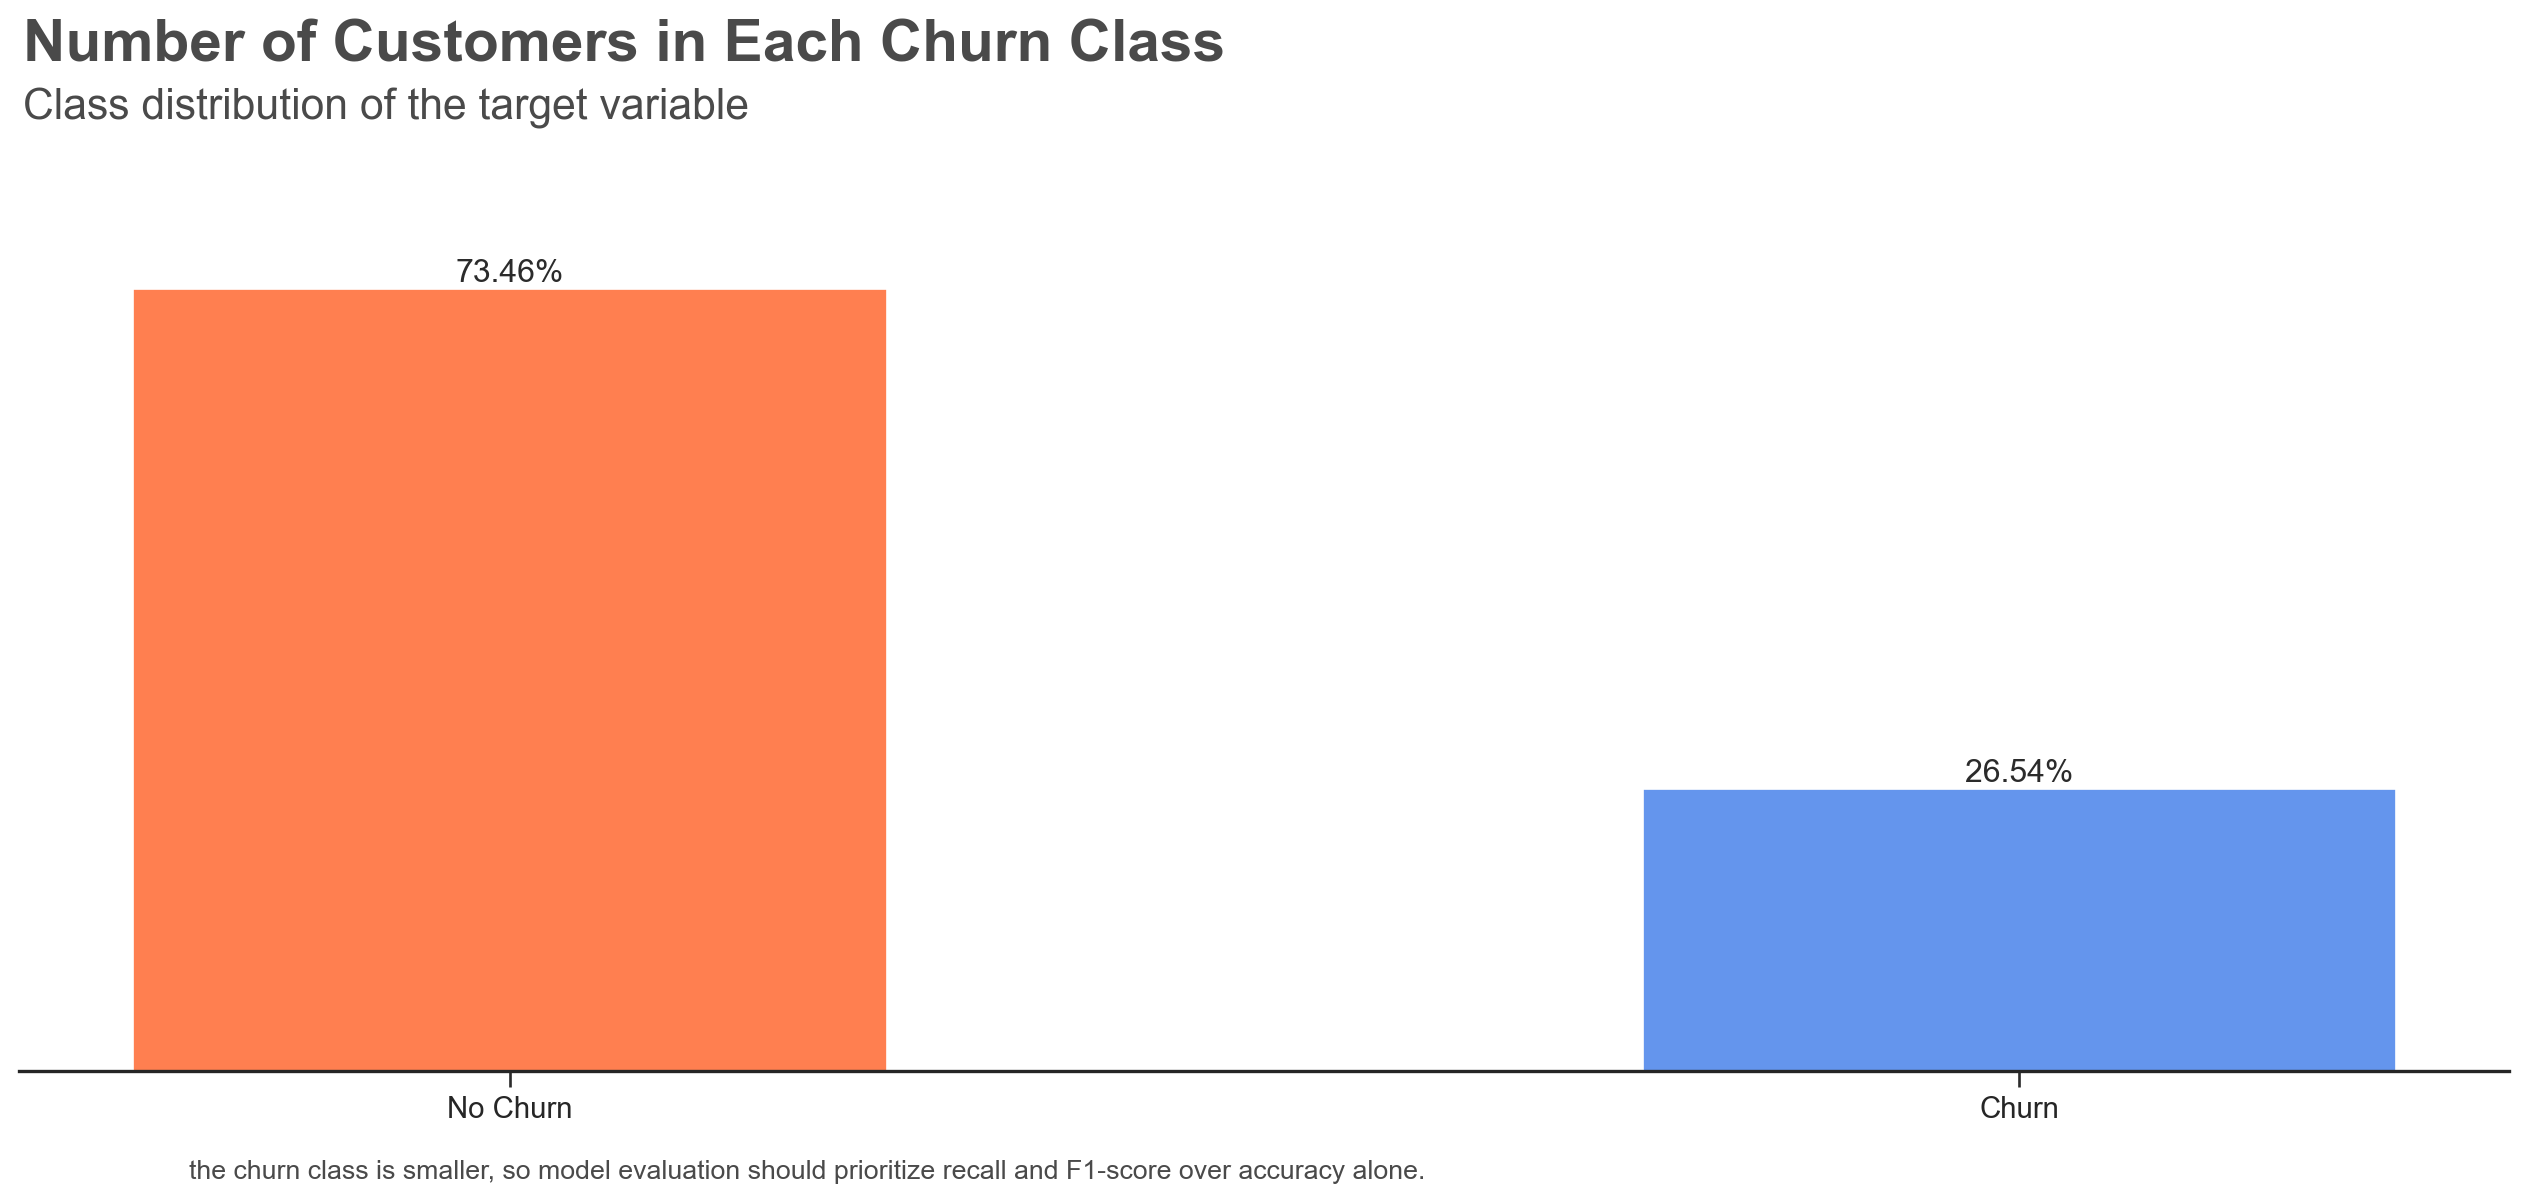

In [7]:
def plot_churn_distribution(
    df,
    churn_col='Churn',
    title="Number of Customers in Each Churn Class",
    subtitle="Class distribution of the target variable",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    """
    Plot churn class distribution as percentage bars.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    churn_col : str
        Name of the churn column.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    palette : tuple
        Colors for non-churn and churn classes.
    """

    # Compute distribution
    counts = df[churn_col].value_counts(normalize=True) * 100

    # Robust label mapping
    label_map = {
        'No': 'No Churn',
        'Yes': 'Churn',
        'No Churn': 'No Churn',
        'Churn': 'Churn',
        0: 'No Churn',
        1: 'Churn'
    }

    labels = [label_map.get(idx, str(idx)) for idx in counts.index]
    values = counts.values.tolist()

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, width=0.5, color=list(palette))

    # Bar labels
    ax.bar_label(bars, fmt='%.2f%%', fontsize=12, color="#2b2b2b")

    # Hide y-axis entirely for this type of chart
    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    # Optional legend
    # ax.legend(bars, labels, loc='upper right')

    # Keep some headroom above bars
    ax.set_ylim(0, max(values) * 1.15)

    # Header
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Optional footer
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_churn_distribution(
    telecom,
    churn_col='Churn',
    title="Number of Customers in Each Churn Class",
    subtitle="Class distribution of the target variable",
    footer_text="the churn class is smaller, so model evaluation should prioritize recall and F1-score over accuracy alone.",
    show_footer=True
)    

<span style="color:steelblue; text-align: left">

### Meaning of Features
</span>

In [8]:
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

<span style="color:steelblue; text-align: left">

### Feature Definitions
</span> 

This structured view helps guide feature engineering and variable selection during modeling.

The dataset contains customer-level information that can be grouped into four main categories:


**Target Variable**

- `Churn` — Indicates whether the customer has churned (Yes / No)


**Subscribed Services**

- `PhoneService` — Customer has phone service (Yes / No)  
- `MultipleLines` — Multiple phone lines (Yes / No / No phone service)  
- `InternetService` — Type of internet service (DSL / Fiber optic / No)  
- `OnlineSecurity` — Online security add-on (Yes / No / No internet service)  
- `OnlineBackup` — Backup service (Yes / No / No internet service)  
- `DeviceProtection` — Device protection plan (Yes / No / No internet service)  
- `TechSupport` — Technical support service (Yes / No / No internet service)  
- `StreamingTV` — Streaming TV service (Yes / No / No internet service)  
- `StreamingMovies` — Streaming movies service (Yes / No / No internet service)


**Account Information**

- `tenure` — Number of months the customer has been active  
- `Contract` — Contract type (Month-to-month / One year / Two year)  
- `PaperlessBilling` — Paperless billing enabled (Yes / No)  
- `PaymentMethod` — Payment method used by the customer  
- `MonthlyCharges` — Monthly billing amount  
- `TotalCharges` — Total accumulated charges  


**Customer Profile**

- `customerID` — Unique customer identifier  
- `gender` — Customer gender  
- `SeniorCitizen` — Senior citizen flag (1 = Yes, 0 = No)  
- `Partner` — Has a partner (Yes / No)  
- `Dependents` — Has dependents (Yes / No)

**Converting Total Charges to a numerical data type**

In [9]:
# Convert to numeric
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

# Check missing
missing_total = telecom['TotalCharges'].isnull().sum()
telecom[telecom['TotalCharges'].isnull()][['tenure', 'MonthlyCharges']]
print(f"Missing values in TotalCharges: {missing_total}")


Missing values in TotalCharges: 11


After converting `TotalCharges` to numeric, 11 missing values were identified.

These missing values are associated with customers with very low tenure (typically new customers with no accumulated charges). Given the small proportion of affected rows, they can be safely removed without impacting the analysis.

Therefore, these observations are excluded from the dataset.

In [10]:
# Drop missing
telecom = telecom.dropna(subset=['TotalCharges'])

<span style="color:steelblue; text-align: left">

## Exploratory Data Analysis (EDA)
</span>

The analysis starts with an initial exploration of the dataset to identify patterns, distributions, and potential relationships between variables.

The focus is on:
- Univariate distributions (individual feature behavior)
- Bivariate relationships (interaction between features)

<span style="color:steelblue; text-align: left">

### Numerical Characteristics
</span>

Histograms are used to evaluate the distribution of numerical variables, while scatter plots help identify relationships and potential correlations between them.

In [ ]:
def add_finance_header(
    fig,
    title,
    subtitle=None,
    x_line=0.0,
    y_line=0.98,
    line_width=0.9,
    rect_width=0.04,
    text_pad=0.012,
    title_offset=0.055,
    subtitle_offset=0.095,
    color='#E3120B'
):

    ax0 = fig.axes[0]


    # 🔥 ALINHAMENTO CORRETO (com a linha, não com o bloco)
    x_text = x_line + text_pad

    # Título
    fig.text(
        x=x_text,
        y=y_line - title_offset,
        s=title,
        ha='left',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        style='italic'
    )

    # Subtítulo
    if subtitle:
        fig.text(
            x=x_text,
            y=y_line - subtitle_offset,
            s=subtitle,
            ha='left',
            va='bottom',
            fontsize=12,
            style='italic'
        )

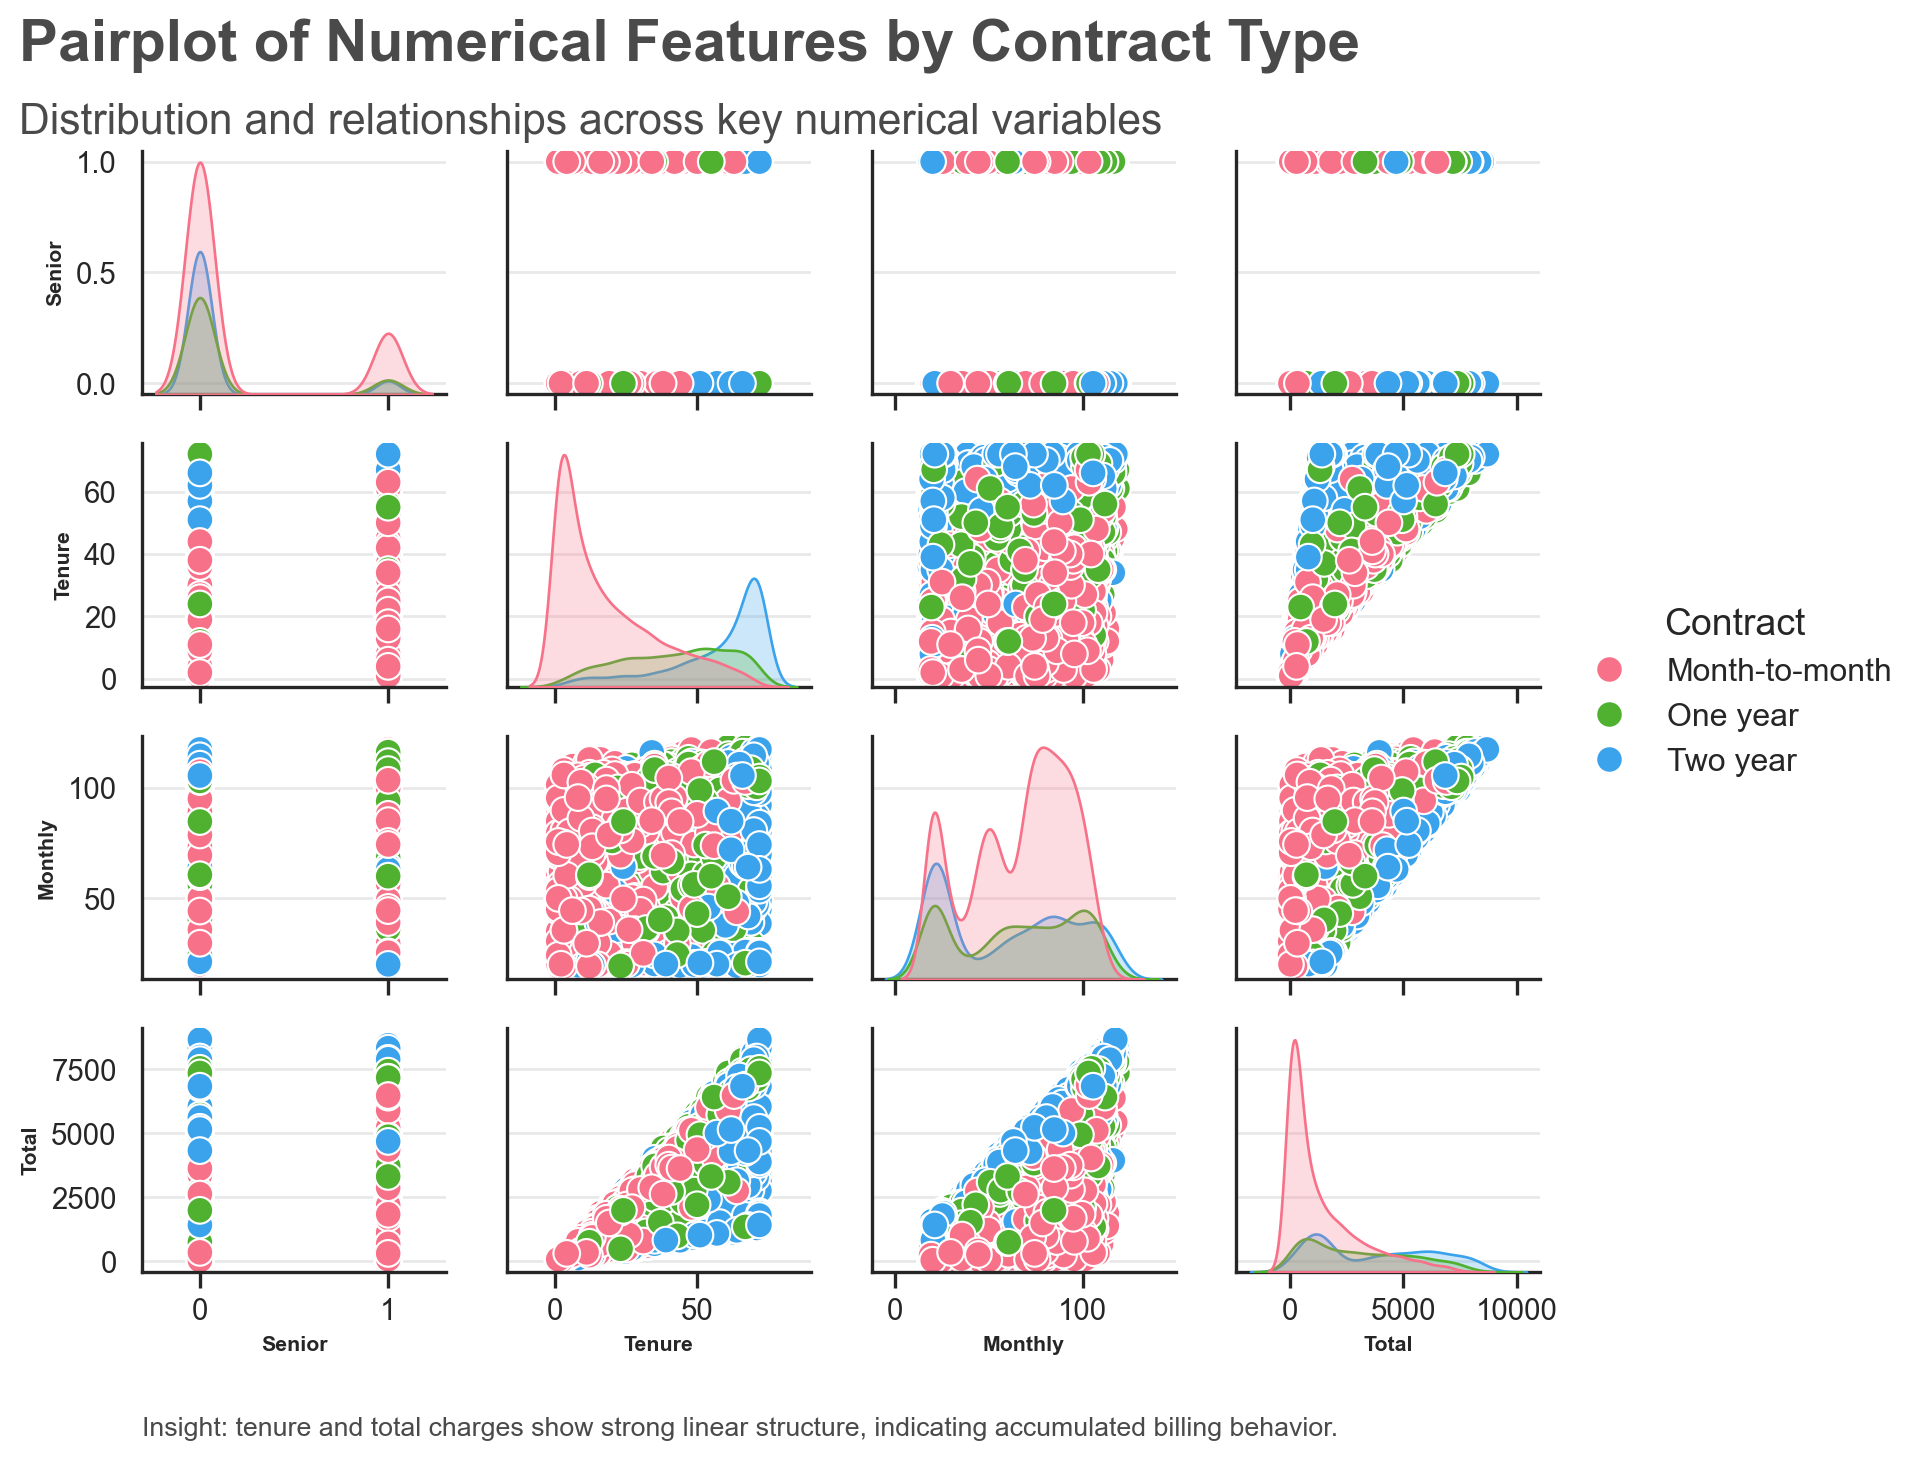

In [12]:
def plot_pairplot_corporate(
    df,
    rename_dict=None,
    hue='Contract',
    title="Pairplot of Numerical Features",
    subtitle=None,
    palette='husl',
    height=2,
    show_footer=False,
    footer_text=None
):
    """
    Generate a Seaborn pairplot in corporate style.

    Parameters
    ----------
    df : pandas.DataFrame
    rename_dict : dict
        Optional column renaming for readability
    hue : str
        Column used for grouping
    title : str
    subtitle : str
    palette : str
    height : float
    show_footer : bool
    footer_text : str
    """

    # Rename columns if provided
    if rename_dict:
        data = df.rename(columns=rename_dict)
    else:
        data = df.copy()

    # Create pairplot
    g = sns.pairplot(
        data,
        hue=hue,
        palette=palette,
        height=height,
        diag_kind='kde'  # mais elegante que hist
    )

    fig = g.figure

    # Header (seu padrão)
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Ajuste fino de layout
    fig.subplots_adjust(
        top=0.88,
        bottom=0.08,
        left=0.08,
        right=0.82,
        hspace=0.2,
        wspace=0.2
    )

    # Ajuste de labels (legibilidade)
    for ax in g.axes.flatten():
        if ax is not None:
            ax.set_xlabel(ax.get_xlabel(), fontsize=8)
            ax.set_ylabel(ax.get_ylabel(), fontsize=8)

    # Legend externa
    if g._legend is not None:
        g._legend.set_bbox_to_anchor((1.02, 0.5))
        g._legend.set_title(hue)
        g._legend.set_frame_on(False)

    # Footer opcional
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.show()

    return g

rename_dict = {
    'MonthlyCharges': 'Monthly',
    'TotalCharges': 'Total',
    'SeniorCitizen': 'Senior',
    'tenure': 'Tenure'
}

plot_pairplot_corporate(
    telecom,
    rename_dict=rename_dict,
    hue='Contract',
    title="Pairplot of Numerical Features by Contract Type",
    subtitle="Distribution and relationships across key numerical variables",
    show_footer=True,
    footer_text="Insight: tenure and total charges show strong linear structure, indicating accumulated billing behavior."
)

The pairplot provides a combined view of univariate distributions and pairwise relationships across key numerical variables, segmented by contract type.

**Insights:**
- `Tenure` and `Total` show a strong positive relationship, reflecting the cumulative nature of billing — longer customer lifetimes directly translate into higher total charges.
- Customers on `Month-to-month` contracts are concentrated at lower values of `Tenure` and `Total`, indicating shorter lifecycles and higher churn exposure compared to longer-term contracts.
- `Monthly` charges display wide dispersion across contract types, suggesting limited discriminative power when used in isolation.
- `Senior` is a binary feature (0/1). Despite being plotted as numerical, its interpretability is categorical and should be treated as such in modeling.

After reviewing numerical behavior, we proceed to the distribution of categorical variables, starting with gender.

<span style="color:steelblue; text-align: left">

###  Gender Distribution
</span>

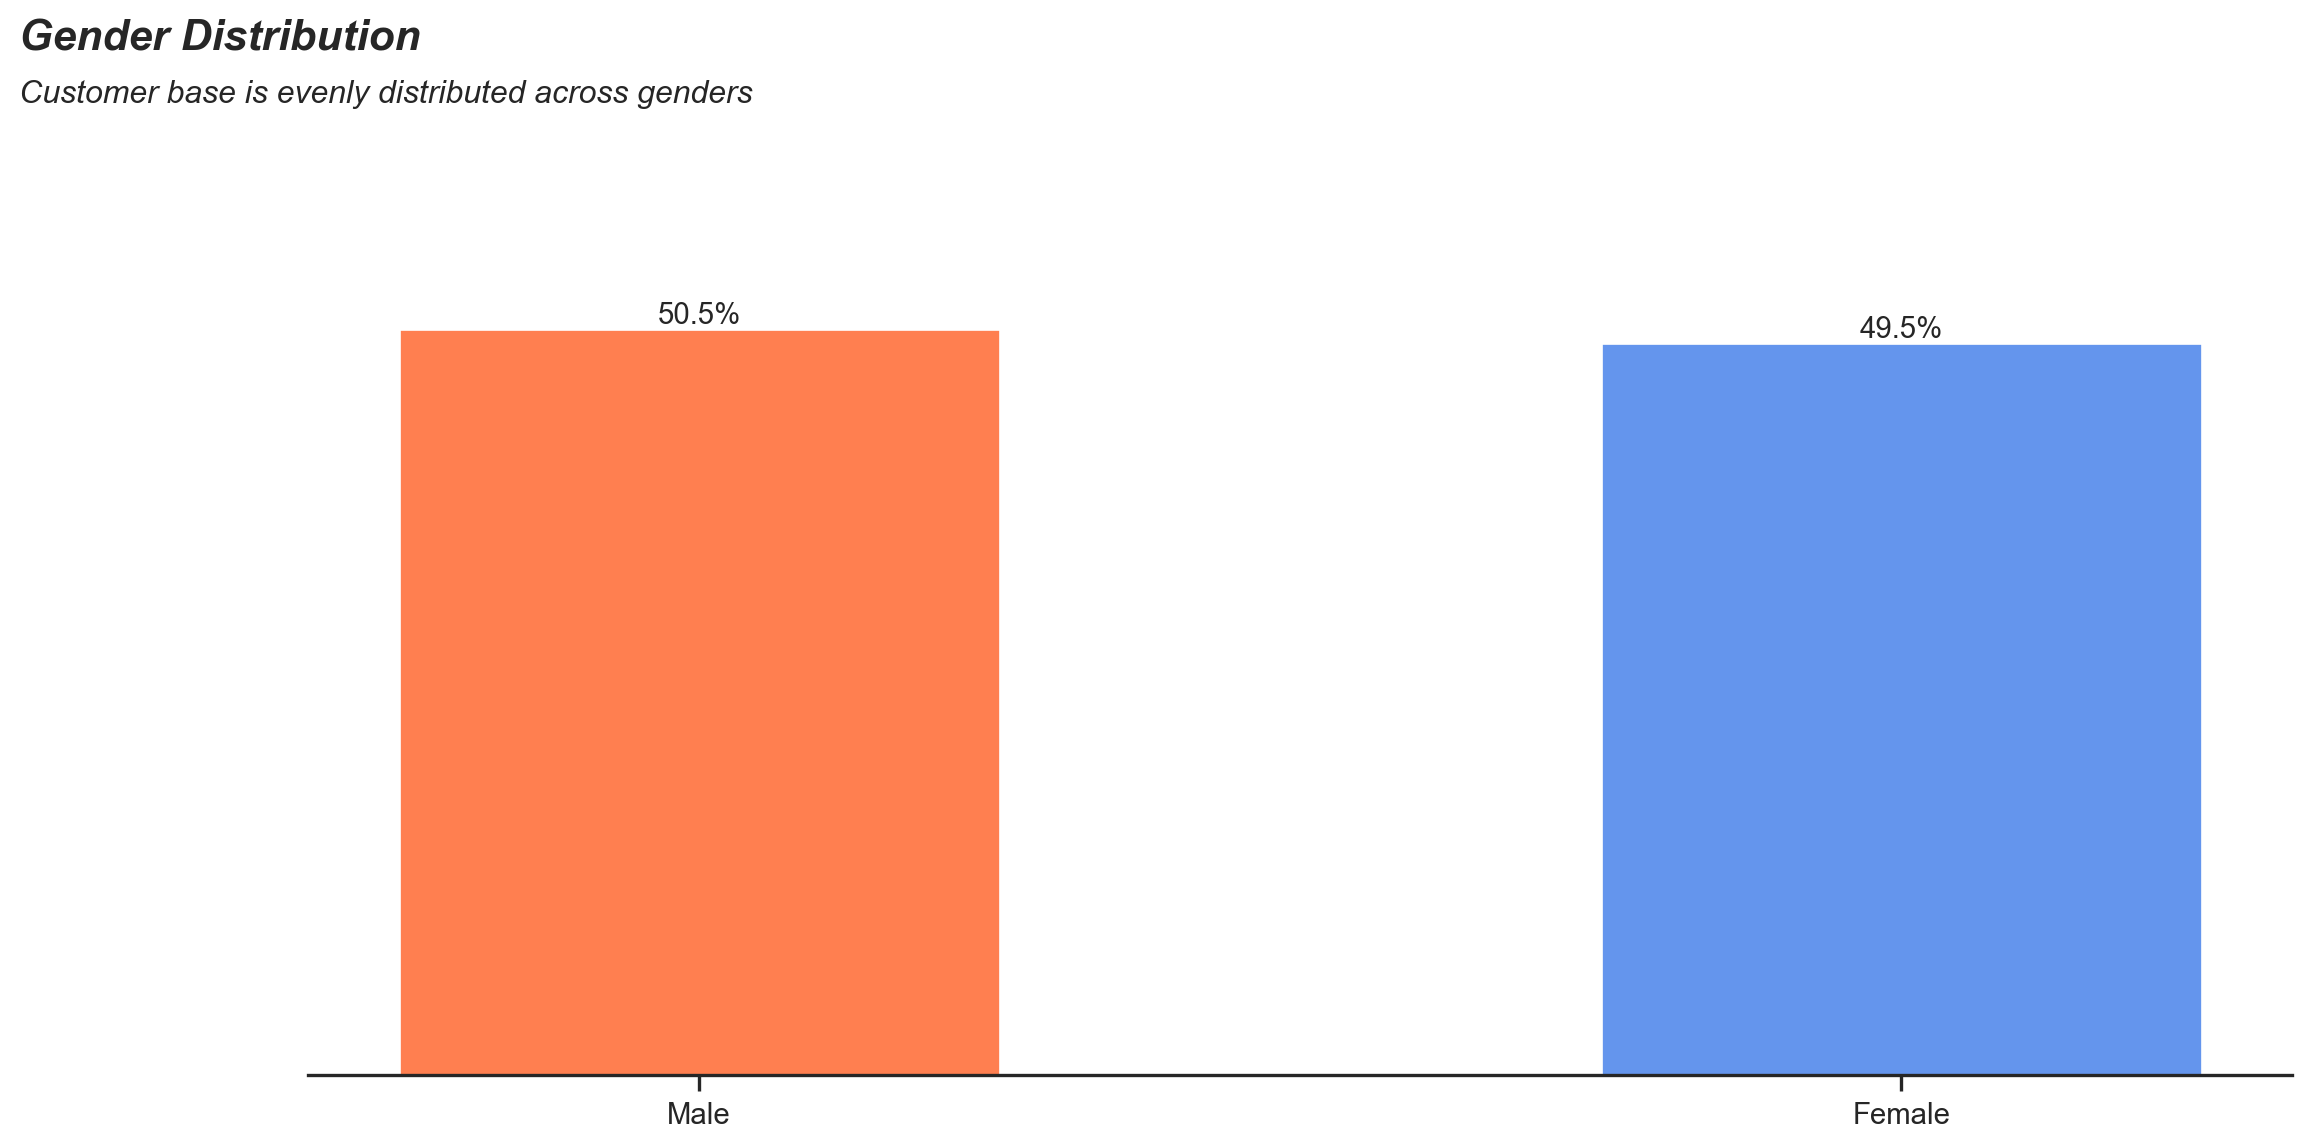

In [ ]:
# Compute percentage distribution
gender_counts = telecom['gender'].value_counts(normalize=True) * 100

gender = gender_counts.index.tolist()
quant  = gender_counts.values.tolist()

colors = ['coral', 'cornflowerblue']
width = 0.5

# Initialize plot
fig, ax = plt.subplots()

bars = ax.bar(gender, quant, width, color=colors)

# Format labels on bars
ax.bar_label(bars, fmt='%.1f%%', fontsize=11)

# Remove y-axis (since values are labeled)
ax.set_ylim(0, 65)
ax.get_yaxis().set_visible(False)

add_finance_header(
    fig,
    title="Gender Distribution",
    subtitle="Customer base is evenly distributed across genders"
)


plt.grid(False)
plt.show()

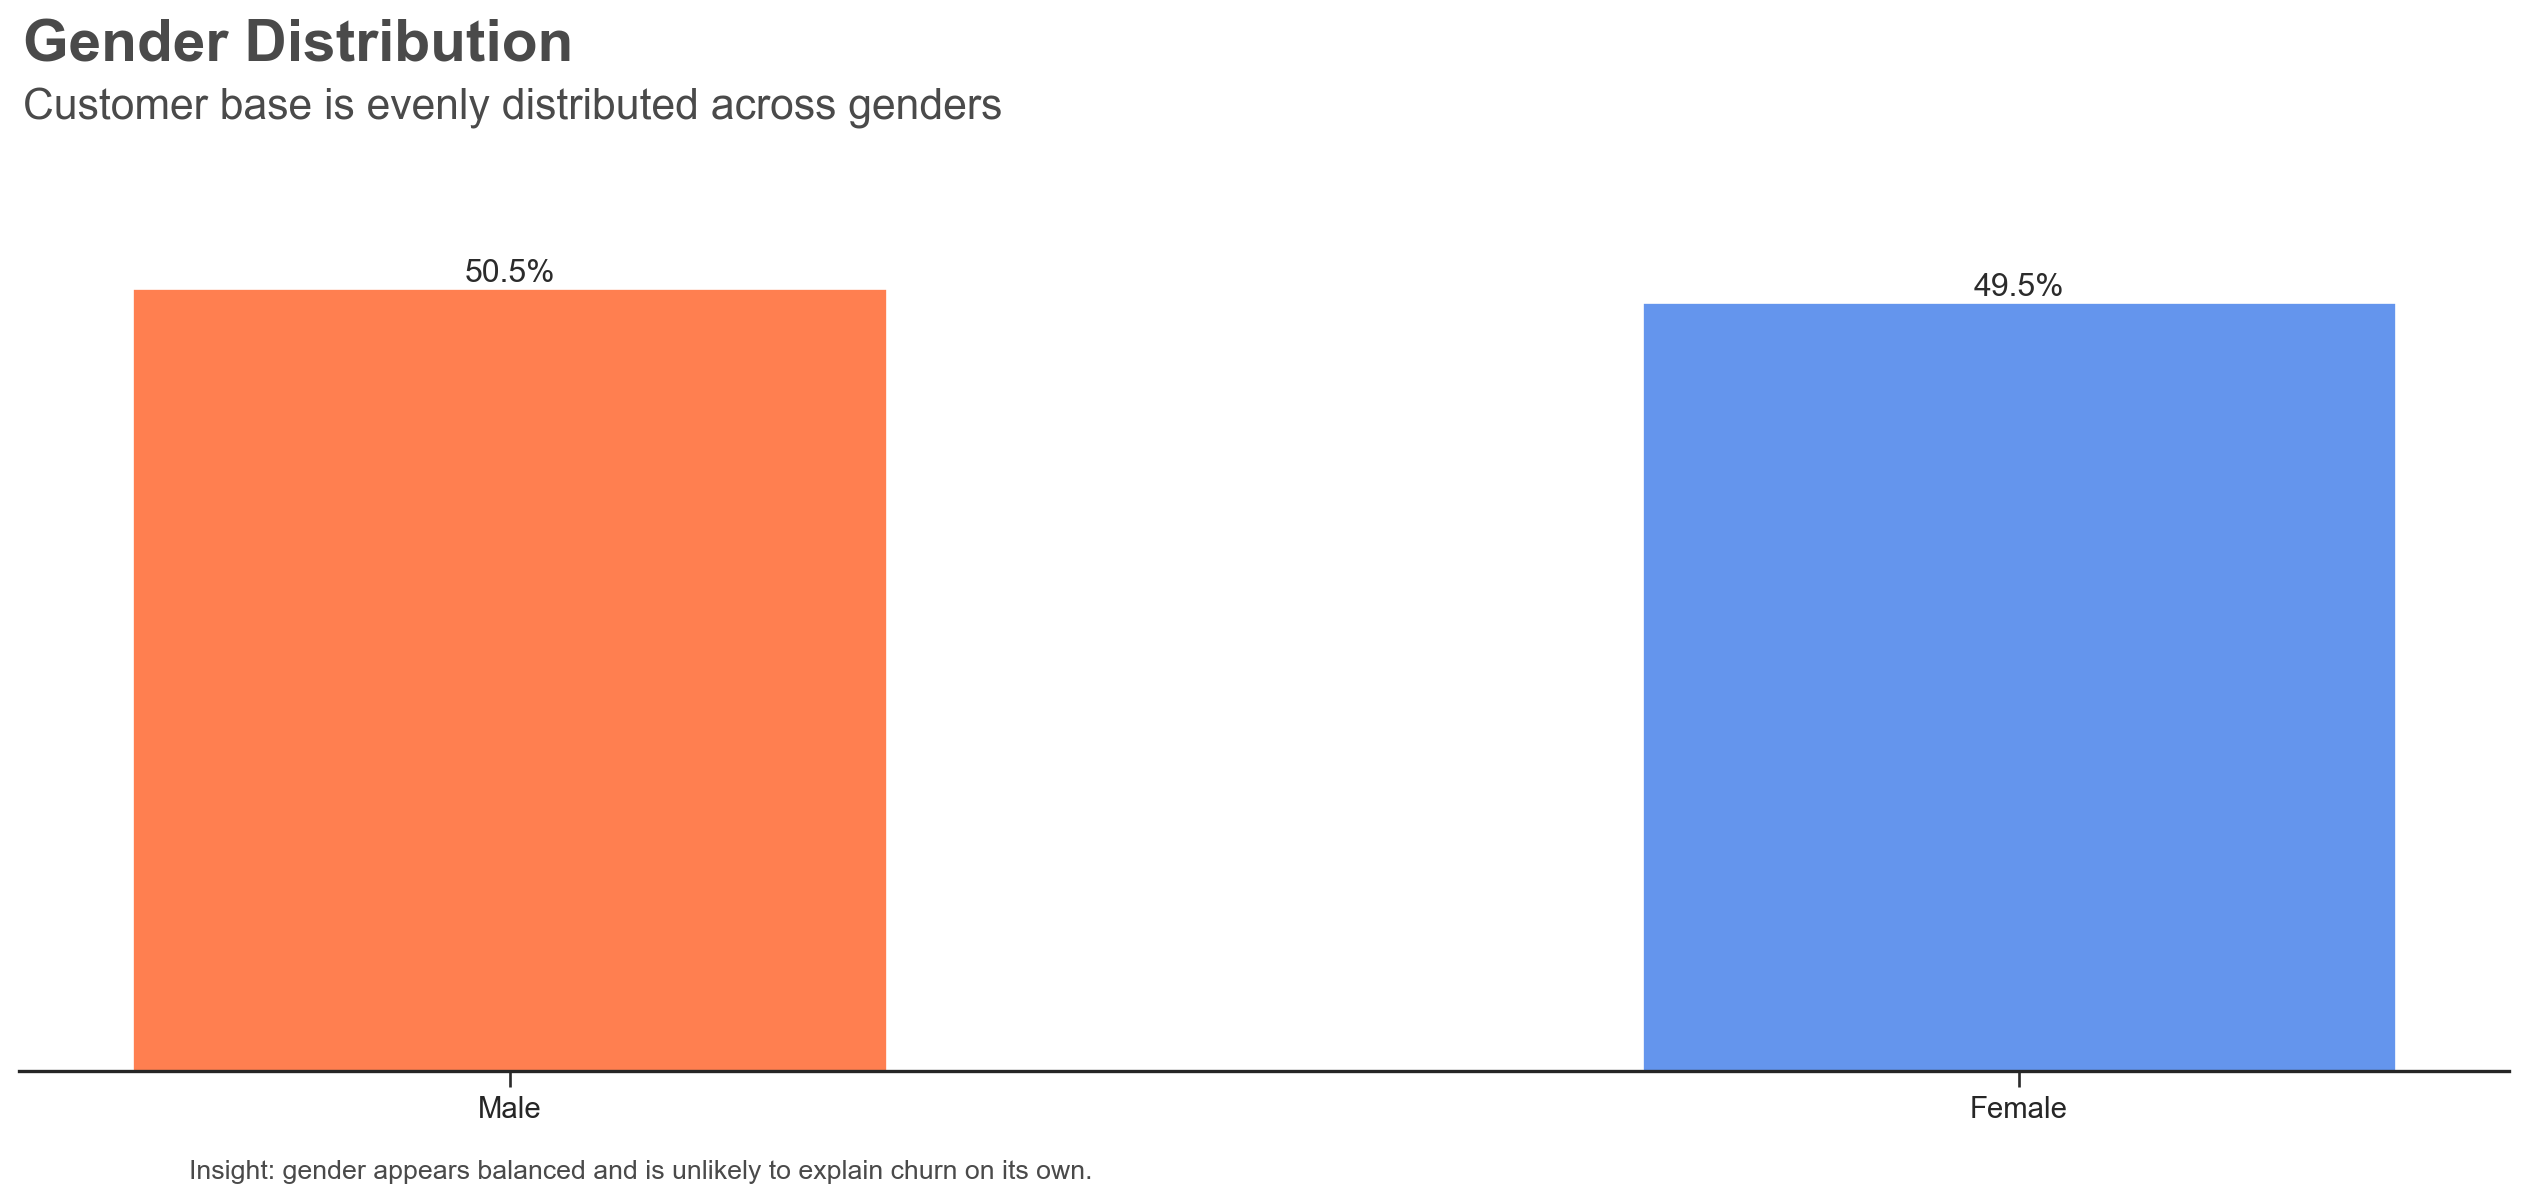

In [14]:
def plot_gender_distribution(
    df,
    gender_col='gender',
    title="Gender Distribution",
    subtitle="Customer base is evenly distributed across genders",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    """
    Plot gender distribution as percentage bars.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    gender_col : str
        Name of the gender column.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    palette : tuple
        Colors for the bars.
    """

    # Compute percentage distribution
    gender_counts = df[gender_col].value_counts(normalize=True) * 100

    labels = gender_counts.index.tolist()
    values = gender_counts.values.tolist()

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, width=0.5, color=list(palette))

    # Labels on bars
    ax.bar_label(bars, fmt='%.1f%%', fontsize=12, color="#2b2b2b")

    # Visual range
    ax.set_ylim(0, max(values) * 1.15)

    # Corporate axis formatting
    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    # Header
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Footer
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_gender_distribution(
    telecom,
    gender_col='gender',
    title="Gender Distribution",
    subtitle="Customer base is evenly distributed across genders",
    footer_text="Insight: gender appears balanced and is unlikely to explain churn on its own.",
    show_footer=True
)    

**Insights:**
- The customer base is almost evenly split between male and female customers, indicating no meaningful class imbalance for this feature.
- This suggests that gender, by itself, is unlikely to be a strong discriminator of churn.
- More explanatory power is expected from behavioral, contractual, and billing-related variables.
- Since the distribution is balanced, no adjustment is required for this feature from a class representation perspective.

<span style="color:steelblue; text-align: left">

###  Senior Citizens Distribution
</span>

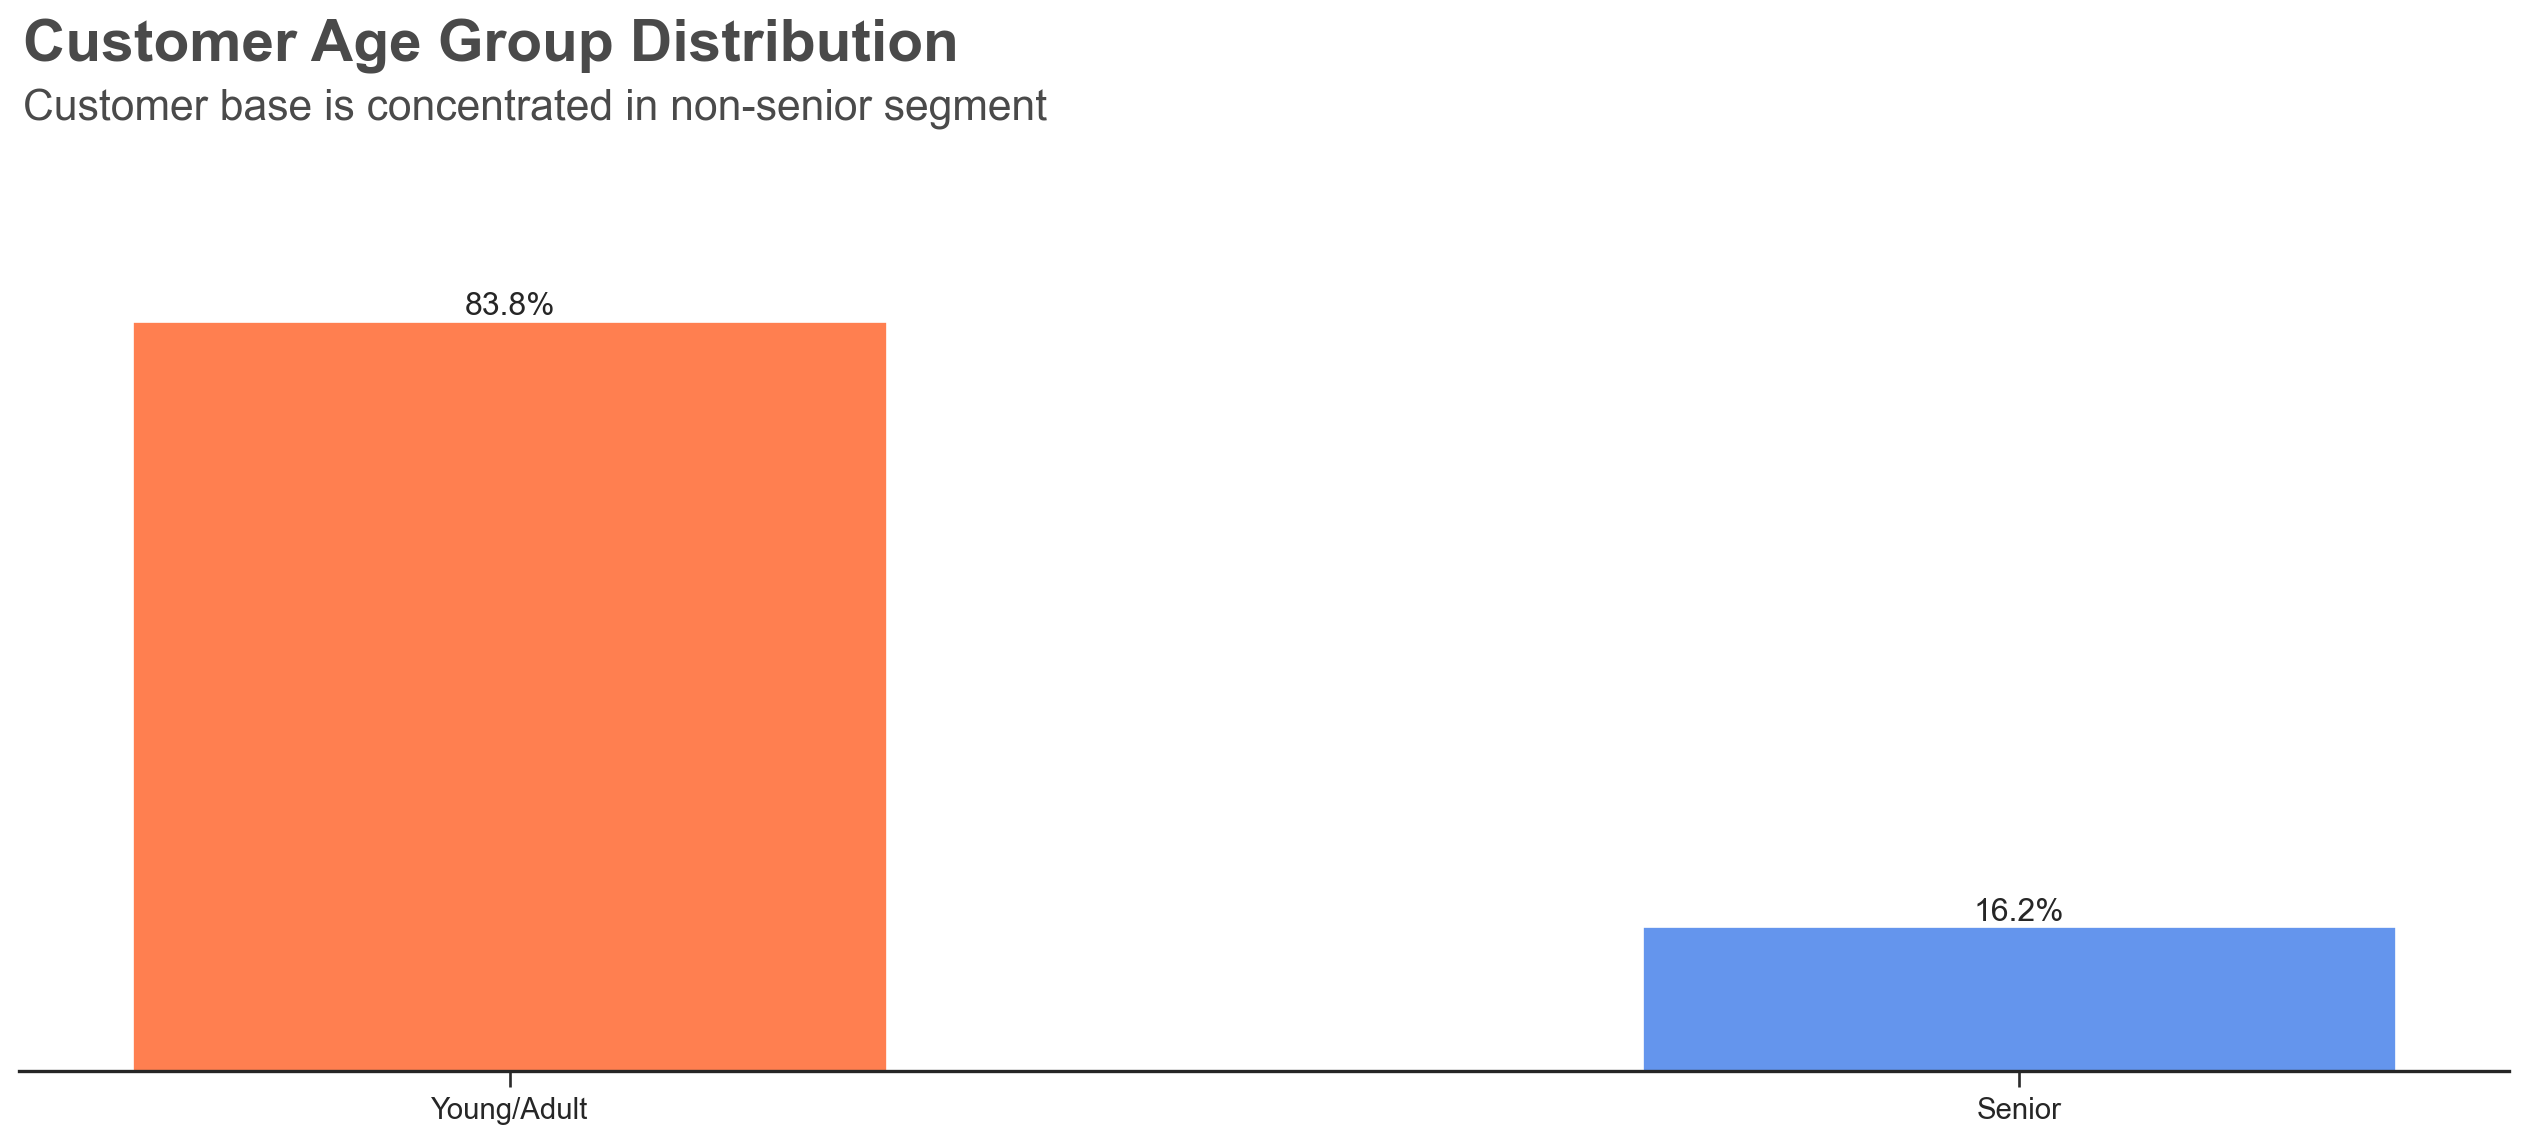

In [15]:
def plot_senior_distribution(
    df,
    col='SeniorCitizen',
    title="Customer Age Group Distribution",
    subtitle="Customer base is concentrated in non-senior segment",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    
    dist = df[col].value_counts(normalize=True) * 100
    labels_map = {0: 'Young/Adult', 1: 'Senior'}
    
    labels = [labels_map[i] for i in dist.index]
    values = dist.values

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, color=palette, width=0.5)

    ax.bar_label(bars, fmt='%.1f%%', fontsize=12)

    ax.set_ylim(0, max(values) * 1.2)

    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_senior_distribution(telecom)    

**Insights:**
- Senior customers represent a minority (~16%) of the base, with the majority concentrated in the non-senior segment.
- This imbalance suggests that patterns involving senior customers should be interpreted cautiously due to lower sample representation.
- Despite the smaller share, this segment may exhibit distinct behavioral patterns and should be evaluated separately in churn analysis.

<span style="color:steelblue; text-align: left">

###  Partner and dependent status Distribution
</span>

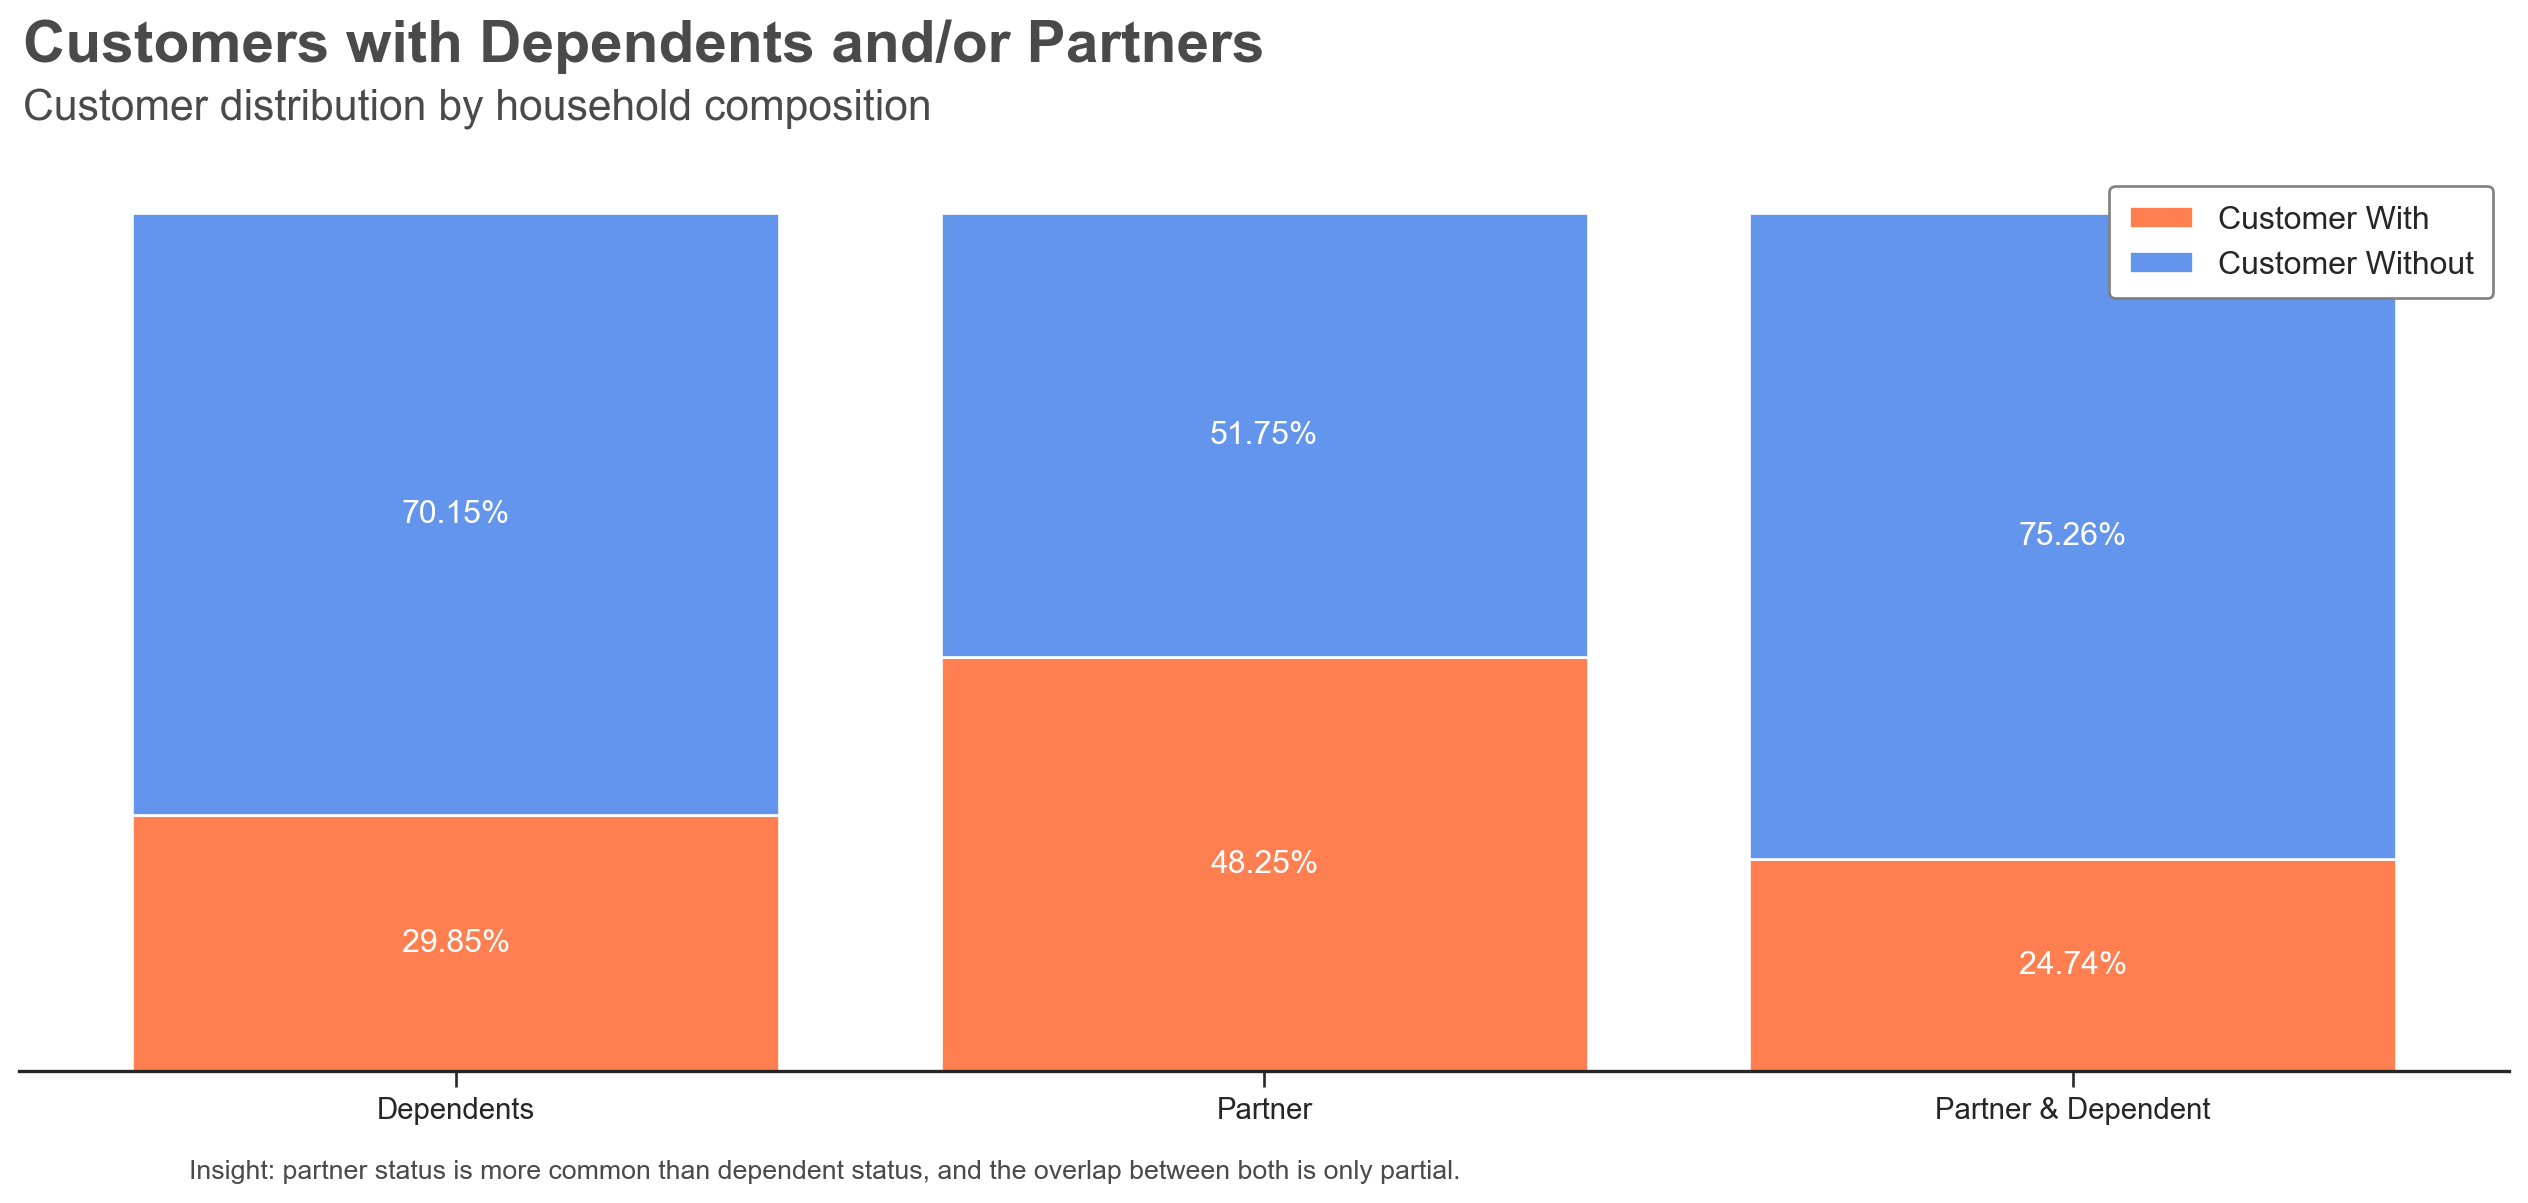

In [16]:
def plot_household_composition(
    df,
    partner_col='Partner',
    dependents_col='Dependents',
    title="Customers with Dependents and/or Partners",
    subtitle="Customer distribution by household composition",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue')
):
    """
    Plot household composition using stacked percentage bars.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    partner_col : str
        Column indicating partner status.
    dependents_col : str
        Column indicating dependents status.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    palette : tuple
        Colors for positive/negative groups.
    """

    data = df.copy()

    # Create flags
    data['Partner_flag'] = data[partner_col].map({'Yes': 1, 'No': 0})
    data['Dependents_flag'] = data[dependents_col].map({'Yes': 1, 'No': 0})

    # Compute proportions
    partner_dist = data['Partner_flag'].value_counts(normalize=True) * 100
    dependents_dist = data['Dependents_flag'].value_counts(normalize=True) * 100
    both = ((data['Partner_flag'] == 1) & (data['Dependents_flag'] == 1)).mean() * 100

    # Build dataframe
    plot_df = pd.DataFrame({
        'Customer With': [
            dependents_dist[1],
            partner_dist[1],
            both
        ],
        'Customer Without': [
            dependents_dist[0],
            partner_dist[0],
            100 - both
        ]
    }, index=['Dependents', 'Partner', 'Partner & Dependent'])

    # Plot
    fig, ax = plt.subplots()

    bottom = np.zeros(len(plot_df))

    for i, col in enumerate(plot_df.columns):
        bars = ax.bar(
            plot_df.index,
            plot_df[col],
            bottom=bottom,
            color=palette[i],
            label=col
        )

        ax.bar_label(
            bars,
            label_type='center',
            fmt='%.2f%%',
            color='white',
            fontsize=12
        )

        bottom += plot_df[col].values

    # Hide y-axis entirely for this style
    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    # Header
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Legend
    #ax.legend(loc='upper right')
    ax.legend(frameon=True, loc='upper right')


    # Footer
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_household_composition(
    telecom,
    partner_col='Partner',
    dependents_col='Dependents',
    title="Customers with Dependents and/or Partners",
    subtitle="Customer distribution by household composition",
    footer_text="Insight: partner status is more common than dependent status, and the overlap between both is only partial.",
    show_footer=True
)    

**Insights:**
- Most customers do not simultaneously have both a partner and dependents, suggesting a predominance of more independent household profiles.
- Customers with partners (~48%) are more common than customers with dependents (~30%), indicating that dependents are a more restrictive condition in this sample.
- The overlap between partner and dependent status is only partial, showing that these variables are related but not interchangeable.
- Household composition may influence customer behavior and should be considered in subsequent churn analysis.

<span style="color:steelblue; text-align: left">

###  Tenure Distribution
</span>

`tenure` represents the number of months each customer has remained with the company.

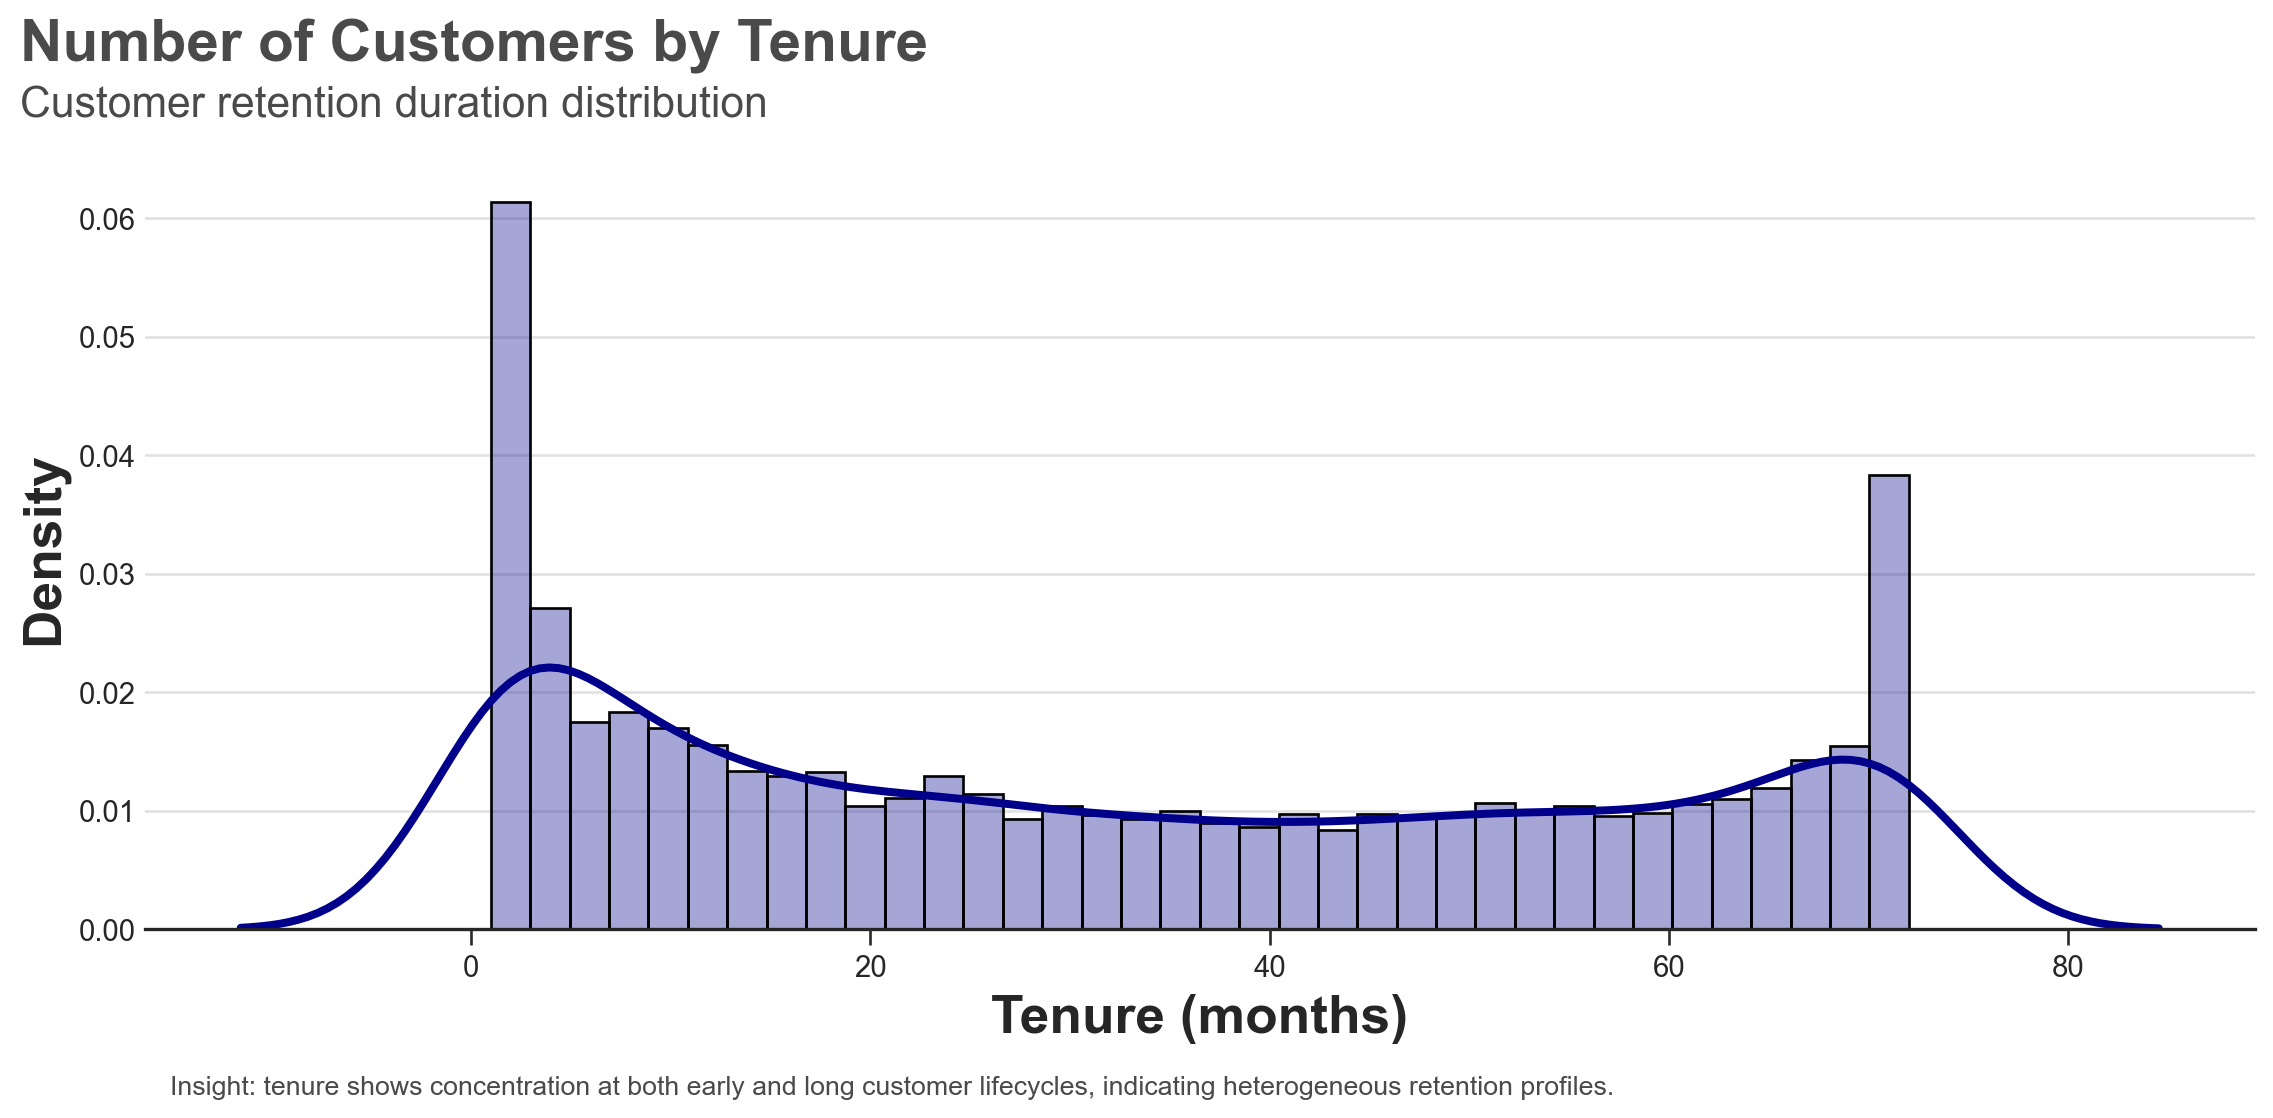

In [17]:
def plot_tenure_distribution(
    df,
    tenure_col='tenure',
    title="Number of Customers by Tenure",
    subtitle="Customer retention duration distribution",
    footer_text=None,
    show_footer=False,
    bins=36,
    color='darkblue'
):
    """
    Plot tenure distribution using histogram + KDE.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    tenure_col : str
        Name of the tenure column.
    title : str
        Chart title.
    subtitle : str
        Chart subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    bins : int
        Number of bins for histogram.
    color : str
        Histogram/KDE color.
    """

    fig, ax = plt.subplots(figsize=(12, 6))

    # Histogram + KDE
    """sns.distplot(
        df[tenure_col],
        hist=True,
        kde=True,
        bins=bins,
        color=color,
        hist_kws={'edgecolor': 'black', 'alpha': 0.35},
        kde_kws={'linewidth': 3},
        ax=ax
    )"""
    
    sns.histplot(
        df[tenure_col],
        bins=bins,
        color=color,
        edgecolor='black',
        alpha=0.35,
        stat='density',
        ax=ax
    )

    sns.kdeplot(
        df[tenure_col],
        color=color,
        linewidth=3,
        ax=ax
    )

    # Labels
    ax.set_xlabel('Tenure (months)')
    ax.set_ylabel('Density')

    # Keep readability similar to your approved version
    format_corporate_axes(
        ax,
        hide_y_spine_only=True,
        hide_y_entirely=False,
        grid=True,
        grid_axis='y'
    )

    # Header
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    # Footer
    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_tenure_distribution(
    telecom,
    tenure_col='tenure',
    title="Number of Customers by Tenure",
    subtitle="Customer retention duration distribution",
    footer_text="Insight: tenure shows concentration at both early and long customer lifecycles, indicating heterogeneous retention profiles.",
    show_footer=True
)    

**Insights:**
- The distribution is concentrated in the first months of the relationship.
- A second concentration appears among long-tenure customers.
- This suggests different retention profiles, likely associated with contract type.

<span style="color:steelblue; text-align: left"> 

### Contract Distribution
</span>

To better interpret the tenure distribution, it is useful to first examine how customers are distributed across contract types.

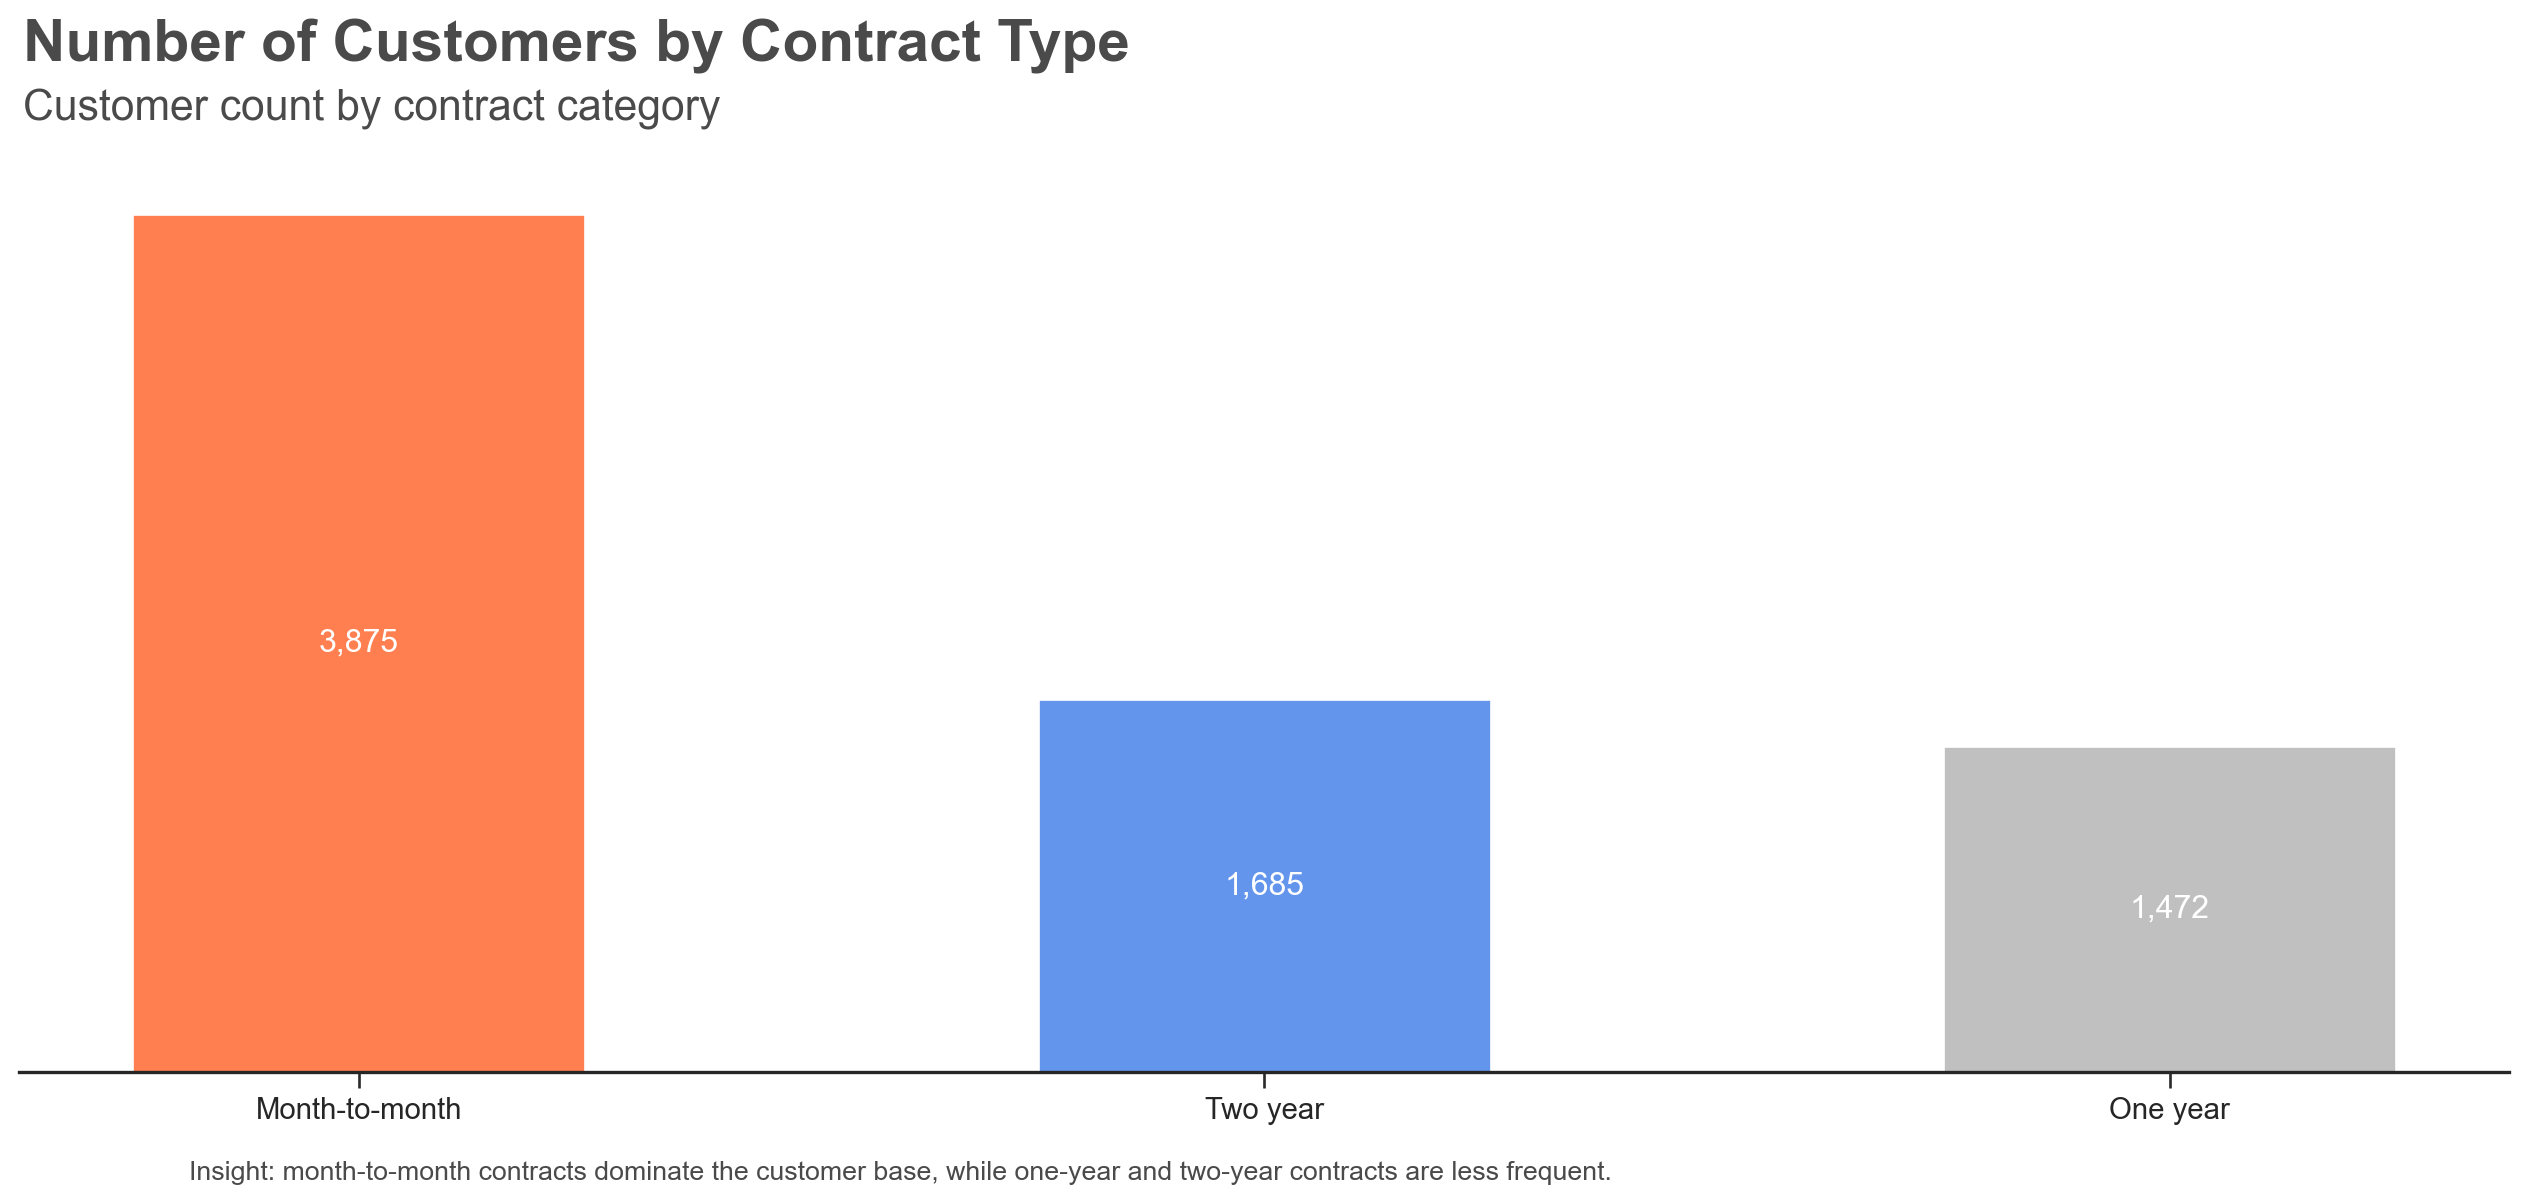

In [18]:
def plot_contract_distribution(
    df,
    contract_col='Contract',
    title="Number of Customers by Contract Type",
    subtitle="Customer count by contract category",
    footer_text=None,
    show_footer=False,
    palette=('coral', 'cornflowerblue', 'silver')
):
    """
    Plot the number of customers in each contract type.
    """

    counts = df[contract_col].value_counts()

    labels = counts.index.tolist()
    values = counts.values.tolist()

    fig, ax = plt.subplots()

    bars = ax.bar(labels, values, width=0.5, color=list(palette[:len(labels)]))

    ax.bar_label(bars, fmt='{:,.0f}', label_type='center', color='white', fontsize=12)

    format_corporate_axes(
        ax,
        hide_y_spine_only=False,
        hide_y_entirely=True,
        grid=False
    )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_contract_distribution(
    telecom,
    contract_col='Contract',
    title="Number of Customers by Contract Type",
    subtitle="Customer count by contract category",
    footer_text="Insight: month-to-month contracts dominate the customer base, while one-year and two-year contracts are less frequent.",
    show_footer=True
)    

**Insights:**
- Most customers are on month-to-month contracts.
- One-year and two-year contracts have smaller and relatively similar representation.
- This concentration in short-term contracts is relevant, as contract type is likely to influence retention behavior.

Below, tenure is examined separately for each contract type.


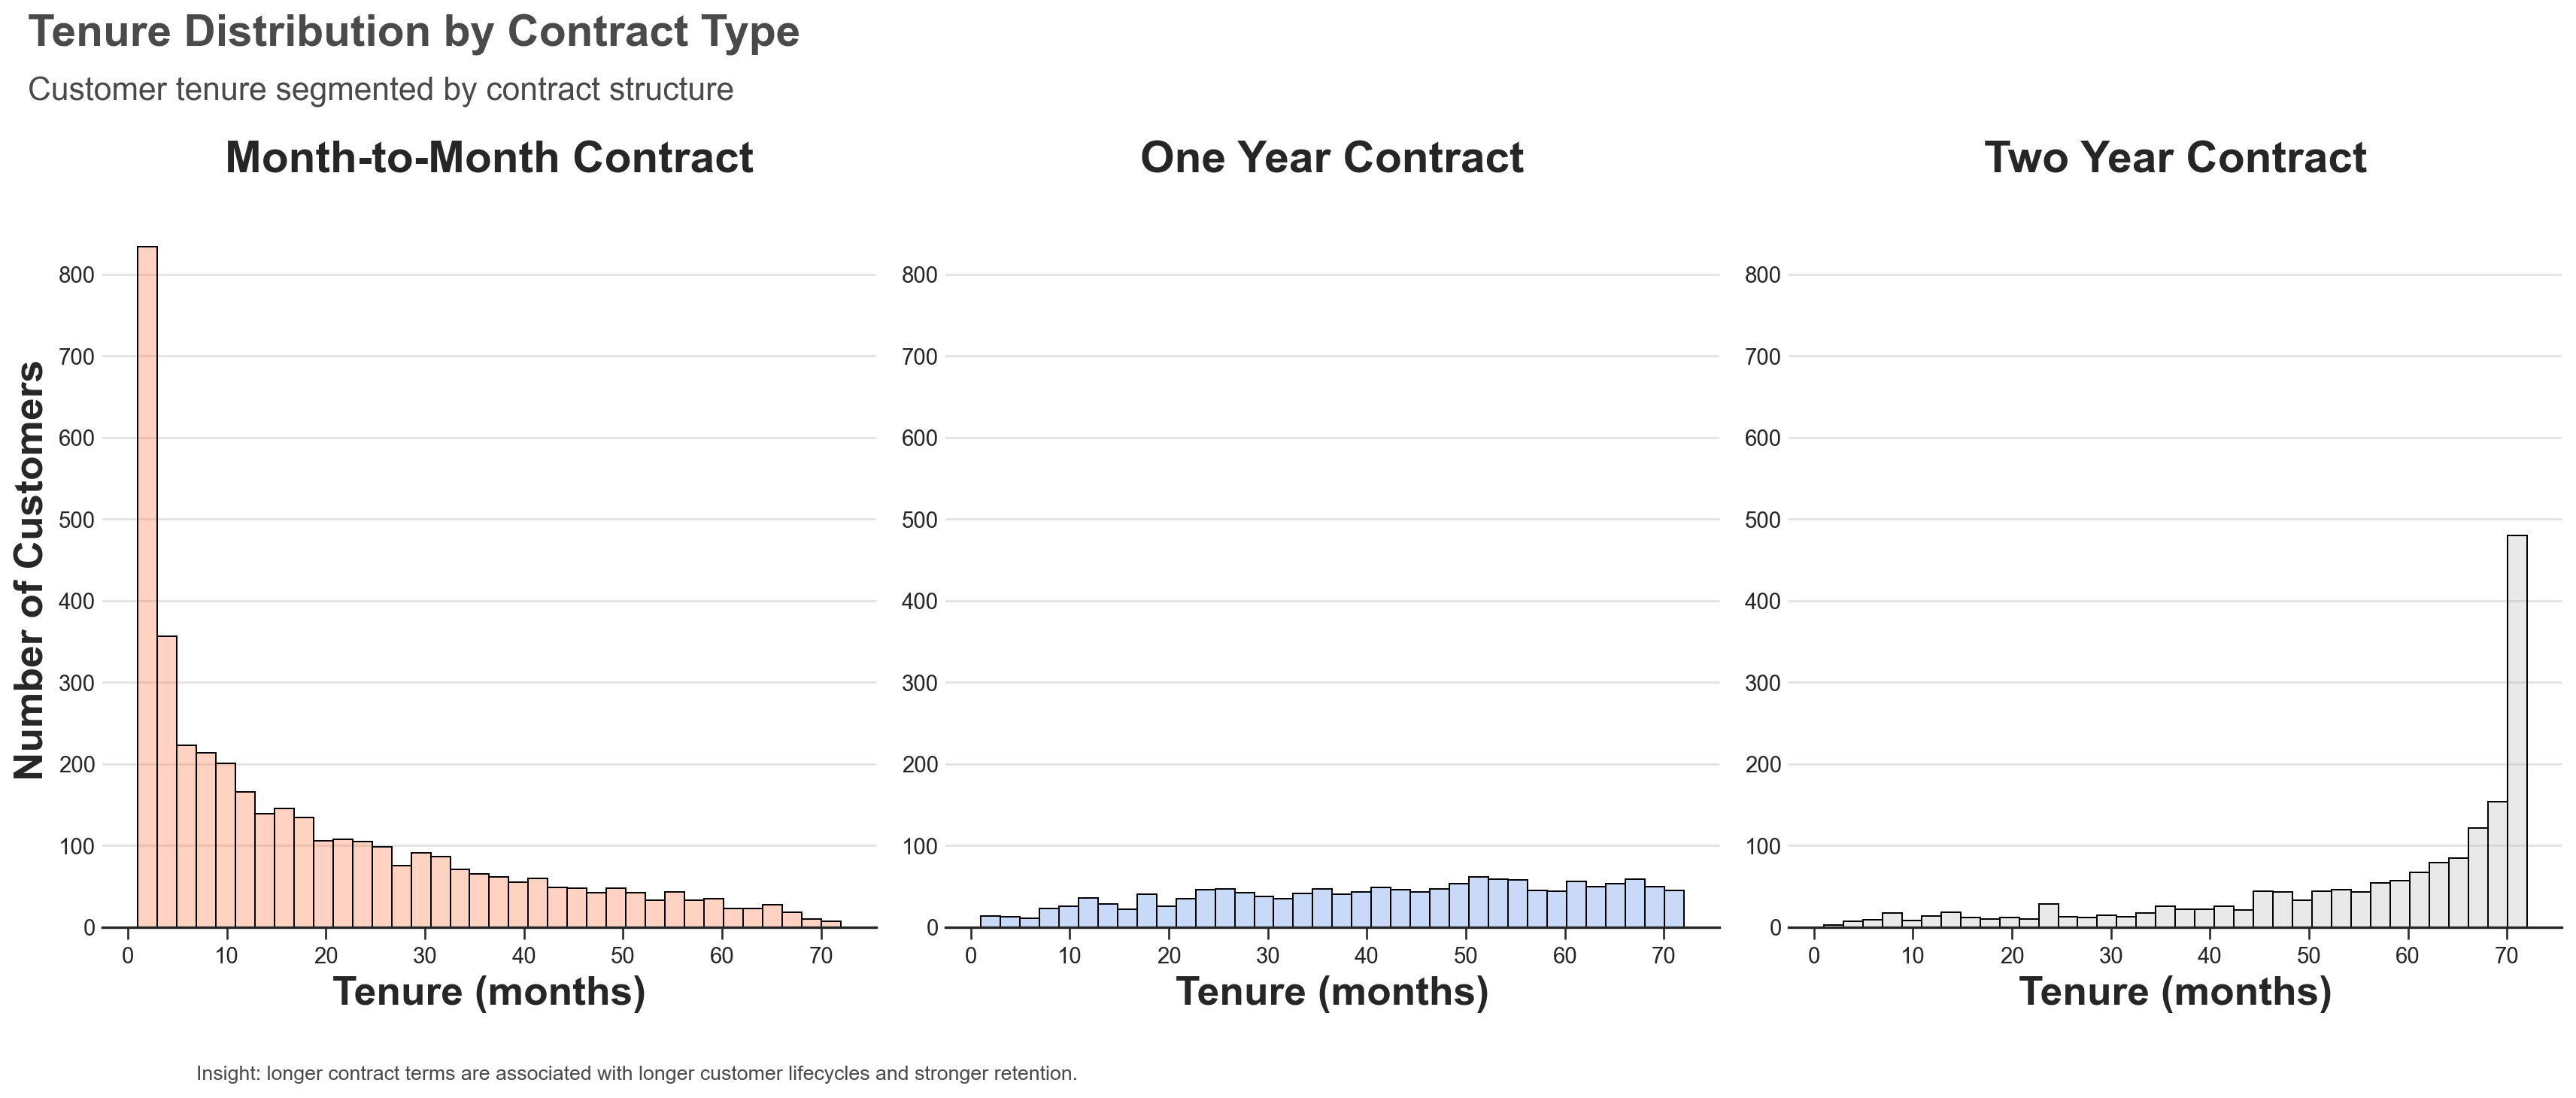

In [19]:
def plot_tenure_by_contract(
    df,
    contract_col='Contract',
    tenure_col='tenure',
    title="Tenure Distribution by Contract Type",
    subtitle="Customer tenure segmented by contract structure",
    footer_text=None,
    show_footer=False,
    bins=36,
    palette=('coral', 'cornflowerblue', 'silver')
):
    """
    Plot tenure distributions separately for each contract type.
    """

    contract_order = ['Month-to-month', 'One year', 'Two year']
    subplot_titles = ['Month-to-Month Contract', 'One Year Contract', 'Two Year Contract']

    fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(18, 8))

    for ax, contract_name, subplot_title, color in zip(axes, contract_order, subplot_titles, palette):
        subset = df[df[contract_col] == contract_name]

        sns.histplot(
            subset[tenure_col],
            bins=bins,
            kde=False,
            color=color,
            edgecolor='black',
            alpha=0.35,
            ax=ax
        )

        ax.set_title(subplot_title)
        ax.set_xlabel('Tenure (months)')

        if ax is axes[0]:
            ax.set_ylabel('Number of Customers')
            format_corporate_axes(
                ax,
                hide_y_spine_only=True,
                hide_y_entirely=False,
                grid=True,
                grid_axis='y'
            )
        else:
            ax.set_ylabel('')
            format_corporate_axes(
                ax,
                hide_y_spine_only=True,
                hide_y_entirely=False,
                grid=True,
                grid_axis='y'
            )

    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.88])
    plt.show()
    
plot_tenure_by_contract(
    telecom,
    contract_col='Contract',
    tenure_col='tenure',
    title="Tenure Distribution by Contract Type",
    subtitle="Customer tenure segmented by contract structure",
    footer_text="Insight: longer contract terms are associated with longer customer lifecycles and stronger retention.",
    show_footer=True
)    

**Insights:**
- Month-to-month contracts are heavily concentrated in short tenures, indicating a higher proportion of recently acquired or less retained customers.
- One-year contracts show a more balanced tenure distribution, with customers spread across intermediate and longer durations.
- Two-year contracts are concentrated at high tenure values, suggesting stronger retention and longer customer lifecycles.
- Overall, longer contract terms are associated with greater customer persistence, reinforcing the importance of contract structure in churn behavior.

<span style="color:steelblue; text-align: left">

### Services Distribution
</span>

The next step is to examine the distribution of services subscribed by customers. To simplify interpretation, the categories `No internet service` and `No phone service` are recoded as `No`, so the charts focus on whether the service is effectively available or not.

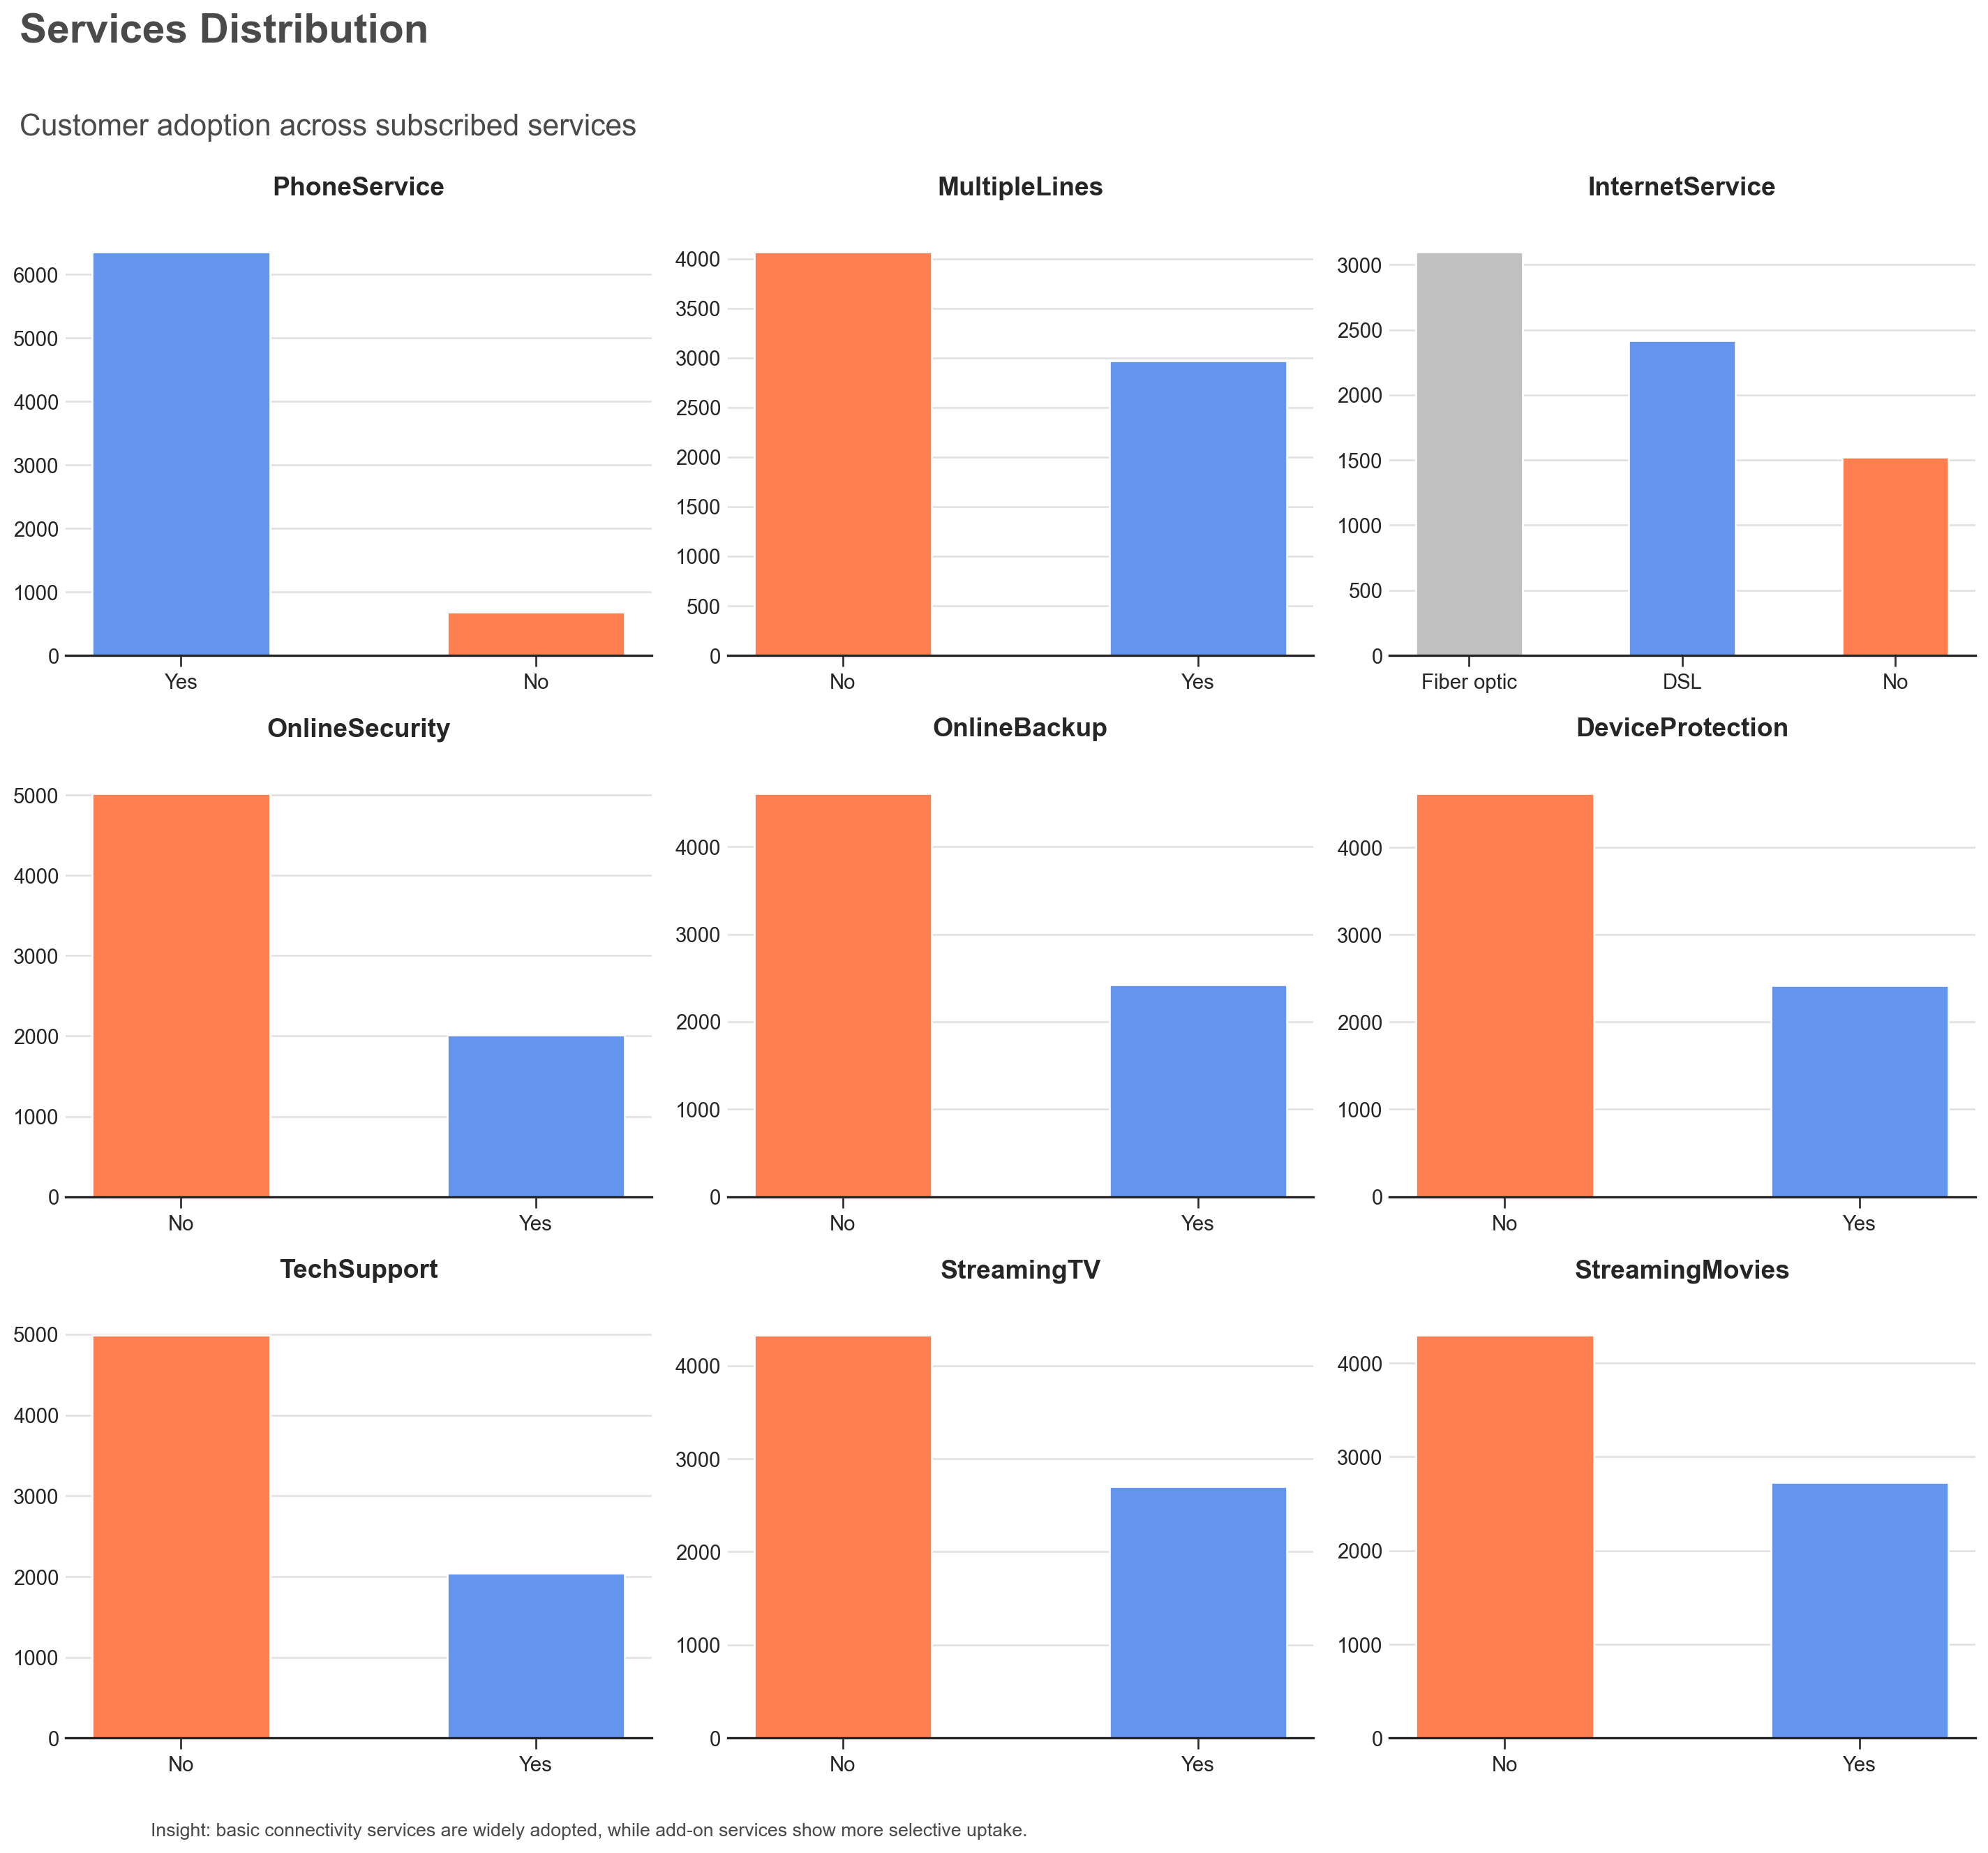

In [20]:
def plot_services_distribution(
    df,
    services=None,
    title="Services Distribution",
    subtitle="Customer adoption across subscribed services",
    footer_text=None,
    show_footer=False
):
    """
    Plot service distributions in a 3x3 grid with consistent category colors.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    services : list or None
        List of service columns to plot.
    title : str
        Figure title.
    subtitle : str
        Figure subtitle.
    footer_text : str or None
        Optional footer insight.
    show_footer : bool
        Whether to display footer text.
    """

    data = df.copy()

    # Recode service-specific negative states as 'No'
    data = data.replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

    if services is None:
        services = [
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]

    # Consistent color mapping
    color_map = {
        'No': 'coral',
        'Yes': 'cornflowerblue',
        'Fiber optic': 'silver',
        'DSL': 'cornflowerblue',
        'Month-to-month': 'coral',   # deixo aqui caso queira reutilizar lógica
        'One year': 'silver',
        'Two year': 'cornflowerblue'
    }

    fallback_color = 'silver'

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
    axes = axes.flatten()

    for i, col in enumerate(services):
        ax = axes[i]

        counts = data[col].value_counts()

        labels = counts.index.tolist()
        values = counts.values.tolist()

        bar_colors = [color_map.get(label, fallback_color) for label in labels]

        bars = ax.bar(labels, values, color=bar_colors, width=0.5)

        ax.set_title(col, fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Grade horizontal ajuda leitura aqui
        format_corporate_axes(
            ax,
            hide_y_spine_only=True,
            hide_y_entirely=False,
            grid=True,
            grid_axis='y'
        )

        ax.tick_params(axis='x', rotation=0)

    # Header e footer no padrão
    add_corporate_header(
        fig,
        title=title,
        subtitle=subtitle
    )

    add_corporate_footer(
        fig,
        text=footer_text,
        enabled=show_footer
    )

    #plt.tight_layout(rect=[0, 0.06, 1, 0.92])
    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.show()
    
plot_services_distribution(
    telecom,
    title="Services Distribution",
    subtitle="Customer adoption across subscribed services",
    footer_text="Insight: basic connectivity services are widely adopted, while add-on services show more selective uptake.",
    show_footer=True
)    

**Insights:**
- Core connectivity services such as `PhoneService`, `MultipleLines`, and `InternetService` show broad adoption across the customer base.
- Value-added services such as `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` are less uniformly adopted.
- This variation suggests that service bundles may help distinguish customer profiles and should be examined later in relation to churn.

<span style="color:steelblue; text-align: left">

## Multivariate Analysis
</span>

This section examines relationships between variables in order to identify dependency patterns, potential multicollinearity, and associations relevant to churn modeling.

<span style="color:steelblue; text-align: left">

###  Pearson correlation
</span>

Pearson correlation is first applied to the numerical variables in order to assess linear relationships among them.

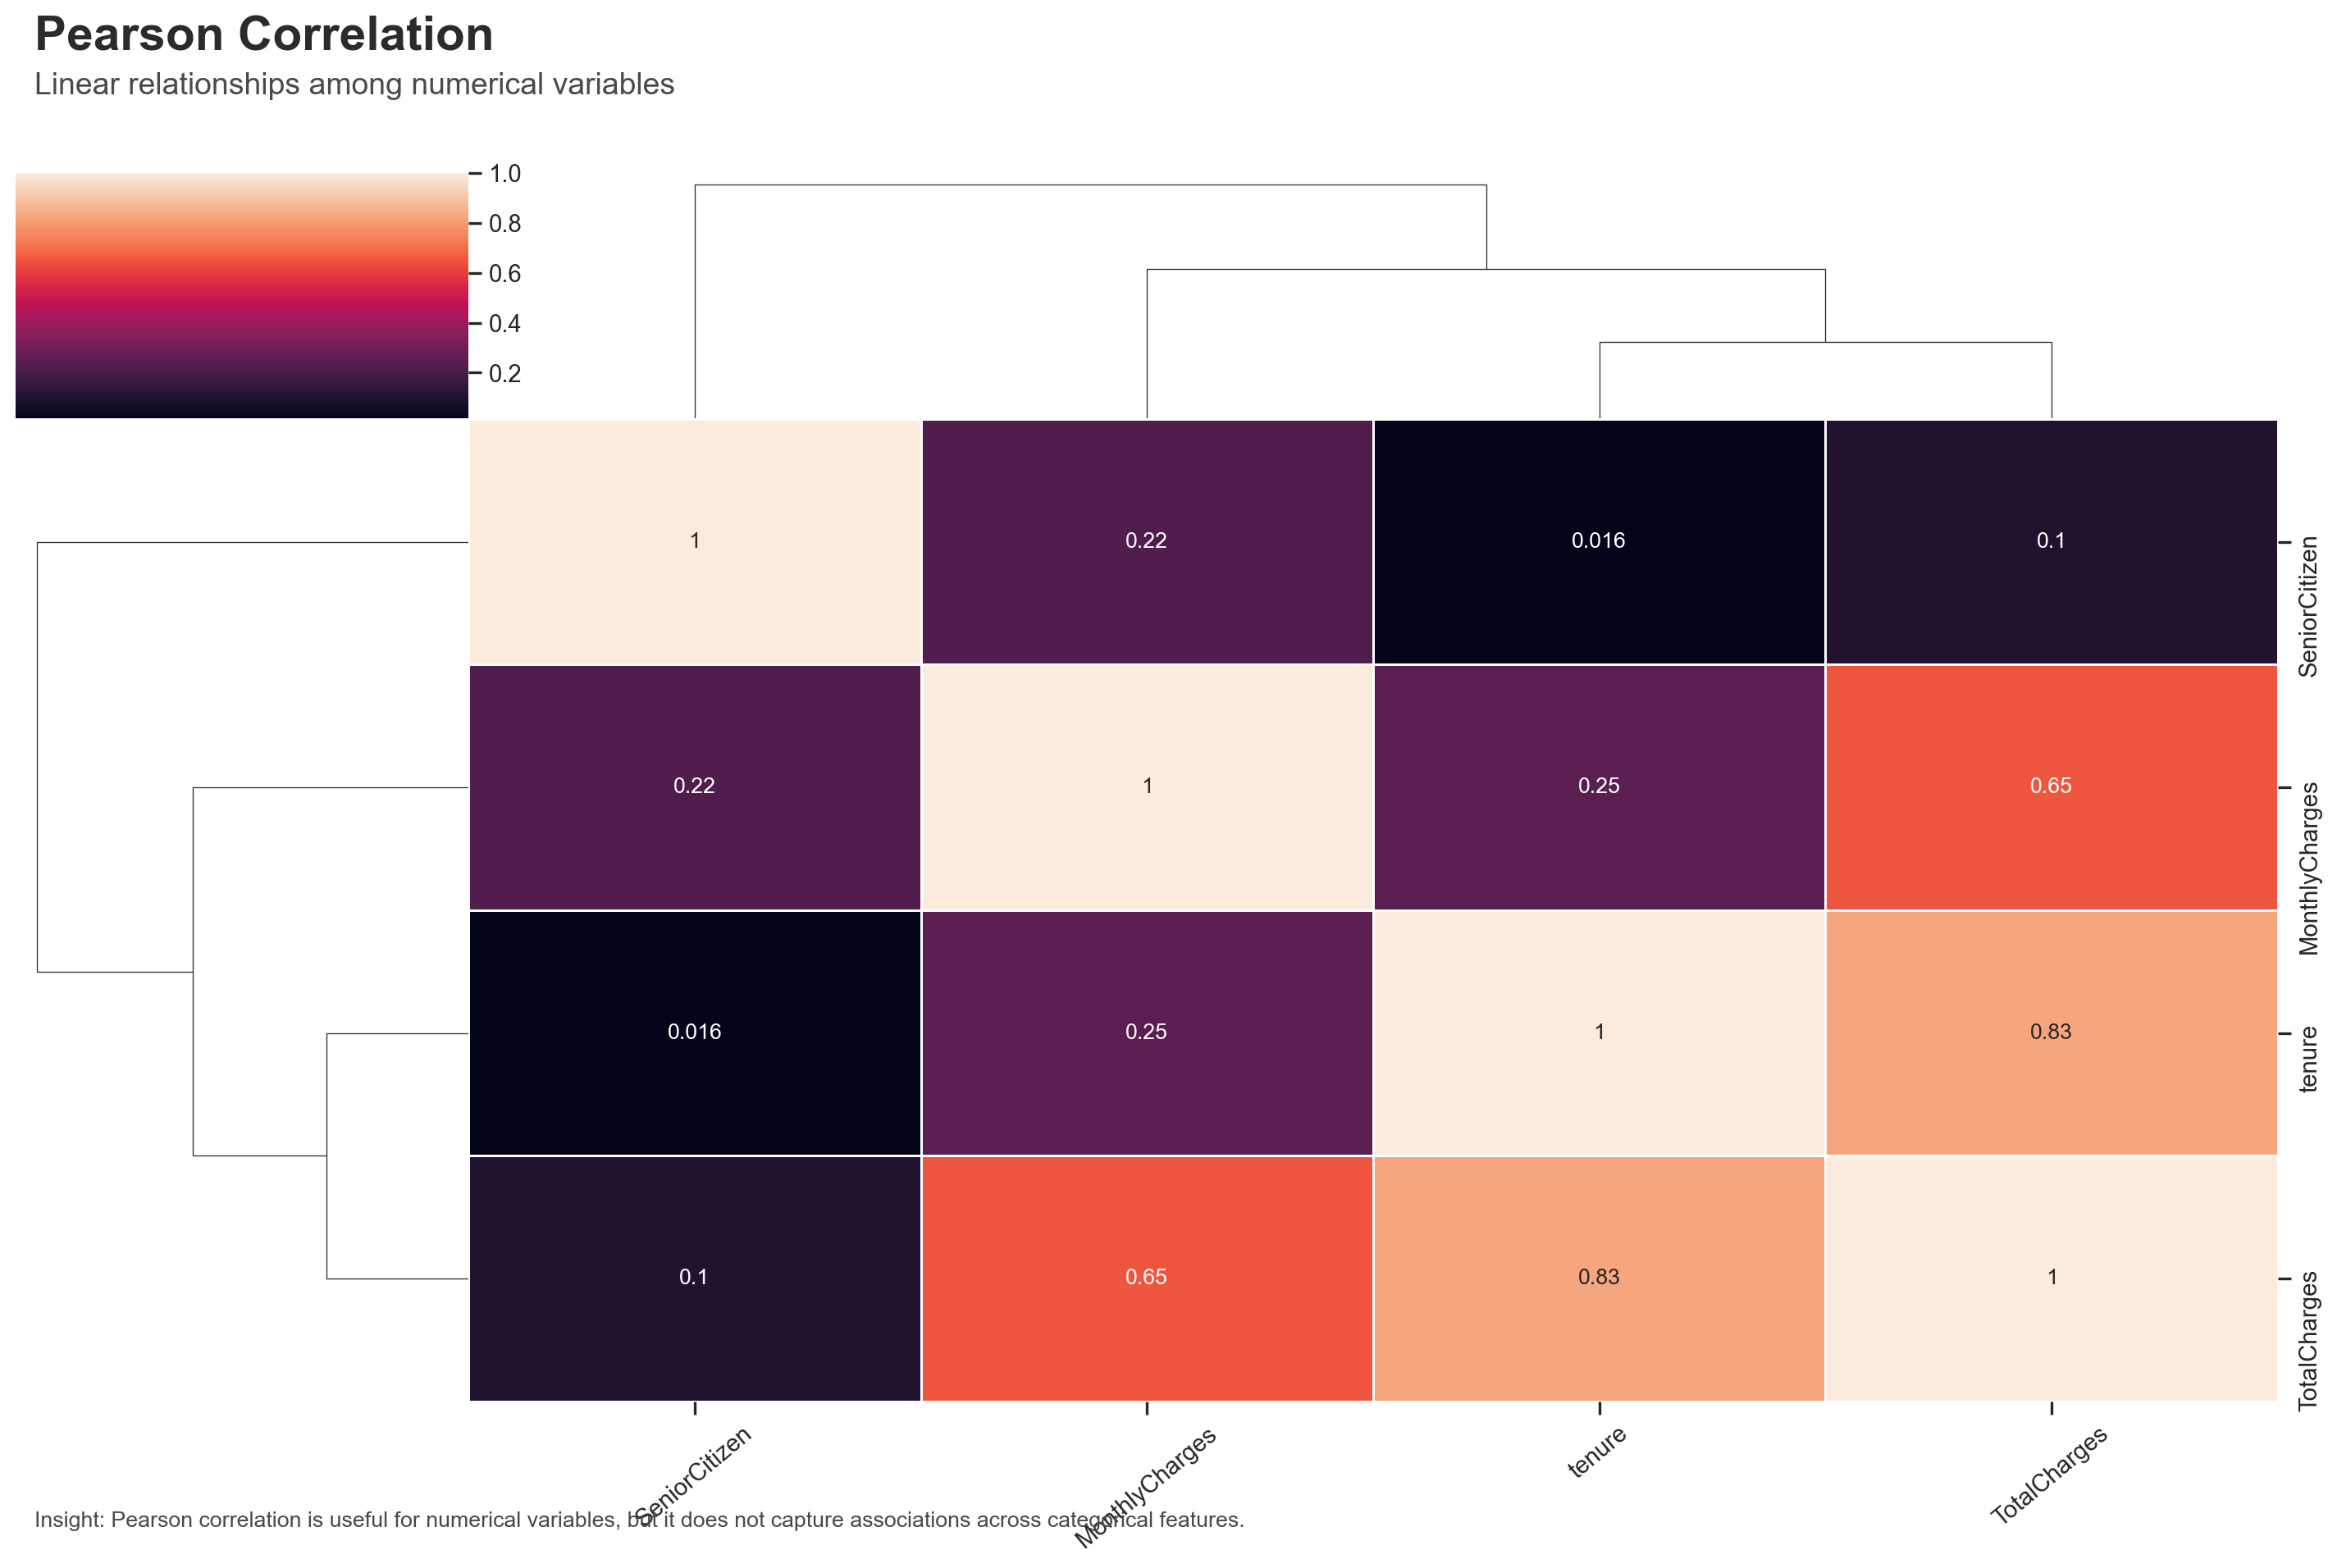

In [21]:
def plot_pearson_correlation(
    df,
    title="Pearson Correlation",
    subtitle="Linear relationships among numerical variables",
    footer_text=None,
    show_footer=False,
    annot=True,
    figsize=(15, 10)
):
    """
    Plot Pearson correlation clustermap for numerical variables only.
    """

    numerical_features = df.select_dtypes(exclude=['category', 'object']).columns.tolist()
    corr_matrix = df[numerical_features].corr(method='pearson')

    cg = sns.clustermap(
        corr_matrix,
        annot=annot,
        annot_kws={"size": 10},
        linewidths=0.4,
        figsize=figsize,
        cmap="rocket"
    )

    # Tick labels
    plt.setp(
        cg.ax_heatmap.xaxis.get_majorticklabels(),
        rotation=40
    )

    fig = cg.figure

    # Header
    fig.suptitle(title, x=0.02, y=0.98, ha='left', fontsize=22, fontweight='bold', color='#2b2b2b')
    if subtitle:
        fig.text(0.02, 0.93, subtitle, ha='left', fontsize=14, color='#4a4a4a')

    # Footer
    if show_footer and footer_text:
        fig.text(0.02, 0.02, footer_text, ha='left', fontsize=10, color='#4a4a4a')

    # Layout
    fig.subplots_adjust(top=0.93 if not subtitle else 0.88, bottom=0.08 if not show_footer else 0.10)

    plt.show()

    return corr_matrix

pearson_corr = plot_pearson_correlation(
    telecom,
    title="Pearson Correlation",
    subtitle="Linear relationships among numerical variables",
    footer_text="Insight: Pearson correlation is useful for numerical variables, but it does not capture associations across categorical features.",
    show_footer=True
)

**Insights:**
- Most variables in this dataset are categorical, so Pearson correlation provides only a partial view of the dependency structure.
- Among the numerical variables, `tenure` and `TotalCharges` show strong positive correlation, which is expected given the cumulative nature of total billing.
- `MonthlyCharges` also shows relevant association with `TotalCharges`, although its relationship with other variables is less informative in isolation.
- Because Pearson correlation is limited to numerical variables and linear relationships, it is not sufficient for assessing associations in this mixed-type dataset.

<span style="color:steelblue; text-align: left">

### Multicollinearity and PhiK Correlation
</span>

Since this dataset contains a large number of categorical variables, Pearson correlation alone is not appropriate for evaluating the full dependency structure. To address this limitation, PhiK correlation is used as a more suitable alternative for mixed-type data.

PhiK is useful in this context because:
- it handles categorical, ordinal, and interval variables consistently;
- it captures non-linear relationships;
- it is appropriate for mixed-type datasets such as this telecom churn dataset.



interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


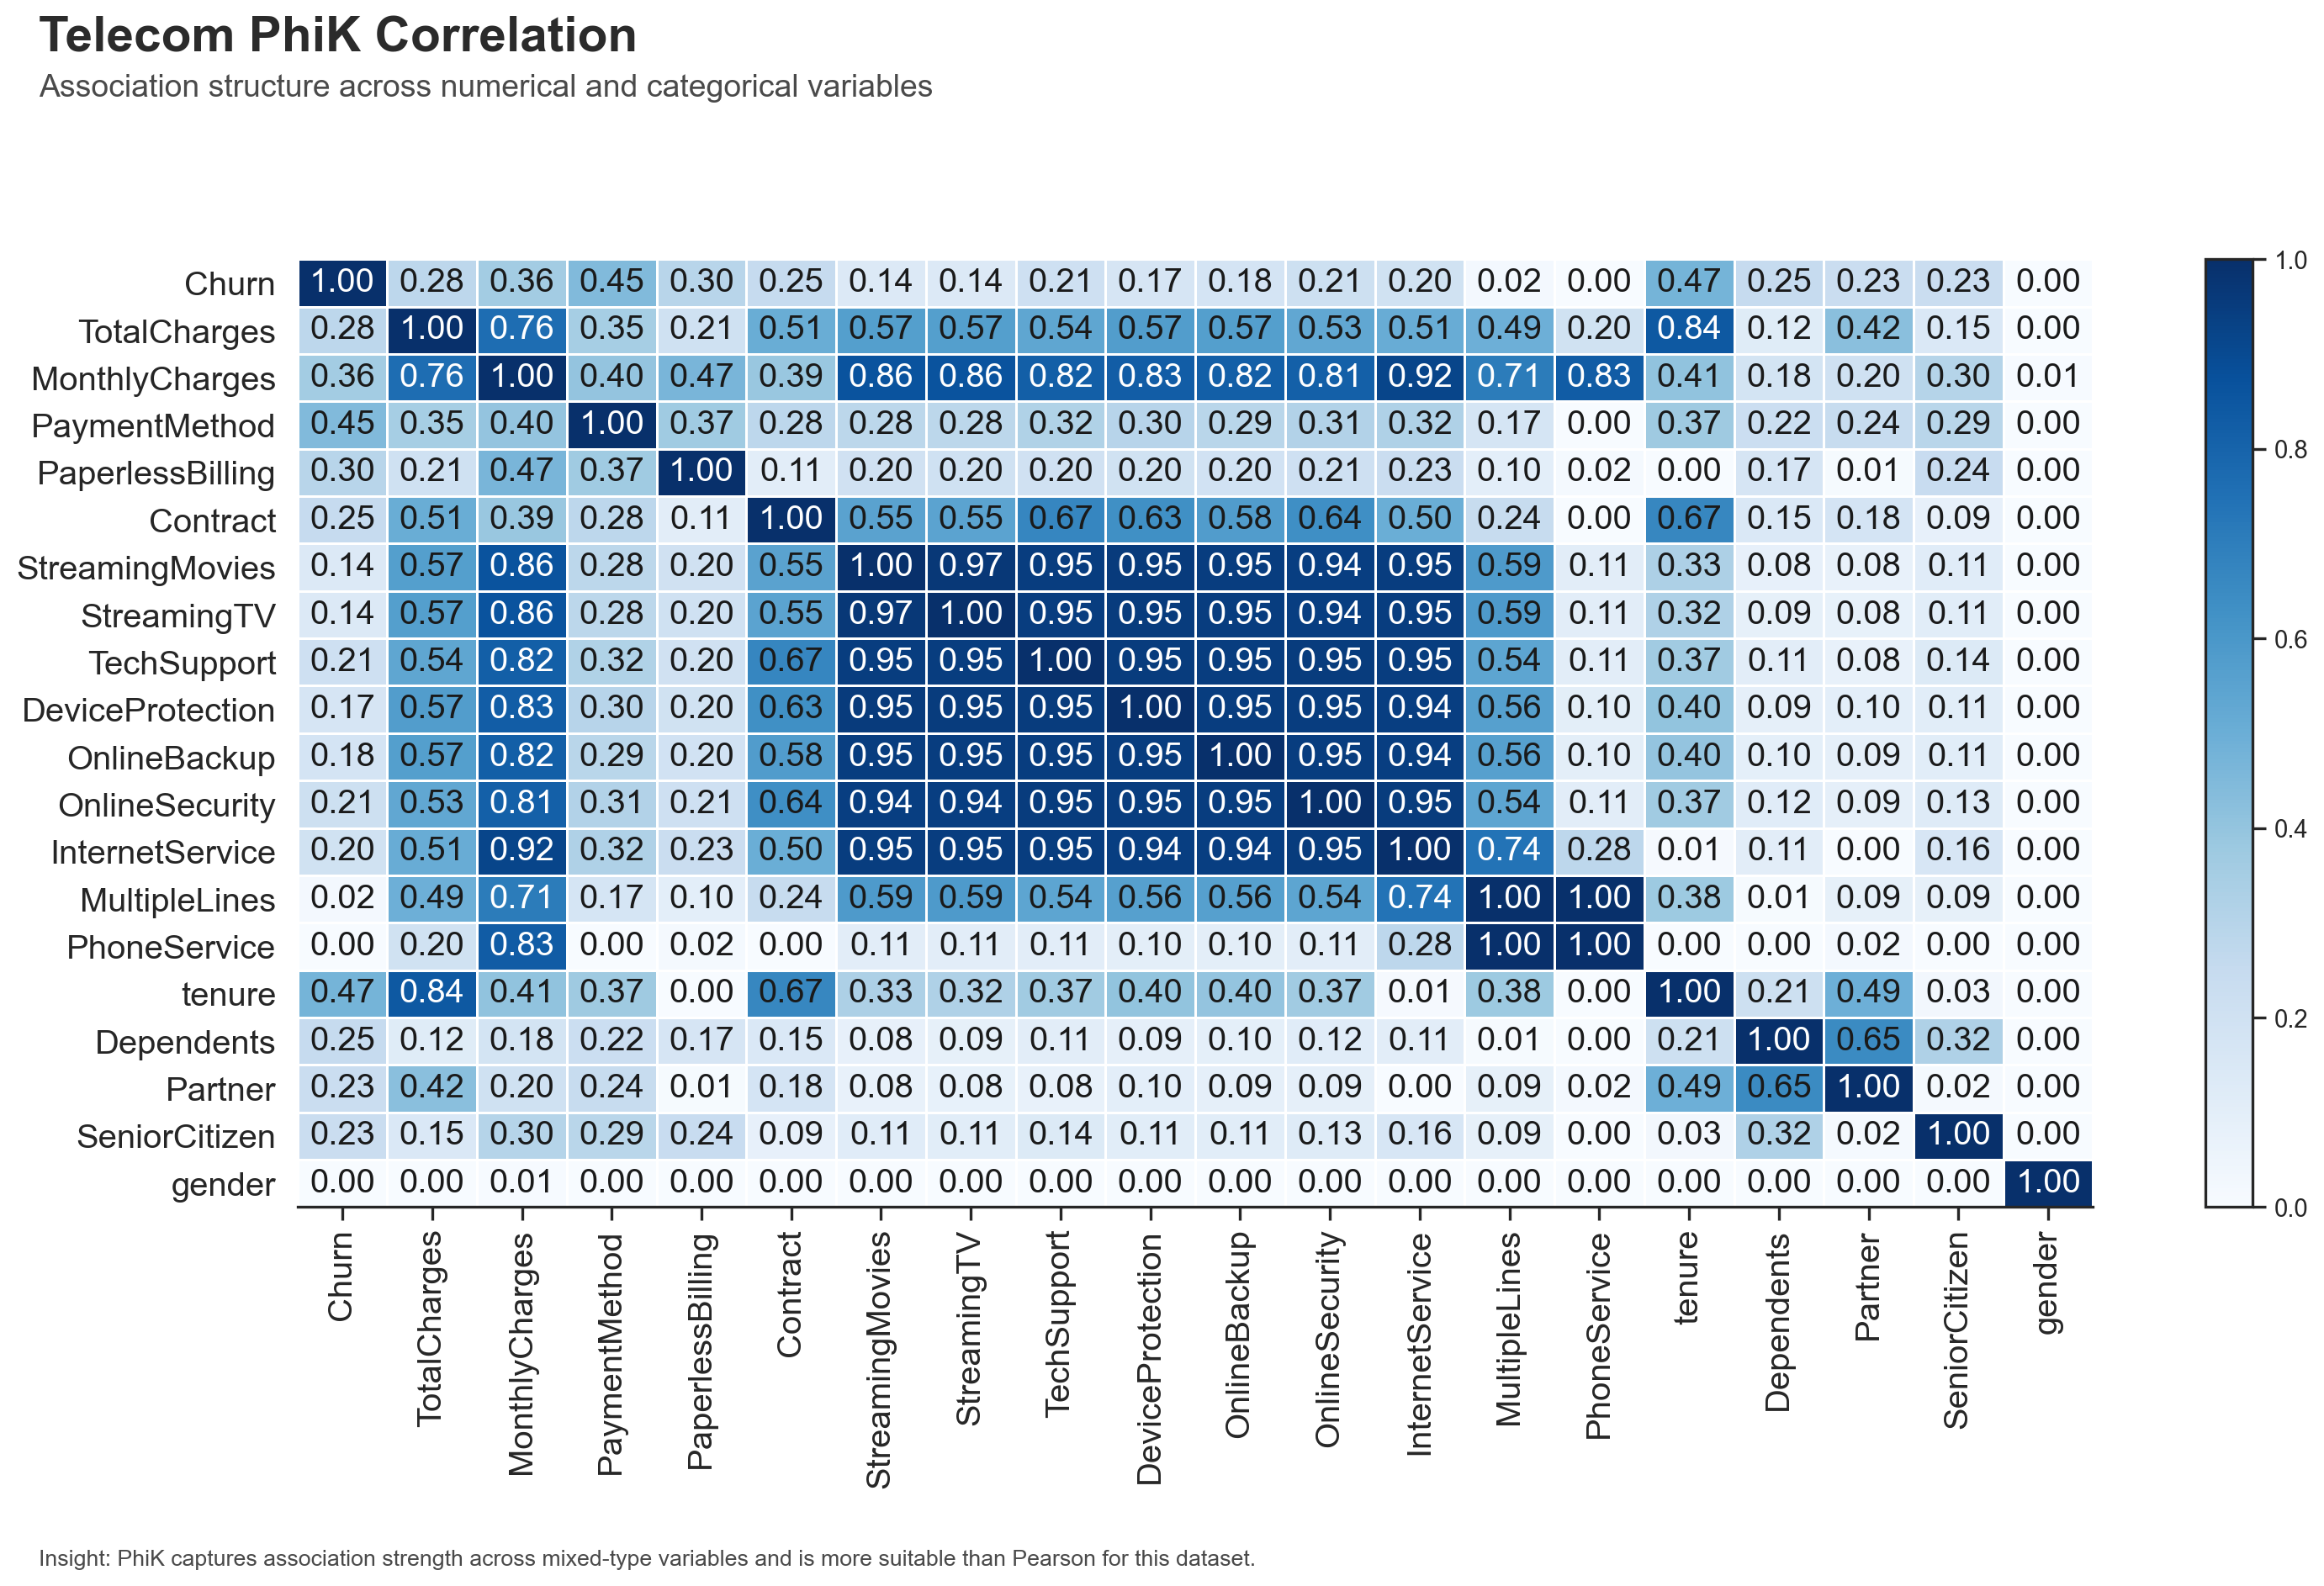

In [22]:
def plot_phik_correlation(
    df,
    drop_cols=None,
    title="Telecom PhiK Correlation",
    subtitle="Association structure across mixed-type variables",
    footer_text=None,
    show_footer=False,
    figsize=(16, 10),
    color_map="Blues"
):
    """
    Plot PhiK correlation matrix for mixed-type variables.
    """

    import phik
    from phik.report import plot_correlation_matrix

    data = df.copy(deep=True)

    if drop_cols is not None:
        data = data.drop(columns=drop_cols)

    phik_matrix = data.phik_matrix()

    plot_correlation_matrix(
        phik_matrix.values,
        x_labels=phik_matrix.columns,
        y_labels=phik_matrix.index,
        vmin=0,
        vmax=1,
        color_map=color_map,
        title="",
        fontsize_factor=1.5,
        figsize=figsize
    )

    fig = plt.gcf()

    # Header
    fig.suptitle(title, x=0.02, y=0.98, ha='left', fontsize=22, fontweight='bold', color='#2b2b2b')
    if subtitle:
        fig.text(0.02, 0.93, subtitle, ha='left', fontsize=14, color='#4a4a4a')

    # Footer
    if show_footer and footer_text:
        fig.text(0.02, 0.02, footer_text, ha='left', fontsize=10, color='#4a4a4a')

    plt.tight_layout(rect=[0, 0.05 if show_footer else 0.06, 1, 0.90])
    plt.show()

    return phik_matrix

phik_view = plot_phik_correlation(
    telecom,
    drop_cols=['customerID'],
    title="Telecom PhiK Correlation",
    subtitle="Association structure across numerical and categorical variables",
    footer_text="Insight: PhiK captures association strength across mixed-type variables and is more suitable than Pearson for this dataset.",
    show_footer=True
)

**Insights:**
- PhiK provides a broader view of association patterns across both numerical and categorical variables.
- Several variable pairs show moderate to strong association, especially among service-related, billing, and contract-related features.
- PhiK values range from 0 to 1 and measure strength of association only, not direction.
- Values close to zero indicate weak or negligible association.

interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


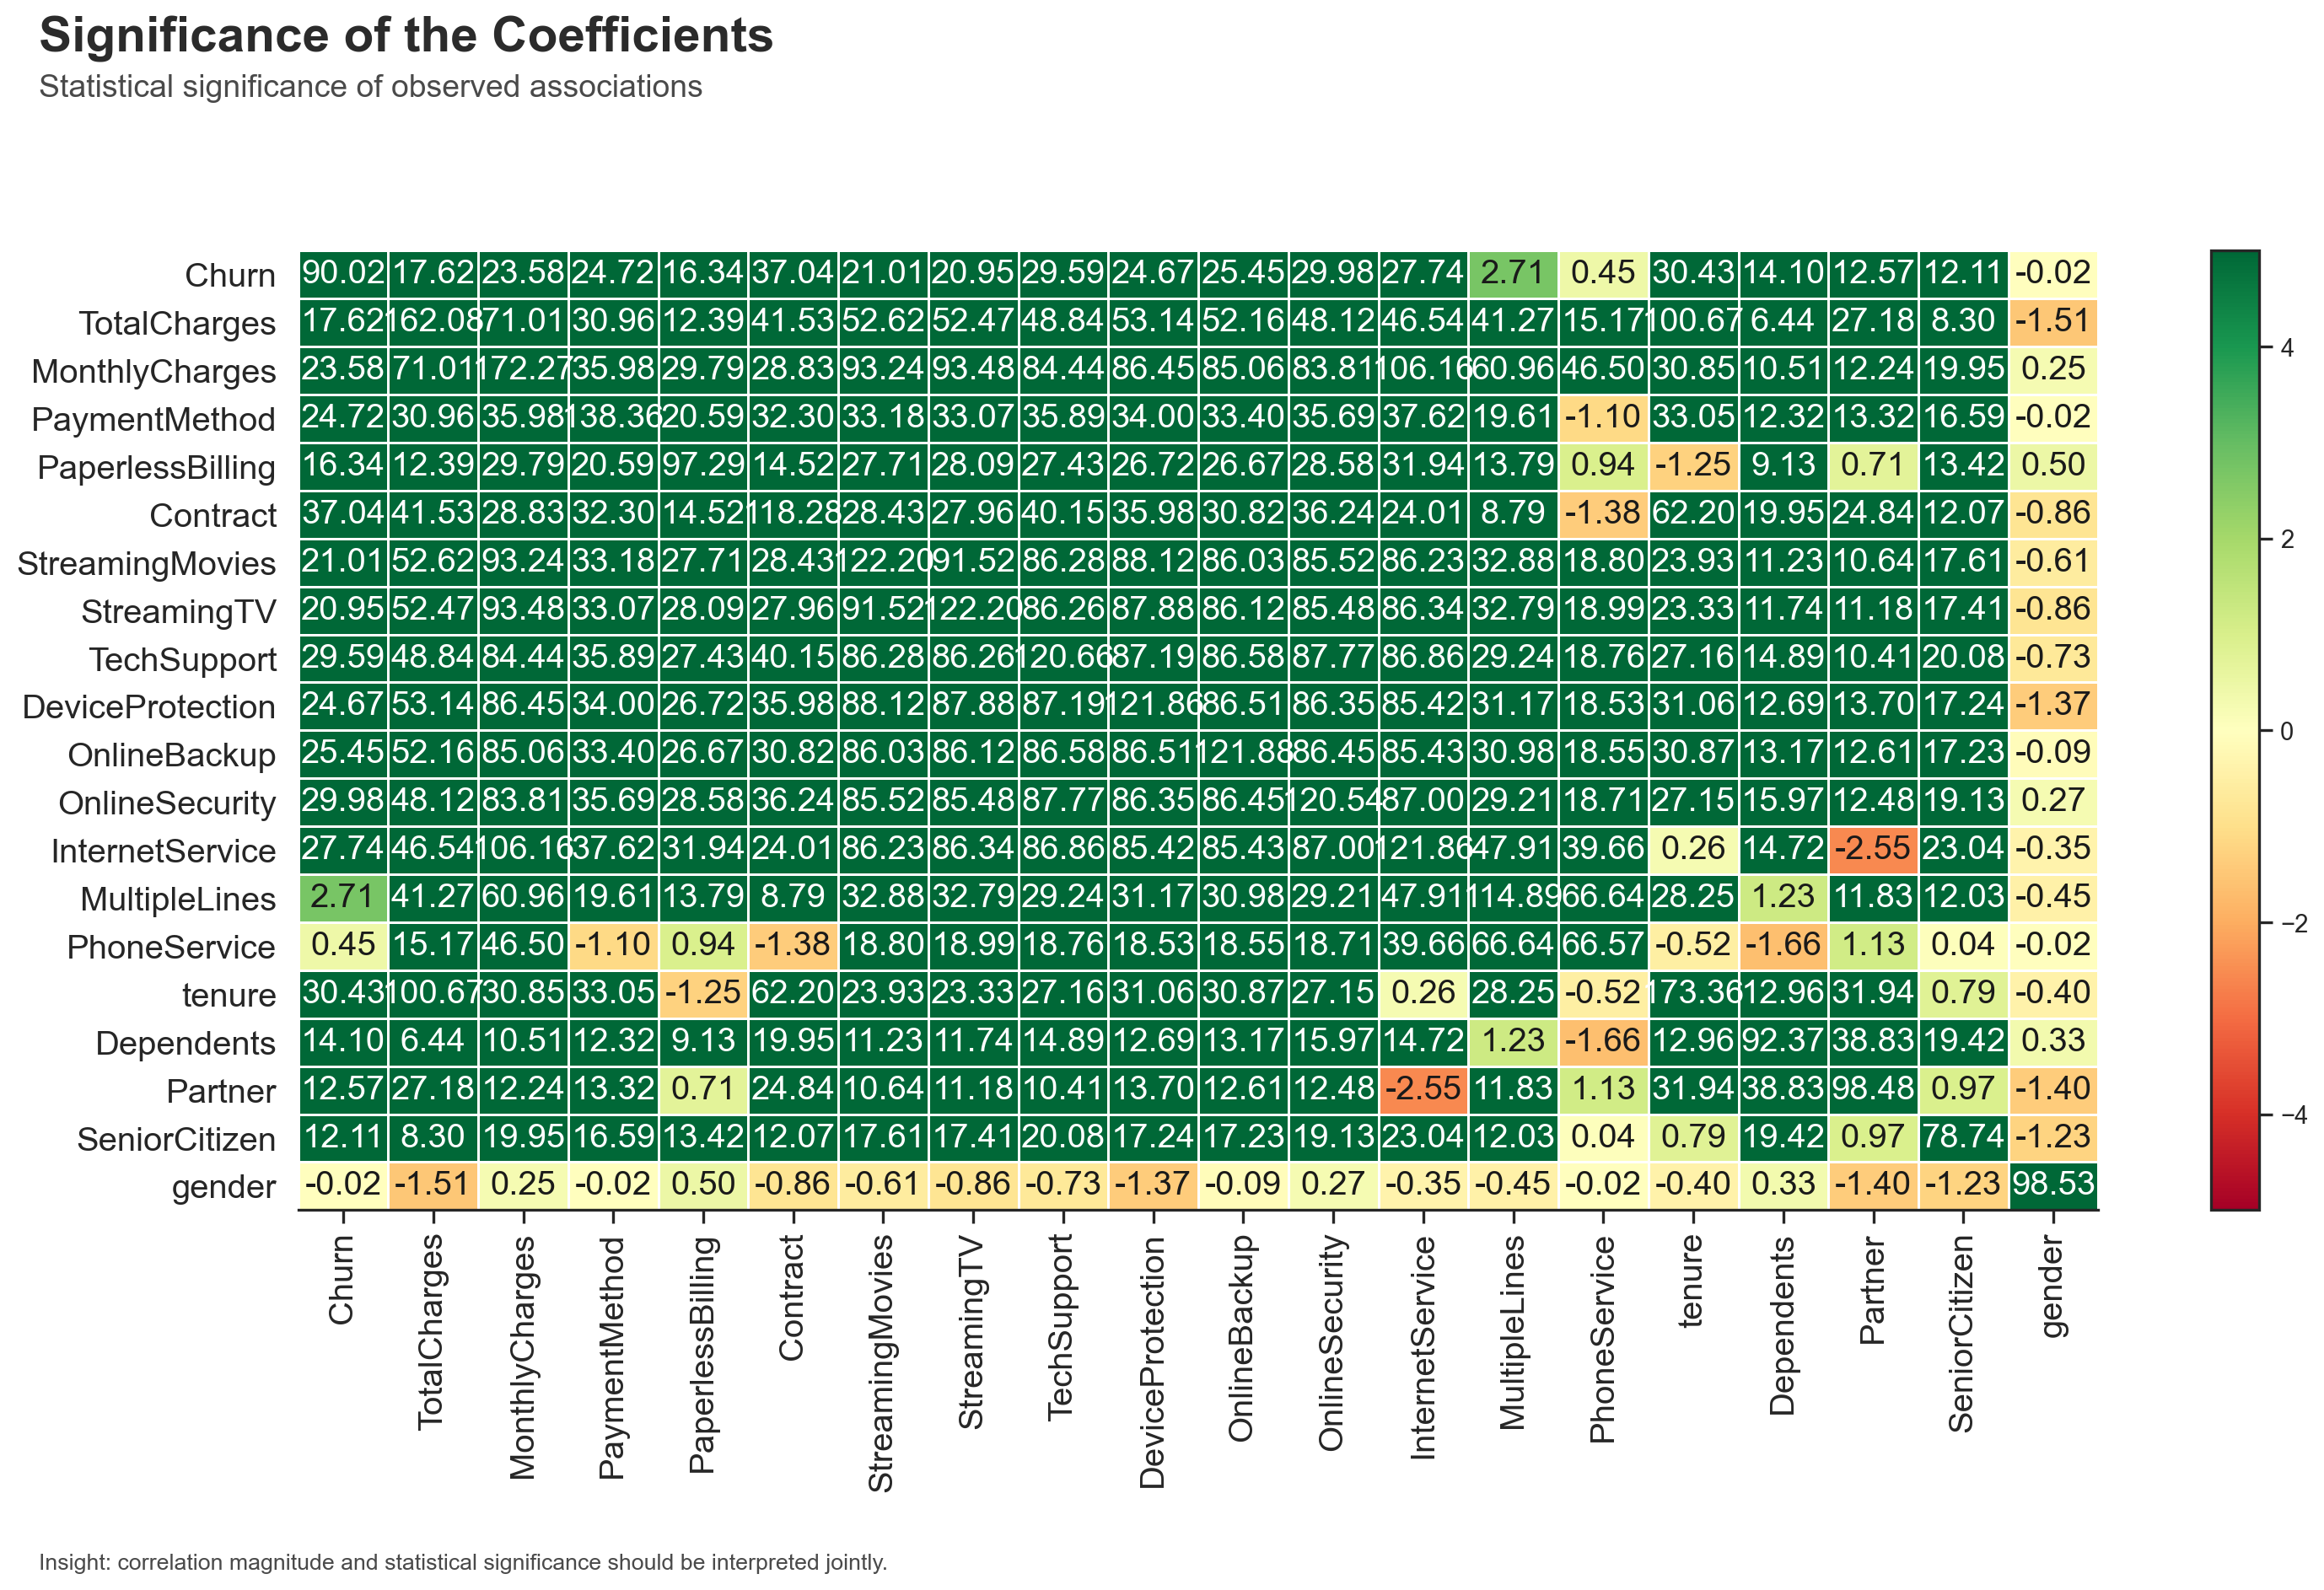

In [23]:
def plot_phik_significance(
    df,
    drop_cols=None,
    title="Significance of the Coefficients",
    subtitle="Statistical significance of observed associations",
    footer_text=None,
    show_footer=False,
    figsize=(16, 10)
):
    """
    Plot PhiK significance matrix.
    """

    import phik
    from phik.report import plot_correlation_matrix

    data = df.copy(deep=True)

    if drop_cols is not None:
        data = data.drop(columns=drop_cols)

    significance_overview = data.significance_matrix()

    plot_correlation_matrix(
        significance_overview.fillna(0).values,
        x_labels=significance_overview.columns,
        y_labels=significance_overview.index,
        vmin=-5,
        vmax=5,
        title="",
        usetex=False,
        fontsize_factor=1.5,
        figsize=figsize
    )

    fig = plt.gcf()

    # Header
    fig.suptitle(title, x=0.02, y=0.98, ha='left', fontsize=22, fontweight='bold', color='#2b2b2b')
    if subtitle:
        fig.text(0.02, 0.93, subtitle, ha='left', fontsize=14, color='#4a4a4a')

    # Footer
    if show_footer and footer_text:
        fig.text(0.02, 0.02, footer_text, ha='left', fontsize=10, color='#4a4a4a')

    plt.tight_layout(rect=[0, 0.05 if show_footer else 0.06, 1, 0.90])
    plt.show()

    return significance_overview

significance_overview = plot_phik_significance(
    telecom,
    drop_cols=['customerID'],
    title="Significance of the Coefficients",
    subtitle="Statistical significance of observed associations",
    footer_text="Insight: correlation magnitude and statistical significance should be interpreted jointly.",
    show_footer=True
)

The significance matrix complements the PhiK correlation matrix by showing whether the observed associations are statistically meaningful.

**Insights:**
- Correlation strength and statistical significance should be interpreted jointly.
- A strong association may not be statistically meaningful, while a weaker one may still be highly significant.
- This helps distinguish relevant dependency patterns from incidental ones.


In [24]:
def build_phik_significance_df(df, drop_cols=None):
    """
    Build a dataframe with variable pairs, Phik correlation and significance.
    """

    import phik
    
    data = df.copy()

    if drop_cols:
        data = data.drop(columns=drop_cols)

    phik_matrix = data.phik_matrix()
    significance_matrix = data.significance_matrix()

    records = []

    cols = phik_matrix.columns

    for i in range(len(cols)):
        for j in range(i+1, len(cols)):  # evita duplicados e diagonal
            var1 = cols[i]
            var2 = cols[j]

            records.append({
                'var1': var1,
                'var2': var2,
                'phik': phik_matrix.iloc[i, j],
                'significance': significance_matrix.iloc[i, j]
            })

    result_df = pd.DataFrame(records)

    return result_df.sort_values(by='phik', ascending=False)

phik_df = build_phik_significance_df(telecom, drop_cols=['customerID'])
phik_df.head(15).round(4)

interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
interval columns not set, guessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.0000,66.6466
162,StreamingTV,StreamingMovies,0.9654,91.5205
147,DeviceProtection,StreamingMovies,0.9538,88.1210
146,DeviceProtection,StreamingTV,0.9528,87.8777
126,OnlineSecurity,TechSupport,0.9526,87.7759
145,DeviceProtection,TechSupport,0.9502,87.1935
112,InternetService,OnlineSecurity,0.9495,86.9998
115,InternetService,TechSupport,0.9489,86.8561
136,OnlineBackup,TechSupport,0.9477,86.5856
135,OnlineBackup,DeviceProtection,0.9475,86.5166


**Insights**:
- Strong dependencies are observed among billing-related variables (MonthlyCharges, TotalCharges, tenure), confirming the cumulative structure of customer revenue over time.
- Service-related features (e.g., StreamingTV, StreamingMovies, PhoneService) show high association with MonthlyCharges, indicating that additional services are key drivers of customer spending.
- Contract type presents a strong relationship with tenure, reinforcing the role of long-term contracts in customer retention.
- Household-related variables (Partner, Dependents) are also highly associated, reflecting expected demographic clustering.

In [25]:
def filter_relevant_relationships(df, phik_threshold=0.3, significance_threshold=5):
    """
    Filter relevant relationships based on Phik and significance.
    """

    return df[
        (df['phik'] >= phik_threshold) &
        (df['significance'] >= significance_threshold)
    ].sort_values(by='phik', ascending=False)
    
relevant_pairs = filter_relevant_relationships(phik_df)
relevant_pairs.head(15).round(4)    

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.0000,66.6466
162,StreamingTV,StreamingMovies,0.9654,91.5205
147,DeviceProtection,StreamingMovies,0.9538,88.1210
146,DeviceProtection,StreamingTV,0.9528,87.8777
126,OnlineSecurity,TechSupport,0.9526,87.7759
145,DeviceProtection,TechSupport,0.9502,87.1935
112,InternetService,OnlineSecurity,0.9495,86.9998
115,InternetService,TechSupport,0.9489,86.8561
136,OnlineBackup,TechSupport,0.9477,86.5856
135,OnlineBackup,DeviceProtection,0.9475,86.5166


Who has relationship with churn? 

In [26]:
phik_df[phik_df['var2'] == 'Churn'].sort_values(by='phik', ascending=False)

,var1,var2,phik,significance
84,tenure,Churn,0.473761,30.431082
186,PaymentMethod,Churn,0.448559,24.725625
188,MonthlyCharges,Churn,0.359612,23.585504
183,PaperlessBilling,Churn,0.295194,16.337414
189,TotalCharges,Churn,0.280973,17.608241
69,Dependents,Churn,0.252268,14.086698
179,Contract,Churn,0.251283,37.035784
36,SeniorCitizen,Churn,0.232897,12.098000
53,Partner,Churn,0.232215,12.585876
134,OnlineSecurity,Churn,0.211583,29.984095


**Insights**:
- Customer tenure emerges as the strongest driver of churn, indicating that early-stage customers are significantly more likely to leave, reinforcing the importance of onboarding and early retention strategies.
- Payment method shows a strong association with churn, suggesting that friction in billing processes or financial behavior may influence customer retention.
- Monthly charges are positively associated with churn, indicating that higher perceived cost may increase the likelihood of customer attrition.
- Contract type, despite a moderate correlation, presents very high statistical significance, highlighting its structural importance in customer retention—longer contracts are likely acting as retention mechanisms.
- Service-related features such as OnlineSecurity and TechSupport show moderate association with churn, suggesting that customers lacking these services may be more vulnerable to leaving.
- Demographic variables (e.g., gender) show no meaningful relationship with churn, indicating that behavioral and contractual factors dominate over static personal characteristics.

Where are there multicollinearity ?

In [27]:
phik_df[phik_df['phik'] > 0.7]

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.000000,66.646577
162,StreamingTV,StreamingMovies,0.965356,91.520540
147,DeviceProtection,StreamingMovies,0.953754,88.121031
146,DeviceProtection,StreamingTV,0.952815,87.877696
126,OnlineSecurity,TechSupport,0.952637,87.775895
145,DeviceProtection,TechSupport,0.950238,87.193462
112,InternetService,OnlineSecurity,0.949461,86.999775
115,InternetService,TechSupport,0.948878,86.856064
136,OnlineBackup,TechSupport,0.947746,86.585632
135,OnlineBackup,DeviceProtection,0.947480,86.516633


**Multicollinearity Insights**:
- Strong multicollinearity is observed among billing-related variables (tenure, MonthlyCharges, TotalCharges), reflecting the cumulative nature of customer billing. In particular, TotalCharges behaves as a derived feature rather than an independent predictor.
- Several service-related features (e.g., StreamingTV, StreamingMovies, PhoneService) show high association with MonthlyCharges, indicating that customer pricing is largely driven by bundled service adoption.
- High correlation between service variables (e.g., StreamingTV and StreamingMovies) suggests overlapping customer behavior patterns, potentially introducing redundancy in the feature space.
- These dependencies reflect underlying business logic rather than spurious statistical relationships, and should be handled carefully during model development to avoid redundancy and instability.
- To mitigate multicollinearity effects in linear models, TotalCharges will be excluded from the feature set, as it is a derived variable.

Strong relationship but useless or redundant ?

In [28]:
phik_df[(phik_df['phik'] > 0.8) & (phik_df['significance'] > 50)]

,var1,var2,phik,significance
85,PhoneService,MultipleLines,1.000000,66.646577
162,StreamingTV,StreamingMovies,0.965356,91.520540
147,DeviceProtection,StreamingMovies,0.953754,88.121031
146,DeviceProtection,StreamingTV,0.952815,87.877696
126,OnlineSecurity,TechSupport,0.952637,87.775895
145,DeviceProtection,TechSupport,0.950238,87.193462
112,InternetService,OnlineSecurity,0.949461,86.999775
115,InternetService,TechSupport,0.948878,86.856064
136,OnlineBackup,TechSupport,0.947746,86.585632
135,OnlineBackup,DeviceProtection,0.947480,86.516633


**Strong relationships: redundancy vs relevance**:
- The relationship between tenure and TotalCharges represents a deterministic dependency, as total charges are inherently a function of tenure and monthly charges. Therefore, TotalCharges is considered a redundant feature and may be excluded from linear models.
- The association between InternetService and MonthlyCharges reflects the pricing structure of the business, where service type directly influences billing. While highly correlated, both variables capture distinct aspects (service category vs. cost) and may be retained depending on model objectives.
- Service-related features such as StreamingTV and StreamingMovies show strong relationships with MonthlyCharges, indicating that pricing is largely driven by bundled services. These relationships represent partial redundancy, as service adoption is indirectly encoded in the billing variable.
- Overall, the observed high correlations are primarily driven by business logic rather than statistical artifacts, and should be handled selectively to balance interpretability and model performance.

<span style="color:steelblue; text-align: left">

###  Churn vs Tenure
</span>

Customer tenure shows a clear relationship with churn behavior. Customers who remain with the company for longer periods are significantly less likely to churn, while churn is predominantly concentrated among customers with shorter tenure.

This pattern suggests that the early stages of the customer lifecycle are critical for retention, highlighting the importance of onboarding and initial engagement strategies.

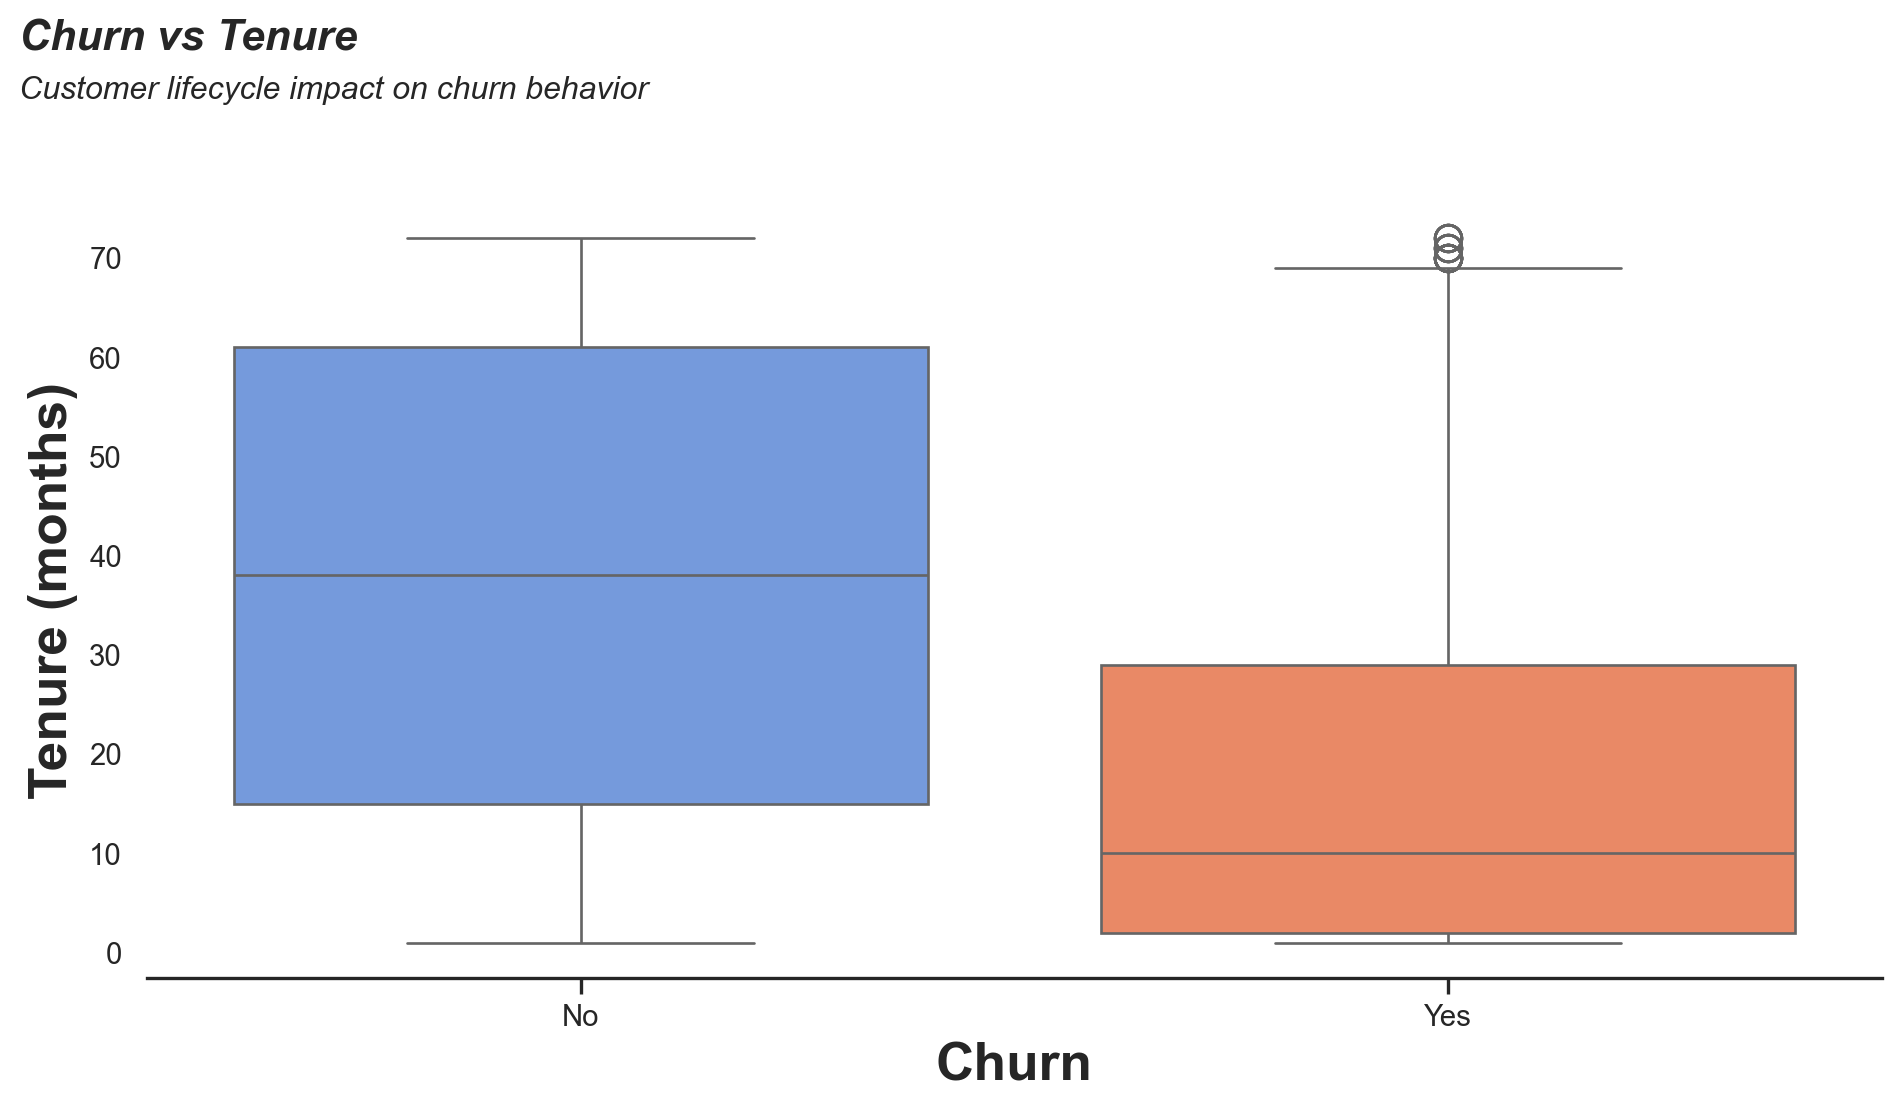

phik         = 0.4709
significance = 29.0656


In [29]:
def plot_churn_vs_tenure(df, churn_col='Churn', tenure_col='tenure'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import phik
    import pandas as pd

    data = df.copy()

    # Encode churn
    data[churn_col] = data[churn_col].map({'No': 0, 'Yes': 1})

    # ===== Plot =====
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        x=df[churn_col],
        y=df[tenure_col],
        palette=['cornflowerblue', 'coral'],
        ax=ax
    )

    # Labels
    ax.set_xlabel('Churn')
    ax.set_ylabel('Tenure (months)')

    # ===== Header padrão =====
    add_finance_header(
        fig,
        title="Churn vs Tenure",
        subtitle="Customer lifecycle impact on churn behavior"
    )

    plt.grid(False)
    plt.tight_layout()
    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

    # ===== Phik =====
    x, y = data[[churn_col, tenure_col]].T.values

    phik_value = phik.phik_from_array(x, y, num_vars=['x'])
    significance = phik.significance_from_array(x, y, num_vars=['x'])[1]

    print(f'phik         = {phik_value:.4f}')
    print(f'significance = {significance:.4f}')
    
plot_churn_vs_tenure(telecom)    

**Insights:**
- Customers with shorter tenure exhibit significantly higher churn rates, indicating that churn risk is concentrated in the early lifecycle stages.
- Customers who remain longer tend to stabilize and are less likely to leave, suggesting a strong retention effect over time.
- Tenure emerges as one of the strongest predictors of churn, reinforcing its importance in downstream modeling.

<span style="color:steelblue; text-align: left">

###  Churn vs Contract
</span>

Churn by Contract Type: Similar to what we saw in the correlation plot, the customers who have a month to month contract have a very high churn rate.

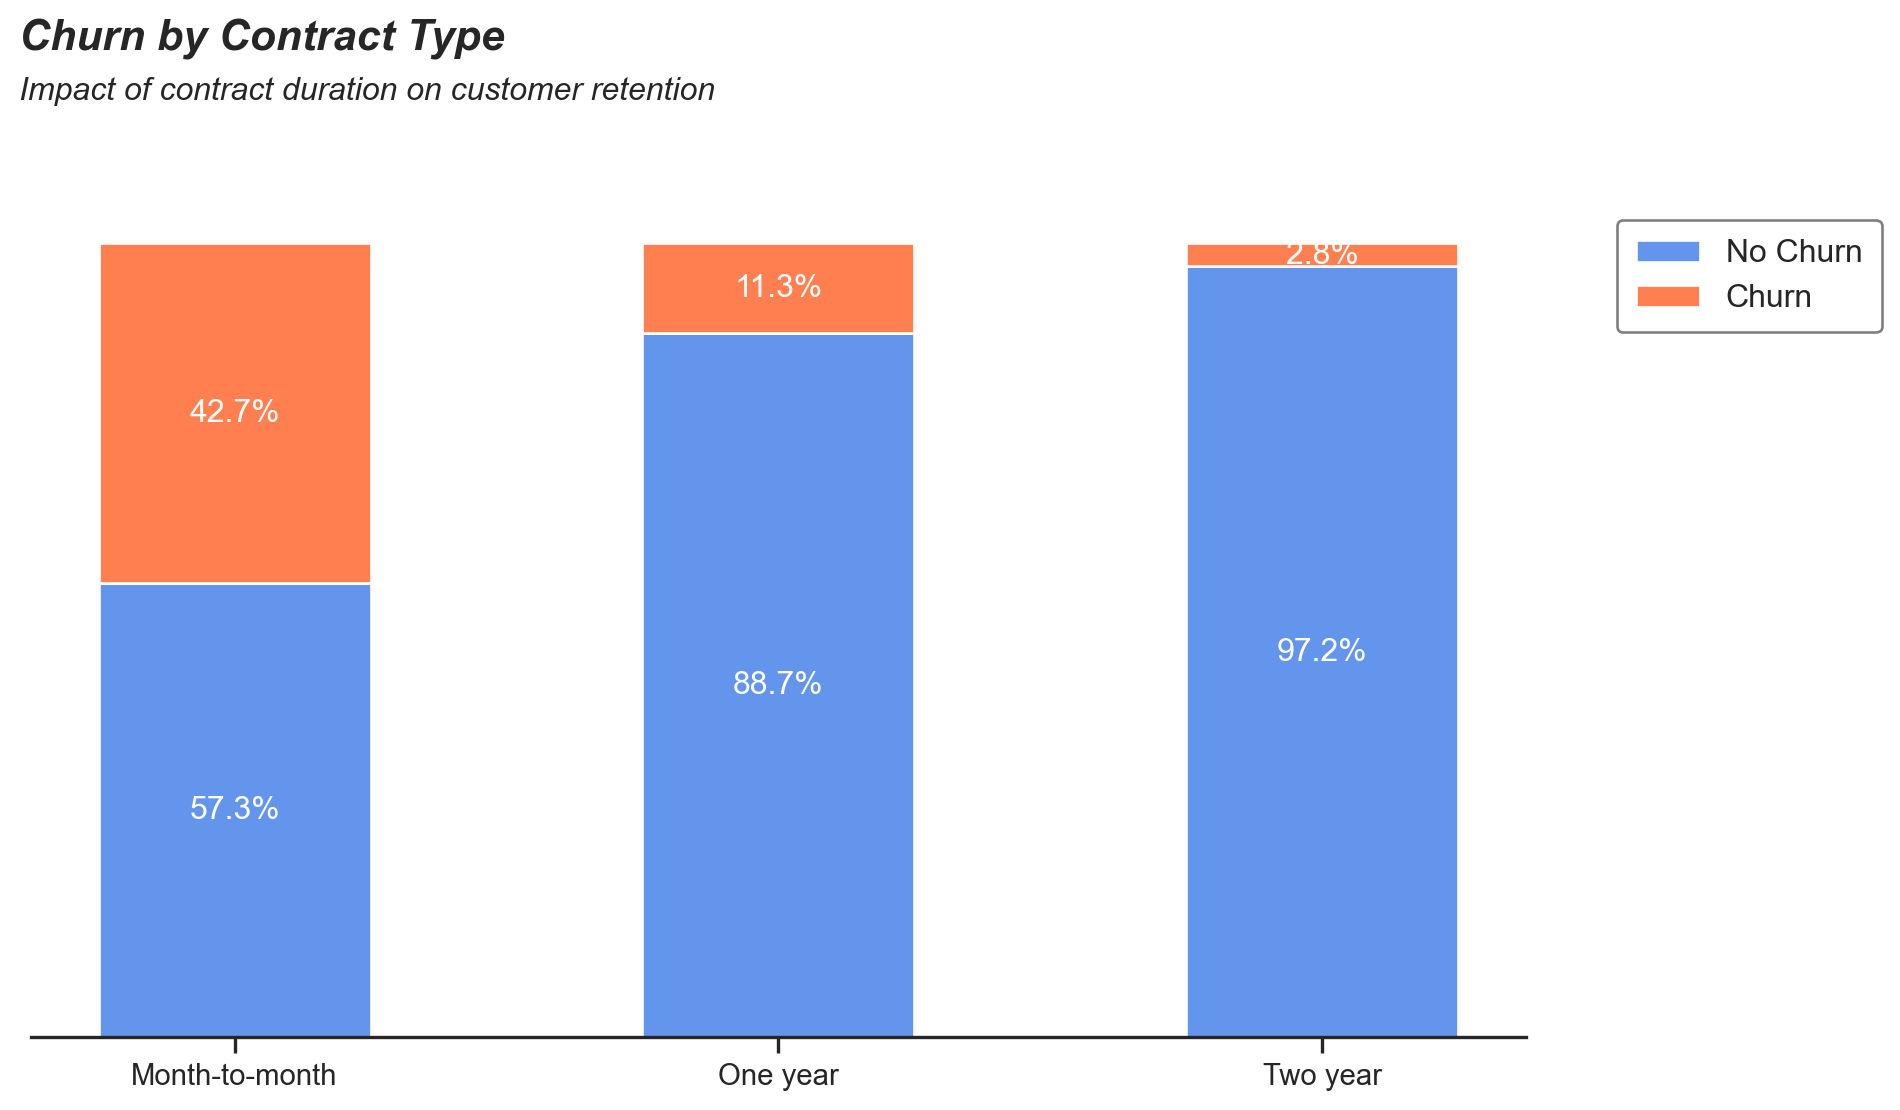

phik         = 0.2513
significance = 37.0396


In [30]:
def plot_churn_vs_contract(df, churn_col='Churn', contract_col='Contract'):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.ticker as mtick

    # ===== Preparação =====
    contract_churn = df.groupby([contract_col, churn_col]).size().unstack()

    pct = (contract_churn.T * 100.0 / contract_churn.T.sum()).T

    index = pct.index.tolist()

    data_plot = {
        'No Churn': pct['No'].values,
        'Churn': pct['Yes'].values
    }

    colors = ['cornflowerblue', 'coral']  # padrão consistente
    width = 0.5

    # ===== Plot =====
    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(index))

    for i, (label, values) in enumerate(data_plot.items()):
        bars = ax.bar(index, values, width, bottom=bottom, label=label, color=colors[i])
        ax.bar_label(bars, label_type='center', fmt='%.1f%%', color='white')
        bottom += values

    # ===== Header padrão =====
    add_finance_header(
        fig,
        title="Churn by Contract Type",
        subtitle="Impact of contract duration on customer retention"
    )

    ax.get_yaxis().set_visible(False)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(False)
    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

    # ===== Phik =====
    data = df.copy()
    data[churn_col] = data[churn_col].map({'No': 0, 'Yes': 1})

    x, y = data[[churn_col, contract_col]].T.values

    import phik
    phik_value = phik.phik_from_array(x, y)
    significance = phik.significance_from_array(x, y)[1]

    print(f'phik         = {phik_value:.4f}')
    print(f'significance = {significance:.4f}')
    
plot_churn_vs_contract(telecom)    

**Insights:**
- Customers on month-to-month contracts exhibit extremely high churn (~43%), indicating low commitment and high switching flexibility.
- Moving from month-to-month to one-year contracts reduces churn by ~3.8x, while two-year contracts reduce churn by ~15x.
- This demonstrates a strong non-linear relationship between contract duration and retention, where longer commitments act as a powerful retention mechanism.
- Contract type is not just correlated with churn — it is structurally linked to customer lifecycle stability.



<span style="color:steelblue; text-align: left">

###  Churn vs Monthly Charges
</span>


Customers with higher monthly charges exhibit a higher propensity to churn.

To better understand the distributional behavior, we analyze skewness and kurtosis:

- **Skewness** measures asymmetry:
  - Positive : right tail (higher values)
  - Negative : left tail (lower values)
  - Near zero : symmetric distribution

- **Kurtosis** measures tail weight relative to a normal distribution:
  - < 3 : Platykurtic (lighter tails, fewer outliers)
  - = 3 : Mesokurtic (normal-like)
  - > 3 : Leptokurtic (heavier tails, more extreme values)

This analysis helps assess whether churn differences are driven by structural shifts or distributional shape.


In [31]:
import pandas as pd
import numpy as np
import sklearn
import optuna
import phik
import shap
import xgboost
import lightgbm
import imblearn
import seaborn as sns
import matplotlib.pyplot as plt

print("Ambiente OK 🚀")

Ambiente OK 🚀


In [32]:
def show_skewness(data:pd.DataFrame,x='', detail=''):
    l_skew = data[x].skew()
    l_kurtosis = data[x].kurt()
    l_mean = data[x].mean() 

    # Right or left 
    if l_skew < 0:
        l_direction = ' Left '

    elif l_skew > 0:
        l_direction = ' Right '

    # If the skewness is between -0.5 and 0.5, the data are fairly symmetrical
    if l_skew > 0.5 and l_skew < 0.5:
        g_mess = x + ' variable are fairly symmetrical'

    # If the skewness is between -1 and — 0.5 or between 0.5 and 1, the data are moderately skewed
    elif l_skew > -1 and l_skew < 1: 
        g_mess = x + ' variable are moderately' + l_direction + 'Skewed'

    # If the skewness is less than -1 or greater than 1, the data are highly skewed
    else:
        g_mess = x + ' variable are highly' + l_direction + 'Skewed'

    # Kurtosis
    if l_kurtosis > l_mean:
        l_mess_kurtosis = ' Leptokurtic '
    
    elif l_kurtosis < l_mean:
        l_mess_kurtosis = ' Platykurtic '
    
    else:
        l_mess_kurtosis = ' Mesokurtic '

    g_mess += l_mess_kurtosis
    print(f'''
    Skewness for {x} when customer {detail}:
        Skew     : {l_skew:.4f}
        Kurtosis : {l_kurtosis:.4f}
            - {g_mess}
    ''')


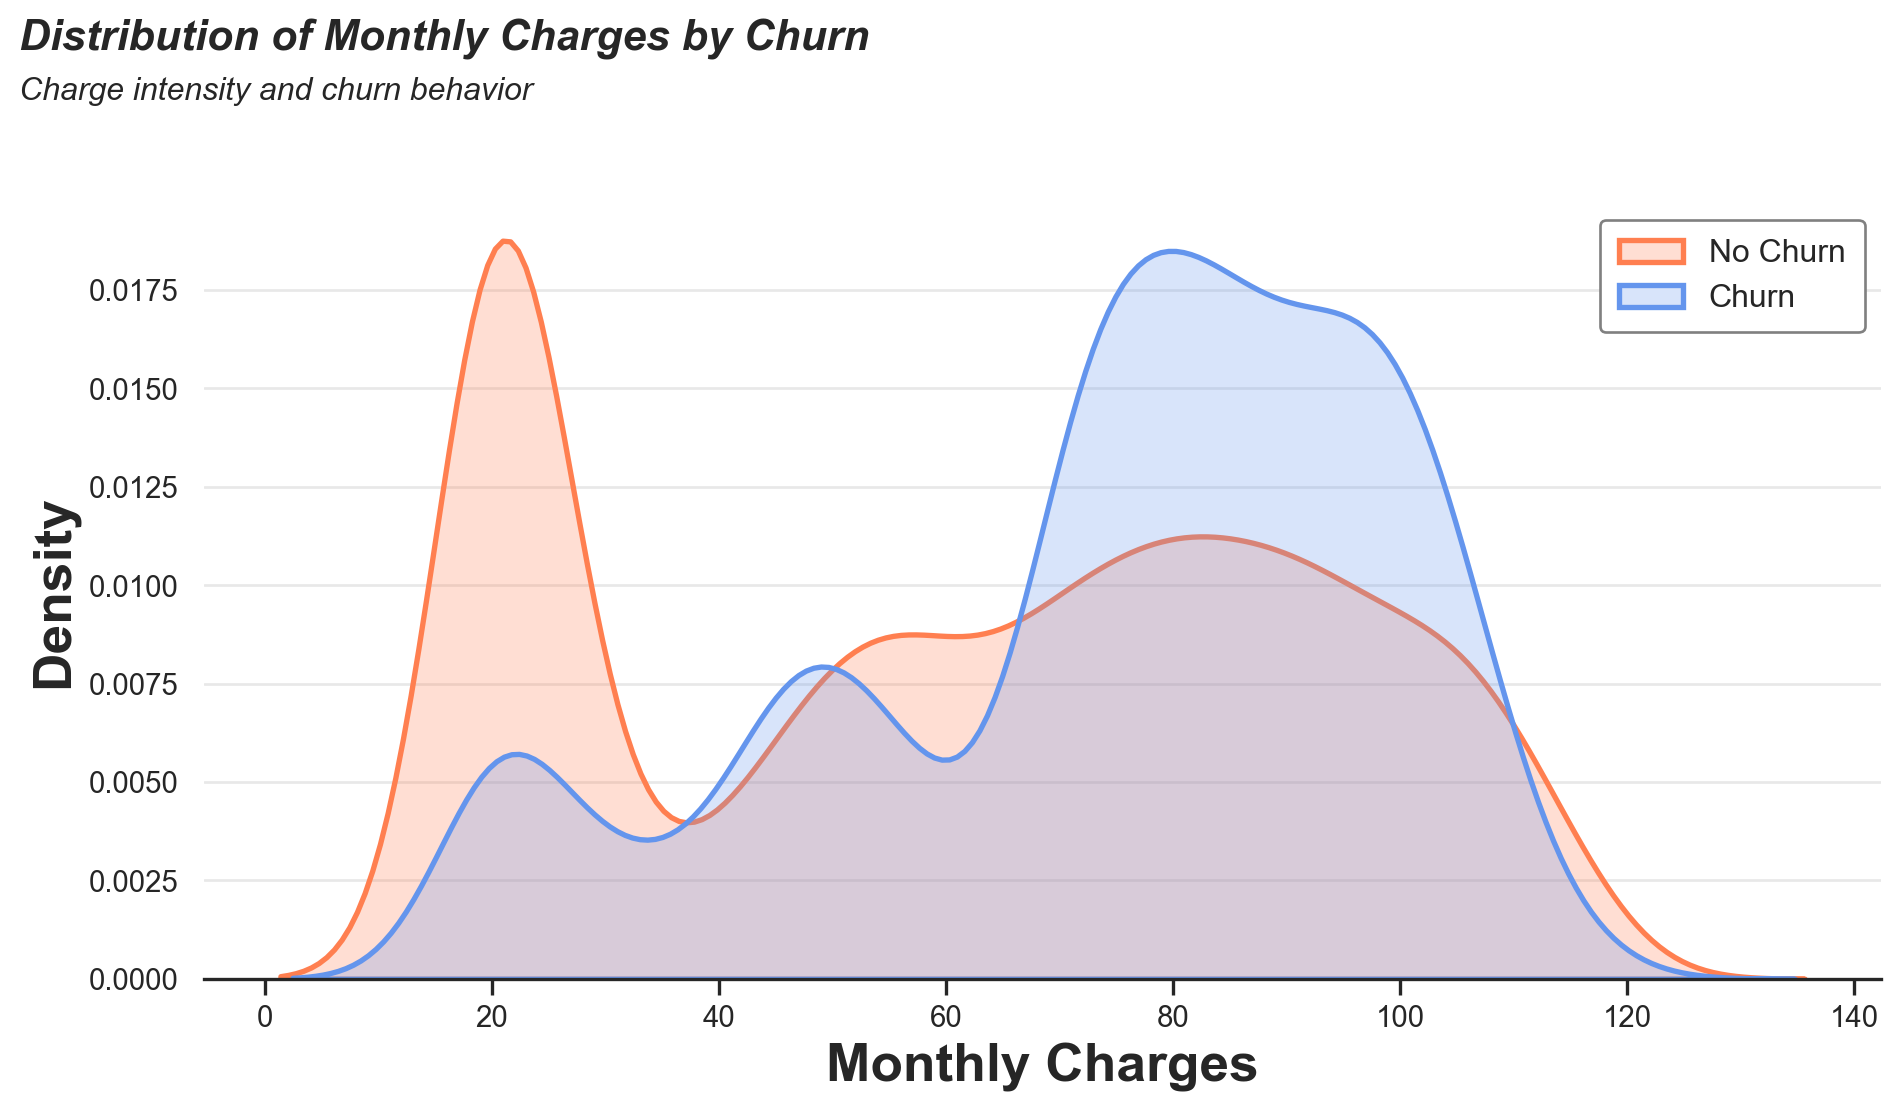


No Churn Distribution
  Skewness : -0.0268 (approximately symmetric)
  Kurtosis : -1.3552 (platykurtic)

Churn Distribution
  Skewness : -0.7294 (moderately skewed)
  Kurtosis : -0.3615 (platykurtic)

phik         = 0.3923
significance = 12.1535


In [33]:
def plot_churn_vs_monthly_charges(df: pd.DataFrame) -> None:
    """
    Plot KDE distribution of Monthly Charges segmented by churn
    and display skewness, kurtosis, and PhiK correlation.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.kdeplot(
        df[df["Churn"] == "No"]["MonthlyCharges"],
        ax=ax,
        color="coral",
        fill=True,
        linewidth=2,
        label="No Churn"
    )

    sns.kdeplot(
        df[df["Churn"] == "Yes"]["MonthlyCharges"],
        ax=ax,
        color="cornflowerblue",
        fill=True,
        linewidth=2,
        label="Churn"
    )

    ax.set_xlabel("Monthly Charges")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

    add_finance_header(
        fig,
        title="Distribution of Monthly Charges by Churn",
        subtitle="Charge intensity and churn behavior",
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

    def describe_distribution(series: pd.Series, label: str) -> None:
        skew = series.skew()
        kurt = series.kurtosis()

        if -0.5 <= skew <= 0.5:
            skew_desc = "approximately symmetric"
        elif -1 <= skew <= 1:
            skew_desc = "moderately skewed"
        else:
            skew_desc = "highly skewed"

        kurt_desc = (
            "leptokurtic" if kurt > 0
            else "platykurtic" if kurt < 0
            else "mesokurtic"
        )

        print(f"\n{label}")
        print(f"  Skewness : {skew:.4f} ({skew_desc})")
        print(f"  Kurtosis : {kurt:.4f} ({kurt_desc})")

    describe_distribution(
        df[df["Churn"] == "No"]["MonthlyCharges"],
        "No Churn Distribution"
    )

    describe_distribution(
        df[df["Churn"] == "Yes"]["MonthlyCharges"],
        "Churn Distribution"
    )

    # PhiK: encode target only for association computation
    temp = df[["Churn", "MonthlyCharges"]].copy()
    temp["Churn"] = temp["Churn"].map({"No": 0, "Yes": 1})

    x1, y1 = temp[["Churn", "MonthlyCharges"]].T.values

    print(f"\nphik         = {phik.phik_from_array(x1, y1):.4f}")
    print(f"significance = {phik.significance_from_array(x1, y1)[1]:.4f}")
    
plot_churn_vs_monthly_charges(telecom)    

**Insights:**
- Customers who churn are disproportionately concentrated in higher monthly charge ranges, indicating price sensitivity as a key driver of attrition.
- The churn distribution is more left-skewed, suggesting a heavier concentration of high-value customers exiting the service.
- Both churn and non-churn groups exhibit platykurtic behavior, indicating relatively stable distributions with limited extreme outliers.
- The Phik correlation (~0.39) indicates a moderate and statistically significant relationship, reinforcing that pricing plays an important — but not dominant — role in churn behavior.
- Unlike contract type (structural driver), monthly charges act as a **behavioral pressure variable**, influencing churn probability within segments.


<span style="color:steelblue; text-align: left">

### EDA Summary

</span>

The dataset presents a well-balanced gender distribution, with no observable differences in behavior across male and female customers. The population is predominantly composed of younger individuals, as only a small proportion corresponds to senior citizens. Relationship patterns indicate a consistent structure in the customer base: individuals without partners are highly unlikely to have dependents, while those with partners are more evenly split. These patterns remain stable across gender, suggesting that demographic variables have limited explanatory power in isolation.

From a lifecycle perspective, the tenure distribution reveals two distinct customer groups: a large concentration of customers with less than one year of service and another group with long-term relationships, typically around five to six years. This dual behavior is not random and is strongly influenced by contract structure. Customers under longer contracts tend to remain significantly longer, indicating that **contract duration acts as a structural retention mechanism**.

Contract type emerges as one of the most relevant variables in the dataset. The majority of customers are subscribed to month-to-month agreements, which provide flexibility but also expose the company to higher churn. In contrast, one-year and two-year contracts are associated with increased stability and longer tenure. This reinforces the idea that **customer commitment is a key driver of retention**.

Financial variables add another critical dimension to the analysis. Higher monthly charges are associated with increased churn probability, but this relationship is not isolated. The effect becomes more pronounced when combined with contract type. Customers who are both on flexible contracts and exposed to higher monthly costs represent the most vulnerable segment. In this context, **churn is best explained by the interaction between low commitment and high financial pressure**, rather than by either factor alone.

Statistical analysis using PhiK correlation supports these findings. Variables such as **Contract**, **tenure**, and **MonthlyCharges** show the strongest association with churn, while several service-related features (e.g., PhoneService, StreamingTV, StreamingMovies, MultipleLines) exhibit weak relationships and are likely to contribute less to predictive performance. This indicates that **behavioral and structural variables outperform service adoption features in explaining churn**.

Additionally, the dataset is imbalanced, with a clear majority of customers not churning. This has direct implications for modeling, as it may bias predictions toward the majority class if not properly handled. Finally, a small portion of the data contains inconsistencies or missing values, but given its limited size, it does not justify removal and can be retained without compromising the analysis.

Overall, the analysis indicates that **customer churn is a contextual phenomenon**, driven by the interplay between contractual flexibility and perceived cost burden, rather than by isolated demographic or service-related variables.


<span style="color:steelblue; text-align: left">

### Chi-Squared Test (χ²)
</span>

The Chi-Squared test is used to evaluate whether there is a statistically significant association between categorical variables and the target.

In this context, it serves as a validation step to quantify how strongly each categorical feature is associated with churn, based on observed versus expected frequencies.

Rather than discovering new relationships, this test confirms patterns already identified during the exploratory and PhiK correlation analysis.

In [34]:
from typing import Tuple, List

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import LabelEncoder


def prepare_feature_sets(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_cols: List[str] | None = None
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """
    Prepare a clean dataframe and return categorical and numerical feature lists.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_cols : list[str] | None, default=None
        Identifier columns to exclude from feature selection.

    Returns
    -------
    tuple
        Clean dataframe, categorical feature list, numerical feature list.
    """
    if id_cols is None:
        id_cols = ["customerID"]

    data = df.copy(deep=True).dropna(axis=0)

    categorical_features = data.select_dtypes(
        include=["category", "object"]
    ).columns.tolist()

    numerical_features = data.select_dtypes(
        exclude=["category", "object"]
    ).columns.tolist()

    for col in id_cols:
        if col in categorical_features:
            categorical_features.remove(col)
        if col in numerical_features:
            numerical_features.remove(col)

    if target_col in categorical_features:
        categorical_features.remove(target_col)

    if target_col in numerical_features:
        numerical_features.remove(target_col)

    return data, categorical_features, numerical_features


def encode_categorical_features(
    df: pd.DataFrame,
    categorical_features: List[str]
) -> pd.DataFrame:
    """
    Encode categorical features using LabelEncoder.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    categorical_features : list[str]
        Categorical columns to encode.

    Returns
    -------
    pd.DataFrame
        Dataframe with encoded categorical features.
    """
    data = df.copy(deep=True)
    encoder = LabelEncoder()

    for column in categorical_features:
        data[column] = encoder.fit_transform(data[column])

    return data


def plot_feature_selection_heatmap(
    scores_df: pd.DataFrame,
    score_col: str,
    title: str,
    subtitle: str,
    fmt: str = ".3f",
    figsize: tuple = (10, 6)
) -> None:
    """
    Plot a ranked feature selection heatmap using the project visual style.

    Parameters
    ----------
    scores_df : pd.DataFrame
        Dataframe containing feature scores.
    score_col : str
        Column name containing the score values.
    title : str
        Main chart title.
    subtitle : str
        Chart subtitle.
    fmt : str, default=".3f"
        Annotation number format.
    figsize : tuple, default=(10, 6)
        Figure size.
    """
    plot_df = scores_df.sort_values(by=score_col, ascending=False)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_df,
        annot=True,
        cmap=sns.light_palette("cornflowerblue", as_cmap=True),
        linewidths=0.4,
        fmt=fmt,
        cbar=True,
        ax=ax
    )

    add_finance_header(
        fig,
        title=title,
        subtitle=subtitle,
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.84)
    plt.show()


def plot_chi_squared_feature_selection(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_cols: List[str] | None = None
) -> pd.DataFrame:
    """
    Compute and plot Chi-Squared scores for categorical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_cols : list[str] | None, default=None
        Identifier columns to exclude.

    Returns
    -------
    pd.DataFrame
        Dataframe with Chi-Squared scores.
    """
    data, categorical_features, _ = prepare_feature_sets(
        df=df,
        target_col=target_col,
        id_cols=id_cols
    )

    encoded_data = encode_categorical_features(data, categorical_features)

    features = encoded_data.loc[:, categorical_features]
    target = encoded_data.loc[:, target_col]

    selector = SelectKBest(score_func=chi2, k="all")
    selector.fit(features, target)

    feature_scores = pd.DataFrame(
        data=selector.scores_,
        index=features.columns,
        columns=["Chi-Squared Score"]
    )

    plot_feature_selection_heatmap(
        scores_df=feature_scores,
        score_col="Chi-Squared Score",
        title="Chi-Squared Test (χ²)",
        subtitle="Statistical relevance of categorical features",
        fmt=".3f",
        figsize=(10, 6)
    )

    return feature_scores.sort_values(
        by="Chi-Squared Score",
        ascending=False
    )


def plot_anova_feature_selection(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_cols: List[str] | None = None
) -> pd.DataFrame:
    """
    Compute and plot ANOVA F-scores for numerical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_cols : list[str] | None, default=None
        Identifier columns to exclude.

    Returns
    -------
    pd.DataFrame
        Dataframe with ANOVA scores.
    """
    data, _, numerical_features = prepare_feature_sets(
        df=df,
        target_col=target_col,
        id_cols=id_cols
    )

    features = data.loc[:, numerical_features]
    target = data.loc[:, target_col]

    selector = SelectKBest(score_func=f_classif, k="all")
    selector.fit(features, target)

    feature_scores = pd.DataFrame(
        data=selector.scores_,
        index=features.columns,
        columns=["ANOVA Score"]
    )

    plot_feature_selection_heatmap(
        scores_df=feature_scores,
        score_col="ANOVA Score",
        title="ANOVA Test",
        subtitle="Statistical relevance of numerical features",
        fmt=".2f",
        figsize=(8, 4.8)
    )

    return feature_scores.sort_values(
        by="ANOVA Score",
        ascending=False
    )

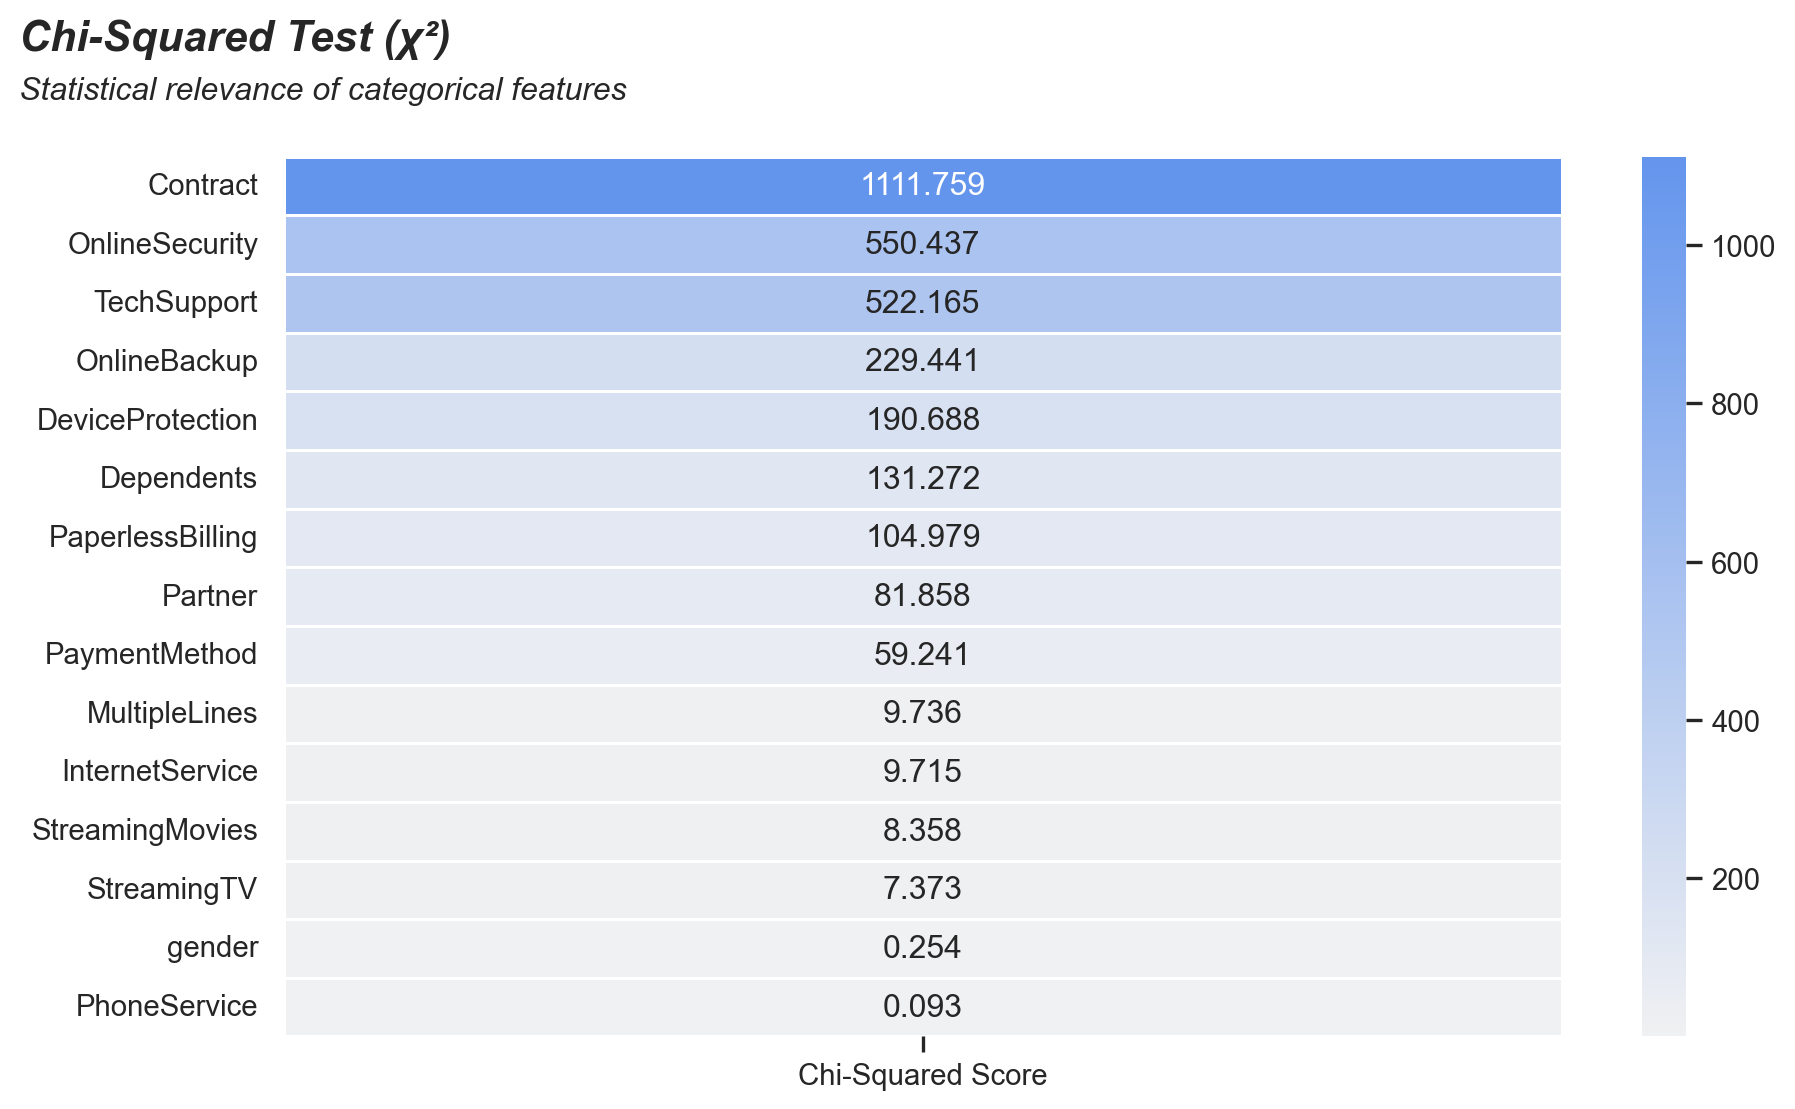

,Chi-Squared Score
Contract,1111.759054
OnlineSecurity,550.437364
TechSupport,522.164716
OnlineBackup,229.441123
DeviceProtection,190.688004
Dependents,131.271509
PaperlessBilling,104.979224
Partner,81.857769
PaymentMethod,59.240507
MultipleLines,9.735960


In [35]:
chi2_scores = plot_chi_squared_feature_selection(telecom)
chi2_scores

**Insights:**

Categorical features show a clear hierarchy of importance:

- **Contract** stands out as the most influential variable by a large margin, reinforcing its role as a primary driver of churn.
- **OnlineSecurity**, **TechSupport**, and **Dependents** also exhibit strong associations, indicating that service support and household structure impact retention.
- Features such as **PhoneService**, **gender**, **StreamingTV**, **StreamingMovies**, and **MultipleLines** show minimal association with churn and are likely to contribute little to predictive performance.

Overall, the test confirms that **structural and support-related variables are more relevant than basic service usage features**.

<span style="color:steelblue; text-align: left">

### ANOVA Test
</span>

ANOVA (Analysis of Variance) is used to assess whether numerical features present statistically significant differences in their means across churn groups.

In this case, it helps quantify how strongly numerical variables differentiate customers who churn from those who remain.

Similar to the Chi-Squared test, ANOVA acts as a validation layer rather than a discovery tool, reinforcing patterns previously observed in the data.

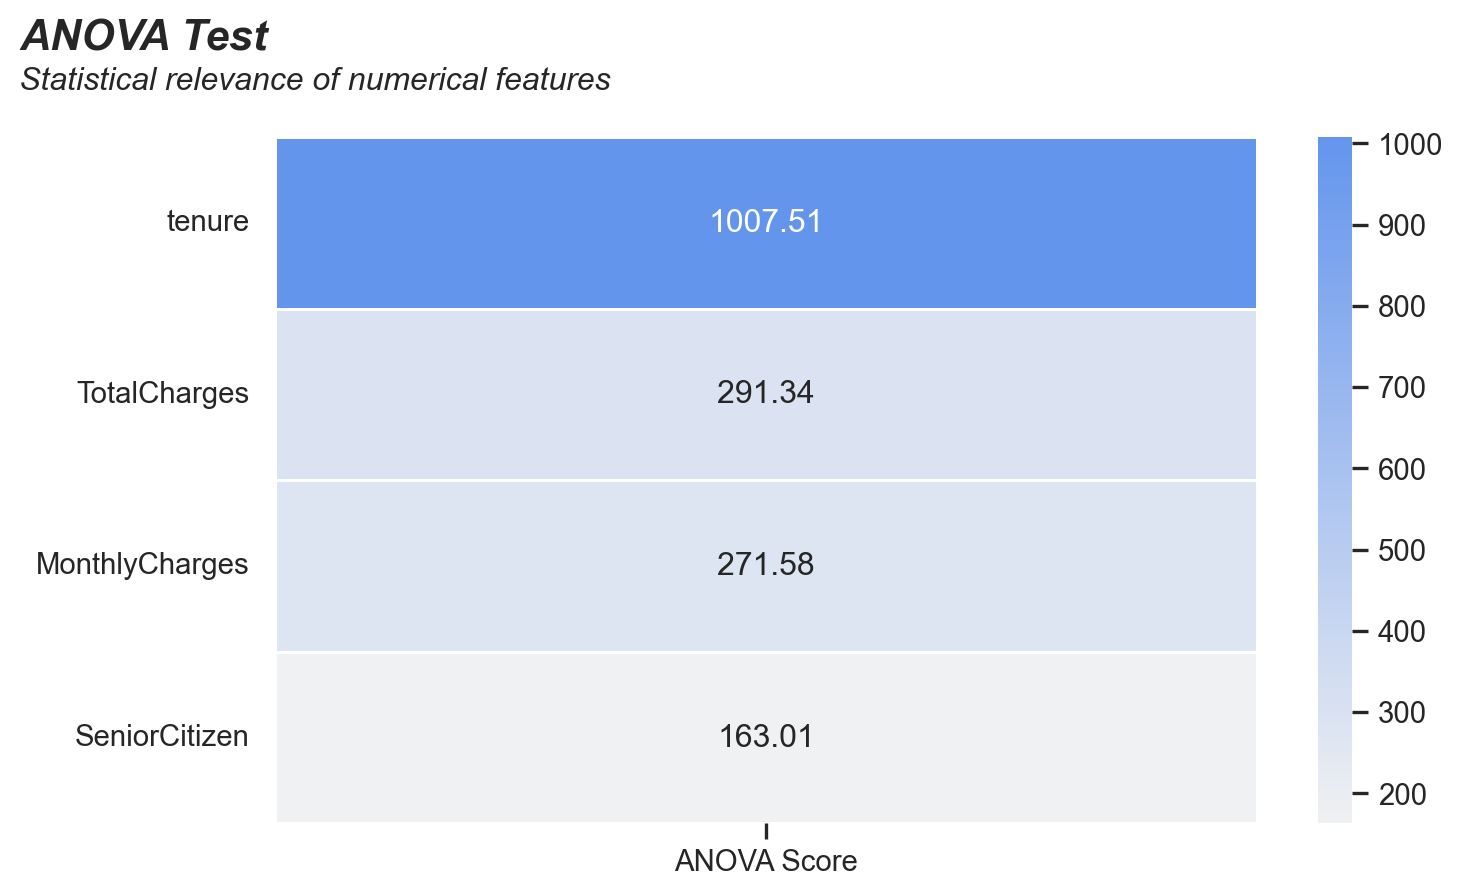

,ANOVA Score
tenure,1007.509431
TotalCharges,291.344862
MonthlyCharges,271.576990
SeniorCitizen,163.012426


In [36]:
anova_scores = plot_anova_feature_selection(telecom)
anova_scores

**Insights:**

- **tenure** is the most discriminative numerical variable, indicating that customer lifetime is a key factor in churn behavior.
- **TotalCharges** and **MonthlyCharges** also show strong statistical relevance, confirming that financial variables play a significant role.

However, given the known relationship:

> **TotalCharges ≈ MonthlyCharges × tenure**

there is clear multicollinearity between these variables.

This suggests that:
- Including all of them may introduce redundancy
- Feature engineering or selection strategies should be applied to avoid duplicated information

Overall, the results confirm that **customer lifetime and financial exposure are central to explaining churn**.

<span style="color:steelblue; text-align: left">

## Customer churn prediction - modeling
</span>

<span style="color:steelblue; text-align: left">

### Importing packages
</span>

In [ ]:
from __future__ import annotations

import gzip
import pickle
from json import dumps, loads
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import StratifiedKFold, train_test_split


def read_telecom_data(filepath: str = "./dataset/telecom.csv") -> pd.DataFrame:
    """
    Read the telecom churn dataset.

    Parameters
    ----------
    filepath : str, default="./dataset/telecom.csv"
        Path to the dataset.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.
    """
    return pd.read_csv(filepath)


def split_telecom_dataset(
    df: pd.DataFrame,
    target_col: str = "Churn",
    id_col: str = "customerID",
    test_size: float = 0.2,
    random_state: int = 42,
    drop_cols: list[str] | None = None
) -> dict[str, Any]:
    """
    Split the telecom dataset into train and test partitions.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, default="Churn"
        Target column name.
    id_col : str, default="customerID"
        Identifier column name.
    test_size : float, default=0.2
        Proportion of the dataset assigned to test set.
    random_state : int, default=42
        Random seed for reproducibility.
    drop_cols : list[str] | None, default=None
        Additional columns to drop before building X.

    Returns
    -------
    dict[str, Any]
        Dictionary containing split datasets and derived objects.
    """
    if drop_cols is None:
        drop_cols = []

    data = df.copy(deep=True)

    target = data[target_col].map({"No": 0, "Yes": 1}).values

    feature_drop_cols = [target_col, id_col] + drop_cols
    features = data.drop(columns=feature_drop_cols, errors="ignore")

    train_data, test_data = train_test_split(
        data,
        test_size=test_size,
        stratify=data[target_col],
        random_state=random_state
    )

    train_features = train_data.drop(
        columns=[target_col, id_col] + drop_cols,
        errors="ignore"
    )
    test_features = test_data.drop(
        columns=[target_col, id_col] + drop_cols,
        errors="ignore"
    )

    train_labels = train_data[target_col].map({"No": 0, "Yes": 1}).values
    test_labels = test_data[target_col].map({"No": 0, "Yes": 1}).values

    return {
        "data": data,
        "X": features,
        "y": target,
        "train_data": train_data,
        "test_data": test_data,
        "train_features": train_features,
        "test_features": test_features,
        "train_labels": train_labels,
        "test_labels": test_labels,
    }
def compute_class_ratio(labels: np.ndarray) -> float:
    """
    Compute negative-to-positive class ratio.

    Parameters
    ----------
    labels : np.ndarray
        Binary target array encoded as 0/1.

    Returns
    -------
    float
        Ratio of negatives to positives.
    """
    labels = np.asarray(labels)

    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)

    if n_pos == 0:
        raise ValueError("Positive class count is zero; ratio cannot be computed.")

    return float(n_neg) / float(n_pos)

def plot_target_distribution(
    df: pd.DataFrame,
    feature: str,
    title: str,
    subtitle: str,
    figsize: tuple[float, float] = (8, 6)
) -> None:
    """
    Plot target distribution as a pie chart.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    feature : str
        Column to plot.
    title : str
        Main chart title.
    subtitle : str
        Chart subtitle.
    figsize : tuple[float, float], default=(8, 6)
        Figure size.
    """
    distribution = df[feature].value_counts(normalize=True).sort_index() * 100
    labels = distribution.index.astype(str).tolist()
    colors = ["cornflowerblue", "coral"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.pie(
        distribution.values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        shadow=True,
        explode=(0.08, 0.08),
        colors=colors
    )

    add_finance_header(
        fig,
        title=title,
        subtitle=subtitle,
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()
    
def plot_target_distribution_split(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature: str,
    title: str,
    subtitle: str,
    figsize: tuple[float, float] = (12, 5)
) -> None:
    """
    Plot side-by-side pie charts for train and test target distributions.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training dataframe.
    test_df : pd.DataFrame
        Testing dataframe.
    feature : str
        Target column name.
    title : str
        Main chart title.
    subtitle : str
        Chart subtitle.
    figsize : tuple[float, float], default=(12, 5)
        Figure size.
    """
    colors = ["cornflowerblue", "coral"]

    train_dist = train_df[feature].value_counts(normalize=True).sort_index() * 100
    test_dist = test_df[feature].value_counts(normalize=True).sort_index() * 100

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].pie(
        train_dist.values,
        labels=train_dist.index.astype(str).tolist(),
        autopct="%1.1f%%",
        startangle=90,
        shadow=True,
        explode=(0.08, 0.08),
        colors=colors
    )
    axes[0].set_title("Train Dataset")

    axes[1].pie(
        test_dist.values,
        labels=test_dist.index.astype(str).tolist(),
        autopct="%1.1f%%",
        startangle=90,
        shadow=True,
        explode=(0.08, 0.08),
        colors=colors
    )
    axes[1].set_title("Test Dataset")

    add_finance_header(
        fig,
        title=title,
        subtitle=subtitle,
        #show_line=False
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.80)
    plt.show()

def compute_business_score(
    recall: float,
    precision: float,
    fit_time: float,
    score_time: float,
    w_recall: float = 0.7,
    w_precision: float = 0.3,
    w_time: float = 0.0,
    normalize_weights: bool = True,
    time_reference: float | None = None,
    epsilon: float = 1e-9
) -> float:
    """
    Compute a customizable business score combining predictive performance
    and computational cost.

    The score rewards recall and precision, while penalizing execution time.

    Parameters
    ----------
    recall : float
        Recall score.
    precision : float
        Precision score.
    fit_time : float
        Average model fitting time.
    score_time : float
        Average model scoring/inference time.
    w_recall : float, default=0.7
        Weight assigned to recall.
    w_precision : float, default=0.3
        Weight assigned to precision.
    w_time : float, default=0.0
        Weight assigned to computational cost. Use 0 if machine cost
        is not relevant for the project or client.
    normalize_weights : bool, default=True
        Whether to normalize the weights so they sum to 1.
    time_reference : float | None, default=None
        Reference time used to scale total time. If None, time is used
        directly. If provided, time penalty becomes total_time / time_reference.
    epsilon : float, default=1e-9
        Small constant to avoid division by zero.

    Returns
    -------
    float
        Business-oriented score.
    """
    total_time = fit_time + score_time

    if normalize_weights:
        weight_sum = w_recall + w_precision + w_time
        if weight_sum <= 0:
            raise ValueError("At least one weight must be greater than zero.")
        w_recall /= weight_sum
        w_precision /= weight_sum
        w_time /= weight_sum

    if w_time == 0:
        time_penalty = 0.0
    elif time_reference is not None:
        if time_reference <= 0:
            raise ValueError("time_reference must be greater than zero.")
        time_penalty = total_time / (time_reference + epsilon)
    else:
        time_penalty = total_time

    score = (
        (w_recall * recall) +
        (w_precision * precision) -
        (w_time * time_penalty)
    )

    return score    
    
'''def save_model_and_metrics(
    description: str,
    data_model: str,
    encoder: str,
    pipeline_obj: Any,
    scores: dict[str, np.ndarray],
    params: dict[str, Any] | None,
    metric_df: pd.DataFrame,
    metric_path: str = "./dataset/metric_dataframe.csv",
    model_dir: str = "./models/"
) -> pd.DataFrame:
    """
    Save model metrics and serialize the fitted pipeline.

    Parameters
    ----------
    description : str
        Experiment label.
    data_model : str
        Data/model description.
    encoder : str
        Preprocessing pipeline description.
    pipeline_obj : Any
        Trained pipeline object.
    scores : dict[str, np.ndarray]
        Cross-validation scores dictionary.
    params : dict[str, Any] | None
        Hyperparameter dictionary.
    metric_df : pd.DataFrame
        Metrics dataframe to update.
    metric_path : str, default="./dataset/metric_dataframe.csv"
        CSV output path for metrics.
    model_dir : str, default="./models/"
        Directory for serialized model output.

    Returns
    -------
    pd.DataFrame
        Updated metrics dataframe.
    """
    try:
        params_str = dumps(params, default=str) if params is not None else ""
    except Exception:
        params_str = ""

    business_weights = build_business_weight_config(
    w_recall=7,
    w_precision=3,
    w_time=0,
    time_reference=1.0
    )

    business_score = compute_business_score(
        recall=np.mean(scores['test_recall_macro']),
        precision=np.mean(scores['test_precision_macro']),
        fit_time=np.mean(scores['fit_time']),
        score_time=np.mean(scores['score_time']),
        w_recall=7,
        w_precision=3,
        w_time=0,
        time_reference=1.0
    )
    
    metric_df.loc[(description, data_model, encoder), :] = [
        np.mean(scores['train_roc_auc']),
        np.mean(scores['test_roc_auc']),
        np.mean(scores['train_balanced_accuracy']),
        np.mean(scores['test_balanced_accuracy']),
        np.mean(scores['train_recall_macro']),
        np.mean(scores['test_recall_macro']),
        np.mean(scores['train_precision_macro']),
        np.mean(scores['test_precision_macro']),
        np.mean(scores['train_f1_macro']),
        np.mean(scores['test_f1_macro']),
        params_str,
        np.mean(scores['fit_time']),
        np.mean(scores['score_time']),
        np.mean(scores['fit_time']) + np.mean(scores['score_time']),
        business_score,
        business_weights
]

    Path(metric_path).parent.mkdir(parents=True, exist_ok=True)
    metric_df.to_csv(metric_path, index=True)

    Path(model_dir).mkdir(parents=True, exist_ok=True)
    model_filename = f"{description}_{encoder.replace(' ', '')}.pkl.gz"
    model_path = Path(model_dir) / model_filename

    with gzip.open(model_path, "wb") as file:
        pickle.dump(pipeline_obj, file)

    return metric_df'''




def save_model_and_metrics(
    description: str,
    data_model: str,
    encoder: str,
    pipeline_obj: Any,
    scores: dict[str, np.ndarray],
    params: dict[str, Any] | None,
    metric_df: pd.DataFrame | None = None,
    metric_path: str = "./dataset/metric_dataframe.csv",
    model_dir: str = "./models/",
    overwrite_existing: bool = True,
) -> pd.DataFrame:
    """
    Save model metrics without deleting previous experiment records.

    Existing metrics are loaded from disk first, then only the current
    experiment row is inserted or updated. Manual deletion of the CSV is
    required to reset the experiment history.
    """
    index_cols = [
        "Estimator",
        "Optimization/Data model",
        "Pre-Process Pipeline",
    ]

    metric_cols = [
        "Train Roc auc",
        "Test Roc auc",
        "Train Balanced Accuracy",
        "Test Balanced Accuracy",
        "Train Recall",
        "Test Recall",
        "Train Precision",
        "Test Precision",
        "Train F1",
        "Test F1",
        "Parameters",
        "Fit Time",
        "Score Time",
        "Total Time",
        "Business Score",
        "Business Weights",
    ]

    metric_path_obj = Path(metric_path)
    metric_path_obj.parent.mkdir(parents=True, exist_ok=True)

    all_cols = index_cols + metric_cols

    if metric_path_obj.exists():
        metric_df = pd.read_csv(metric_path_obj)

    elif metric_df is None:
        metric_df = pd.DataFrame(columns=all_cols)

    else:
        metric_df = metric_df.copy()

        if isinstance(metric_df.index, pd.MultiIndex):
            metric_df = metric_df.reset_index()

    missing_index_cols = [
        col for col in index_cols
        if col not in metric_df.columns
    ]

    if missing_index_cols:
        raise ValueError(
            "metric_dataframe is missing identity columns: "
            f"{missing_index_cols}"
        )

    for col in all_cols:
        if col not in metric_df.columns:
            metric_df[col] = np.nan

    try:
        params_str = dumps(params, default=str) if params is not None else ""
    except Exception:
        params_str = ""

    business_weights = build_business_weight_config(
        w_recall=7,
        w_precision=3,
        w_time=0,
        time_reference=1.0,
    )

    fit_time = float(np.mean(scores["fit_time"]))
    score_time = float(np.mean(scores["score_time"]))
    total_time = fit_time + score_time

    business_score = compute_business_score(
        recall=np.mean(scores["test_recall_macro"]),
        precision=np.mean(scores["test_precision_macro"]),
        fit_time=fit_time,
        score_time=score_time,
        w_recall=7,
        w_precision=3,
        w_time=0,
        time_reference=1.0,
    )

    row_identity = {
        "Estimator": description,
        "Optimization/Data model": data_model,
        "Pre-Process Pipeline": encoder,
    }

    duplicate_mask = (
        (metric_df["Estimator"] == row_identity["Estimator"])
        & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
        & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
    )

    if duplicate_mask.any() and not overwrite_existing:
        suffix = 1
        row_identity["Pre-Process Pipeline"] = f"{encoder} | run={suffix}"

        duplicate_mask = (
            (metric_df["Estimator"] == row_identity["Estimator"])
            & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
            & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
        )

        while duplicate_mask.any():
            suffix += 1
            row_identity["Pre-Process Pipeline"] = f"{encoder} | run={suffix}"
            duplicate_mask = (
                (metric_df["Estimator"] == row_identity["Estimator"])
                & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
                & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
            )

    values_to_save = {
        **row_identity,
        "Train Roc auc": np.mean(scores["train_roc_auc"]),
        "Test Roc auc": np.mean(scores["test_roc_auc"]),
        "Train Balanced Accuracy": np.mean(scores["train_balanced_accuracy"]),
        "Test Balanced Accuracy": np.mean(scores["test_balanced_accuracy"]),
        "Train Recall": np.mean(scores["train_recall_macro"]),
        "Test Recall": np.mean(scores["test_recall_macro"]),
        "Train Precision": np.mean(scores["train_precision_macro"]),
        "Test Precision": np.mean(scores["test_precision_macro"]),
        "Train F1": np.mean(scores["train_f1_macro"]),
        "Test F1": np.mean(scores["test_f1_macro"]),
        "Parameters": params_str,
        "Fit Time": fit_time,
        "Score Time": score_time,
        "Total Time": total_time,
        "Business Score": business_score,
        "Business Weights": business_weights,
    }

    if duplicate_mask.any():
        metric_df = metric_df.loc[~duplicate_mask].copy()

    new_row = pd.DataFrame([values_to_save])

    if metric_df.empty:
        metric_df = new_row
    else:
        metric_df = pd.concat(
            [metric_df, new_row],
            ignore_index=True,
        )
    metric_df = metric_df[all_cols]
    metric_df.sort_values(index_cols, inplace=True, ignore_index=True)
    metric_df.to_csv(metric_path_obj, index=False)

    Path(model_dir).mkdir(parents=True, exist_ok=True)

    safe_encoder = (
        str(row_identity["Pre-Process Pipeline"])
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace("|", "-")
        .replace(":", "-")
    )

    model_filename = f"{description}_{data_model}_{safe_encoder}.pkl.gz"
    model_path = Path(model_dir) / model_filename

    with gzip.open(model_path, "wb") as file:
        pickle.dump(pipeline_obj, file)

    return metric_df

def build_business_weight_config(
    w_recall: float,
    w_precision: float,
    w_time: float,
    time_reference: float | None
) -> str:
    """
    Build a serialized representation of the business score weights.

    Parameters
    ----------
    w_recall : float
        Weight assigned to recall.
    w_precision : float
        Weight assigned to precision.
    w_time : float
        Weight assigned to computational cost.
    time_reference : float | None
        Reference time used for time penalty scaling.

    Returns
    -------
    str
        JSON string with weight configuration.
    """
    config = {
        "w_recall": w_recall,
        "w_precision": w_precision,
        "w_time": w_time,
        "time_reference": time_reference
    }
    return dumps(config)

<span style="color:steelblue; text-align: left">

### Metrics
</span>

Model evaluation will be based on **balanced accuracy, recall, precision, F1-score, and ROC AUC**. Since churn prediction is an imbalanced classification problem, relying on a single metric would be insufficient and potentially misleading.

The primary optimization target in this project is **macro recall**. This choice reflects the business objective of improving detection of churn cases without allowing the majority class to dominate the optimization process. In churn prediction, false negatives (missed churners) are more costly than false positives, since failing to act leads to direct revenue loss.

In multiclass or imbalanced settings, averaging strategies matter. In this project, the focus is on **macro averaging**, which computes the metric independently for each class and then takes the unweighted mean. This ensures that both churn and non-churn classes receive equal importance during evaluation.

**Balanced accuracy** measures classification performance while correcting for class imbalance. Unlike standard accuracy, it is less biased toward the majority class.

**Recall** measures how many true churn cases are correctly identified. In churn prediction, this is particularly relevant because false negatives mean failing to identify customers at risk of leaving.

**Precision** measures how many predicted churn cases are actually churners. It becomes important when false positives generate unnecessary retention costs.

**F1-score** summarizes the trade-off between precision and recall through their harmonic mean:

$$
F1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}
$$

**ROC AUC** evaluates the model’s ability to discriminate between churn and non-churn across all classification thresholds. It is useful as a threshold-independent ranking metric, although it should not be interpreted in isolation.

Taken together, these metrics provide a more robust view of model performance. The final comparison will therefore consider both discrimination ability and class-sensitive predictive behavior, with special emphasis on **macro recall**.

The modeling stage begins by defining a class-sensitive evaluation framework and a leakage-safe train/test split. Because churn prediction is an imbalanced classification problem, model comparison will not rely on a single metric. Instead, multiple complementary metrics are tracked, with special emphasis on macro recall as the main optimization target.

After splitting the dataset using stratified sampling, all preprocessing and feature transformations are learned exclusively from the training data. This ensures a fair evaluation setup and preserves the integrity of downstream model selection. All preprocessing steps are embedded inside the pipeline to prevent data leakage during cross-validation.

In [ ]:

new_metrics = True

# 6-fold CV
kfolds = StratifiedKFold(n_splits = 6, shuffle=True, random_state = RANDOM_SEED)

# Reading/Creating metric to save all metrics
try:
    if new_metrics:
        metric_dataframe = pd.DataFrame(columns=[
            'Estimator',
            'Optimization/Data model',
            'Pre-Process Pipeline',
            'Train Roc auc',
            'Test Roc auc',
            'Train Balanced Accuracy',
            'Test Balanced Accuracy',
            'Train Recall',
            'Test Recall',
            'Train Precision',
            'Test Precision',
            'Train F1',
            'Test F1',
            'Parameters',
            'Fit Time',
            'Score Time',
            'Total Time',
            'Business Score',
            'Business Weights'
        ])
    else:
        metric_dataframe = pd.read_csv('./dataset/metric_dataframe.csv')

except:
    metric_dataframe = pd.DataFrame(columns=[
        'Estimator',
        'Optimization/Data model',
        'Pre-Process Pipeline',
        'Train Roc auc',
        'Test Roc auc',
        'Train Balanced Accuracy',
        'Test Balanced Accuracy',
        'Train Recall',
        'Test Recall',
        'Train Precision',
        'Test Precision',
        'Train F1',
        'Test F1',
        'Parameters',
        'Fit Time',
        'Score Time',
        'Total Time',
        'Business Score',
        'Business Weights'
    ])

metric_dataframe = metric_dataframe.reset_index() if isinstance(metric_dataframe.index, pd.MultiIndex) else metric_dataframe

# Initializing variables
pipe_model          = []

models_list         = []
head_list           = []
estimators          = []

linear_estimators   = []
essemble_estimators = []
tree_estimators     = []
neural_estimators   = []
XGBboost_estimators = []
lightgbm_estimators = []

<span style="color:steelblue; text-align: left">

### Split Dataset
</span>

The dataset is split into training and test partitions **before any preprocessing step**. This is a necessary precaution to prevent **data leakage**, which occurs when information from the full dataset influences transformations learned during training.

If preprocessing is applied before the split, statistics such as means, variances, category mappings, or encoding rules may inadvertently incorporate information from the test set. This leads to overly optimistic evaluation results and compromises the validity of the modeling process.

By splitting the data first, all preprocessing operations are learned exclusively from the training set and then applied to unseen data. This preserves the integrity of model evaluation and better reflects real-world deployment conditions.

In this project, the split is also **stratified by churn**, ensuring that the class distribution remains stable across training and test sets. This is especially important in imbalanced classification problems, where distributional distortions could bias both optimization and evaluation.

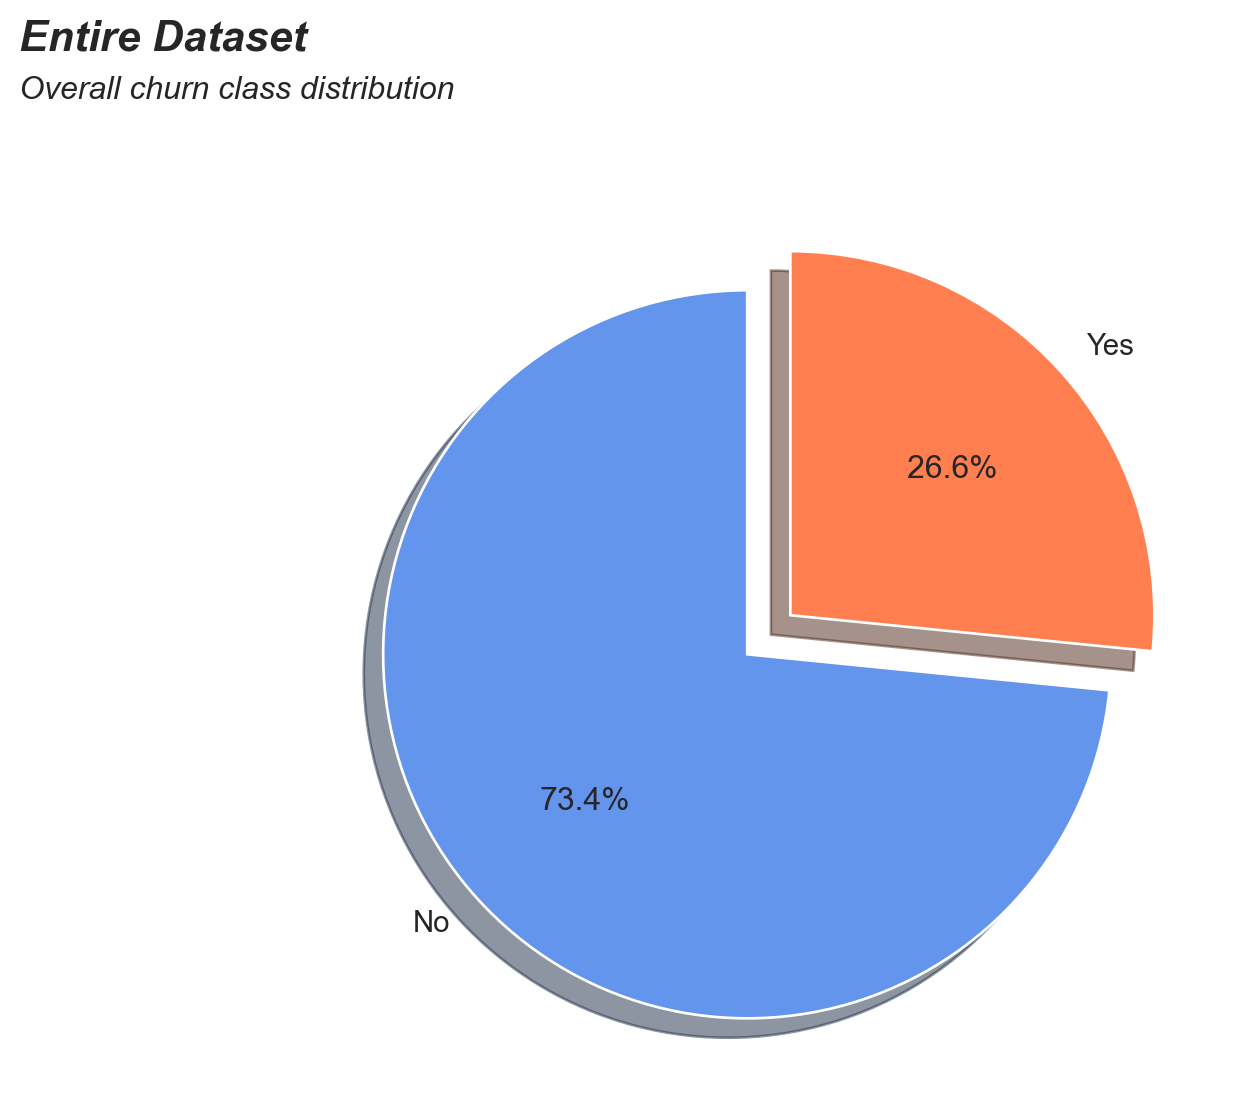

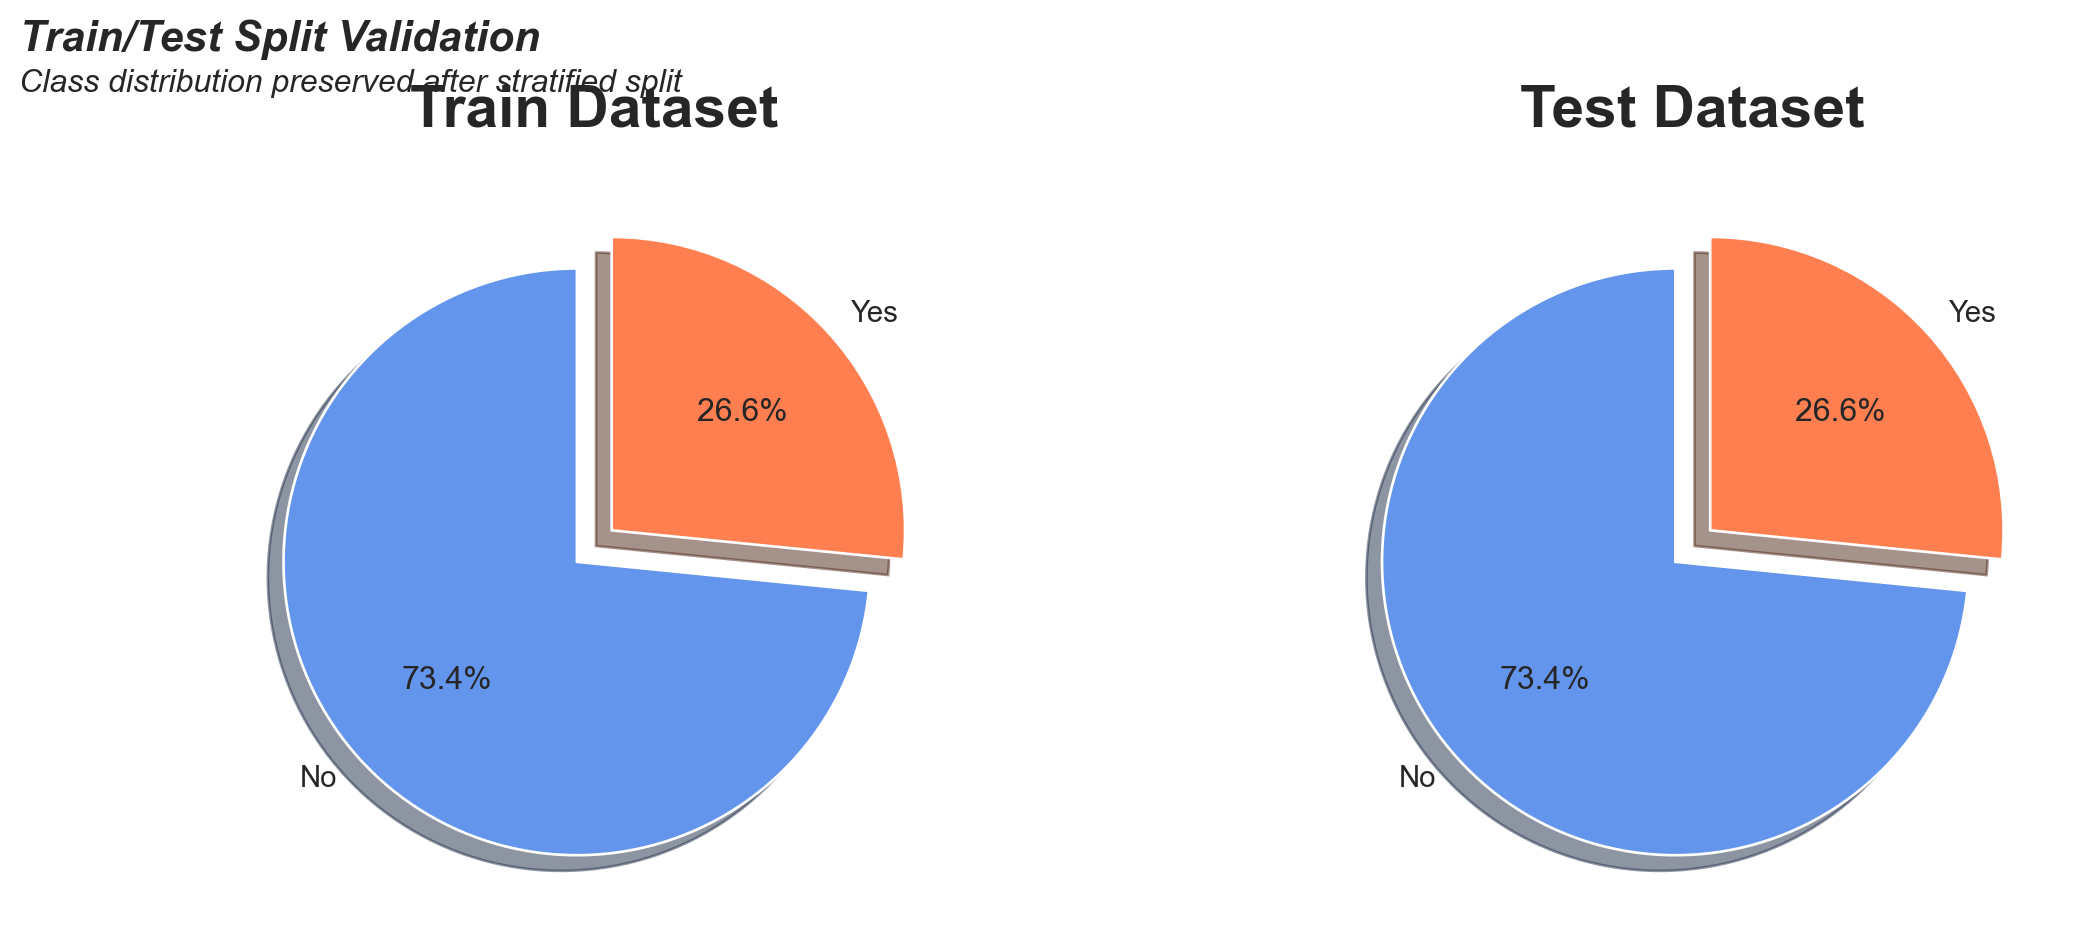

In [39]:
split_data = split_telecom_dataset(
    df=telecom,
    target_col="Churn",
    id_col="customerID",
    test_size=0.2,
    random_state=42
)

ratio_train = compute_class_ratio(split_data["train_labels"])
ratio_test = compute_class_ratio(split_data["test_labels"])

plot_target_distribution(
    df=telecom,
    feature="Churn",
    title="Entire Dataset",
    subtitle="Overall churn class distribution"
)

plot_target_distribution_split(
    train_df=split_data["train_data"],
    test_df=split_data["test_data"],
    feature="Churn",
    title="Train/Test Split Validation",
    subtitle="Class distribution preserved after stratified split"
)


train_data = split_data["train_data"]
test_data = split_data["test_data"]
train_features = split_data["train_features"]
test_features = split_data["test_features"]
train_labels = split_data["train_labels"]
test_labels = split_data["test_labels"]

<span style="color:steelblue; text-align: left">

### Baseline Model
</span>

The first modeling step uses the original imbalanced dataset without any resampling strategy. This provides a baseline reference against which oversampling, undersampling, and hyperparameter optimization can later be compared.

A **Logistic Regression** model is adopted as the initial benchmark because it is simple, interpretable, and computationally efficient. Although more complex models may achieve better predictive performance, a linear baseline helps quantify the incremental value of more advanced modeling choices.

At this stage, the preprocessing pipeline applies ordinal encoding to categorical variables, while numerical variables are passed through unchanged. Model performance is evaluated through stratified cross-validation using the previously defined class-sensitive metrics.

In [40]:
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import category_encoders


def get_classification_scoring() -> dict:
    """
    Build the scoring dictionary used in cross-validation.

    Returns
    -------
    dict
        Dictionary of sklearn scorers.
    """
    return {
        "roc_auc": make_scorer(roc_auc_score, average="macro"),
        "precision_macro": make_scorer(precision_score, average="macro"),
        "recall_macro": make_scorer(recall_score, average="macro"),
        "f1_macro": make_scorer(f1_score, average="macro"),
        "balanced_accuracy": make_scorer(balanced_accuracy_score),
    }


def build_baseline_preprocessor() -> ColumnTransformer:
    """
    Build the preprocessing pipeline for the baseline model.

    Returns
    -------
    ColumnTransformer
        Preprocessing transformer.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("encoder", category_encoders.OrdinalEncoder())
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, selector(dtype_include=object)),
        ],
        remainder="passthrough"
    )

    return preprocessor


def run_baseline_logistic_regression(
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    cv,
) -> tuple[Pipeline, dict, Pipeline]:
    preprocessor = build_baseline_preprocessor()

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    )

    scoring = get_classification_scoring()

    scores = cross_validate(
        model,
        train_features,
        train_labels,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        return_estimator=True,
        n_jobs=-1,
        verbose=2
    )

    best_idx = int(np.argmax(scores["test_recall_macro"]))
    best_estimator = scores["estimator"][best_idx]

    return model, scores, best_estimator

In [41]:
baseline_model, baseline_scores, best_baseline_estimator = run_baseline_logistic_regression(
    train_features=split_data["train_features"],
    train_labels=split_data["train_labels"],
    cv=kfolds
)

display(baseline_model)

metric_dataframe = save_model_and_metrics(
    description="LogisticRegression",
    data_model="Baseline",
    encoder="OrdinalEncoder",
    pipeline_obj=best_baseline_estimator,
    scores=baseline_scores,
    params={"max_iter": 1000},
    metric_df=metric_dataframe
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    1.8s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    1.8s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [42]:
metric_dataframe

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
0,ExtraTreeClassifier,Baseline,OrdinalEncoder,0.998054,0.656897,0.998054,0.656897,0.998054,0.656897,0.999122,0.651943,0.998586,0.654087,"{""random_state"": 738}",0.064922,0.028187,0.093108,0.655411,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
1,ExtraTreeClassifier,Recall Macro Opt Balanced,OneHotEncoder PowerTransformer RobustScaler SelectKBest 9 | thr=0.500,0.823525,0.811231,0.755401,0.736983,0.755401,0.736983,0.704921,0.693027,0.708759,0.698715,"{""criterion"": ""gini"", ""max_depth"": 6, ""min_samples_split"": 2, ""min_samples_leaf"": 40, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",1.818731,0.044685,1.863416,0.723796,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
2,ExtraTreeClassifier,Recall Macro Opt Over-sampling,CountFrequencyEncoder QuantileTransformerN RobustScaler SequentialFeatureSelector 10 SMOTE | thr=0.500,0.814849,0.803278,0.755496,0.736591,0.755496,0.736591,0.709056,0.694964,0.716641,0.702182,"{""criterion"": ""entropy"", ""max_depth"": 33, ""min_samples_split"": 7, ""min_samples_leaf"": 91, ""random_state"": 738, ""threshold"": 0.5}",4.053116,0.044600,4.097716,0.724103,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
3,HistGradientBoostingClassifier,Baseline,OrdinalEncoder,0.845648,0.708138,0.845648,0.708138,0.845648,0.708138,0.873548,0.736257,0.858063,0.719098,"{""random_state"": 738}",0.471746,0.049818,0.521564,0.716574,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
4,HistGradientBoostingClassifier,Recall Macro Opt Balanced + Threshold tuning,SumEncoder Normalizer MaxAbsScaler SequentialFeatureSelector 9 | thr=0.240,0.826545,0.816031,0.748111,0.747725,0.748111,0.747725,0.701150,0.697830,0.706784,0.699806,"{""threshold"": 0.24}",572.129620,0.054738,572.184358,0.732756,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
5,LGBMClassifier,Baseline,OrdinalEncoder,0.852807,0.707619,0.852807,0.707619,0.852807,0.707619,0.879605,0.736778,0.864804,0.718720,"{""random_state"": 738}",5.991888,0.050646,6.042534,0.716367,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
6,LGBMClassifier,Recall Macro Opt Balanced,CatBoostEncoder PowerTransformer RFE 13 | thr=0.500,0.838865,0.830506,0.765584,0.756138,0.765584,0.756138,0.712469,0.702669,0.716161,0.701618,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",2.261283,0.062490,2.323773,0.740097,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
7,LGBMClassifier,Recall Macro Opt Over-sampling,CatBoostEncoder PowerTransformer RFE 13 SMOTE | thr=0.500,0.839134,0.828063,0.767111,0.751390,0.767111,0.751390,0.715092,0.699544,0.720580,0.699601,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""threshold"": 0.5}",2.427090,0.069897,2.496987,0.735836,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""t

**Insights — Baseline Model Behavior**
- The Logistic Regression baseline model demonstrates stable generalization, as evidenced by the close alignment between training and test scores across all evaluated metrics, indicating no significant overfitting or underfitting.
- Despite the imbalanced nature of the dataset, the model maintains consistent performance across classes when evaluated using macro-averaged metrics, confirming that the evaluation strategy is appropriate.
- Although stable, the model performance remains moderate, suggesting that improvements are expected through more advanced preprocessing, feature engineering, resampling strategies, and model selection.

<span style="color:steelblue; text-align: left">

### Baseline's Confusion Matrix
</span>

Here we'll introduce `confusion matrix` because we'll messuare our model with this tool as weel. `Confusion matrix` is a table that summarizes the performance of a machine learning model for a binary classification task. It shows the number of true positive (TP), true negative (TN), false positive (FP), and false negative (FN) predictions made by the model on a set of test data.

Here's an example confusion matrix for a binary classification problem with two classes (positive and negative):

<center>

|               |`Positive (predicted)`	| `Negative (predicted)`
|:---------------|:-----------------------|:------
|`Positive (true)`	| True positives (TP)	| <code style='color:pink'>False negatives (FN)</code>
|`Negative (true)`	|<code style='color:pink'>False positives (FP)</code>	| True negatives (TN)

</center>

True positives (TP) are the number of positive examples that are correctly classified as positive by the model.
False positives (FP) are the number of negative examples that are incorrectly classified as positive by the model.
True negatives (TN) are the number of negative examples that are correctly classified as negative by the model.
False negatives (FN) are the number of positive examples that are incorrectly classified as negative by the model.
The confusion matrix is useful for evaluating the performance of a binary classification model because it provides a more detailed picture of the model's performance than just a single metric like accuracy. From the confusion matrix, we can calculate other metrics such as precision, recall, and F1 score, which can be useful for different applications.

For example, precision measures the proportion of positive predictions that are correct, while recall measures the proportion of positive examples that are correctly identified by the model. The F1 score is the harmonic mean of precision and recall, which balances the trade-off between these two metrics. 

So, the confusion matrix is a useful tool for understanding the performance of a machine learning model and diagnosing any errors or biases that it may have. `We'll looking for low numbers in bottom left and upper right quadrant (in pink above). Lowest is better`.

`We want to get as many observations as we can (from the test set) in the upper-left and bottom-right quadrants since those are observations that our model got right`. The other quadrants are model mistakes.


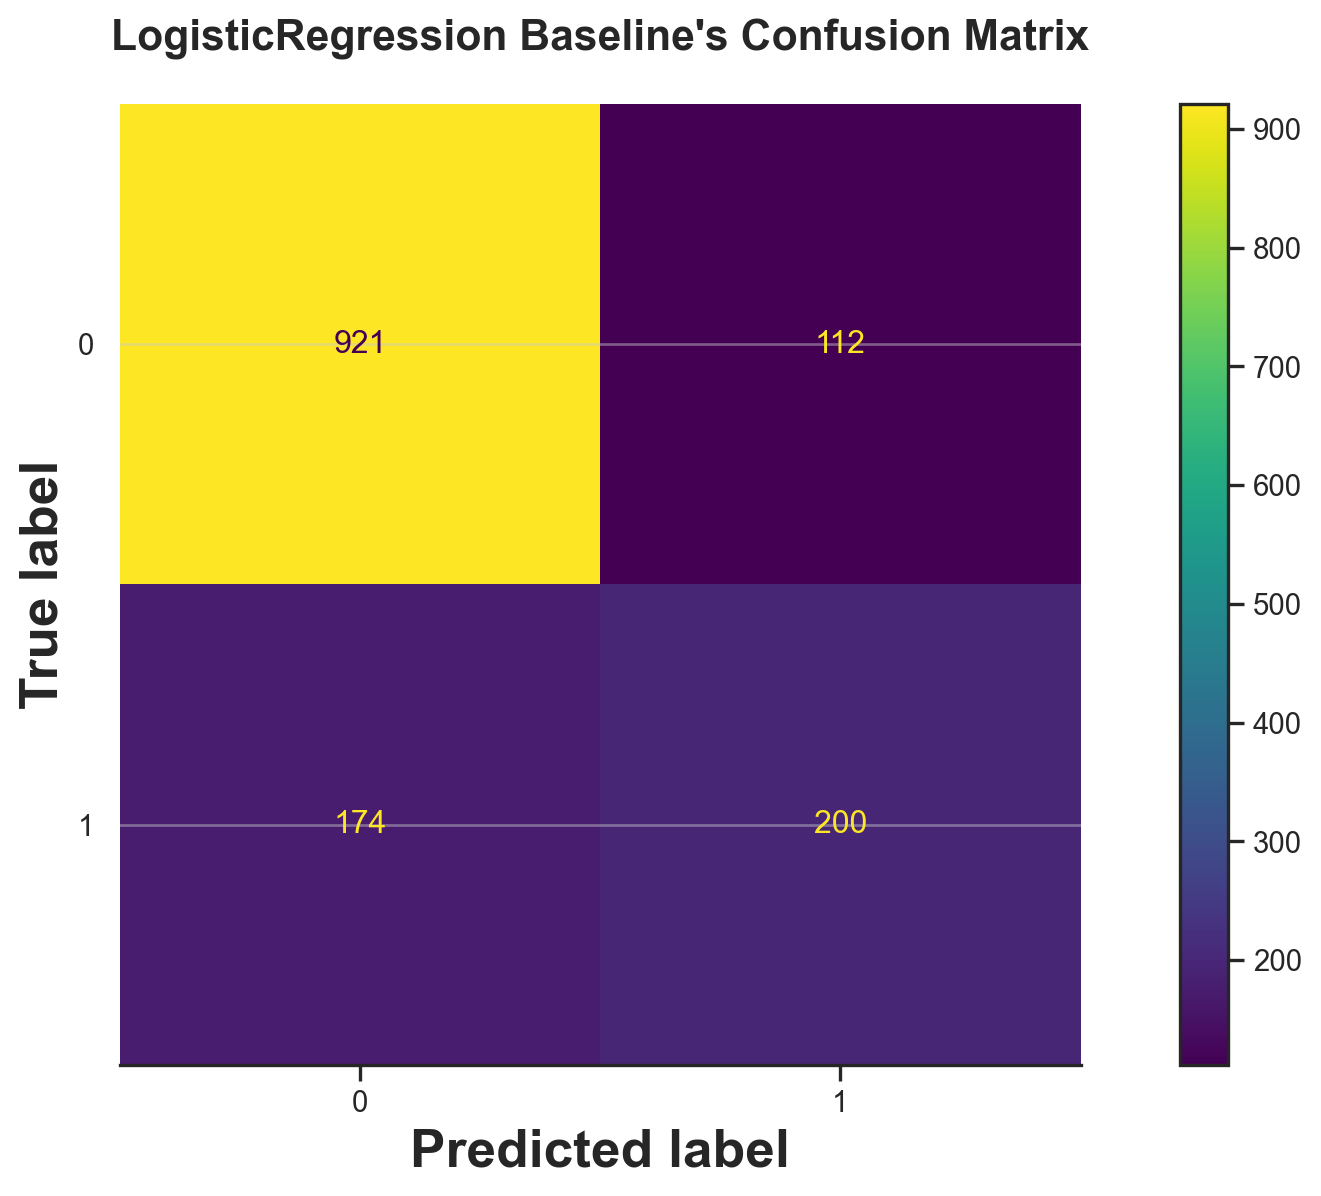

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

baseline_model.fit(train_features, train_labels)
y_pred = baseline_model.predict(test_features)

disp = ConfusionMatrixDisplay.from_predictions(test_labels, y_pred)
plt.title("LogisticRegression Baseline's Confusion Matrix", fontsize=16)

plt.show()


**Insights — Confusion Matrix**
- The confusion matrix indicates the presence of false negatives, meaning that a portion of churn customers is incorrectly classified as non-churn.
- From a business perspective, false negatives represent missed retention opportunities, reinforcing the importance of optimizing recall for the churn class.
- This behavior supports the decision to prioritize recall as the main optimization metric in subsequent modeling steps.

<span style="color:steelblue; text-align: left">

### Decision Function
</span>

In machine learning, the decision function is a function that takes in a set of features and outputs a decision boundary that separates different classes in a classification problem. It is often used in binary classification tasks, where there are two possible classes (e.g., "positive" or "negative").

The decision function works by assigning a score to each instance in the input data, based on its distance from the decision boundary. The sign of the score indicates which side of the boundary the instance falls on, and can be used to predict the class label.

For example, in a linear support vector machine (SVM) model, the decision function is a linear equation that takes in a set of features and outputs a scalar value:

```Python
y = w_1 * x_1 + w_2 * x_2 + ... + w_n * x_n + b
```

where:
- `x_1, x_2, ..., x_n` are the input features, 
- `w_1, w_2, ..., w_n` are the weights assigned to each feature, 
- and `b` is the bias term. 

The output y is the score assigned to the instance, and its sign indicates which side of the decision boundary it falls on.

In other models, such as logistic regression or decision trees, the decision function may have a different form or structure, but the basic idea is the same: to assign scores or probabilities to each instance based on its features, and use those scores to predict the class label.

The decision function can be useful for understanding how a classification model works and diagnosing any errors or biases that it may have. By visualizing the decision boundary or analyzing the scores assigned to different instances, we can gain insights into how the model is making its predictions and which features are most important for the classification task.

To produce a binary response, classifiers output a real-valued score that is thresholded. For example, logistic regression outputs a probability (a value between 0.0 and 1.0); and observations with a score equal to or higher than 0.5 produce a positive binary output (many other models use the 0.5 threshold by default).

However, using the default 0.5 threshold is suboptimal. Thus, we'll look forward the best threshold from our binary classifier as shown below.

```Python
# A way-out to customize the decision function.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred[:, 1] >= 0.46)
```
Changing the threshold of our model will change the values in the confusion matrix. In the prediction, we used the predict function, which returns a binary response (i.e., uses 0.5 as threshold); however, we can use the `predict_proba function` to get the raw probability and use a custom threshold:

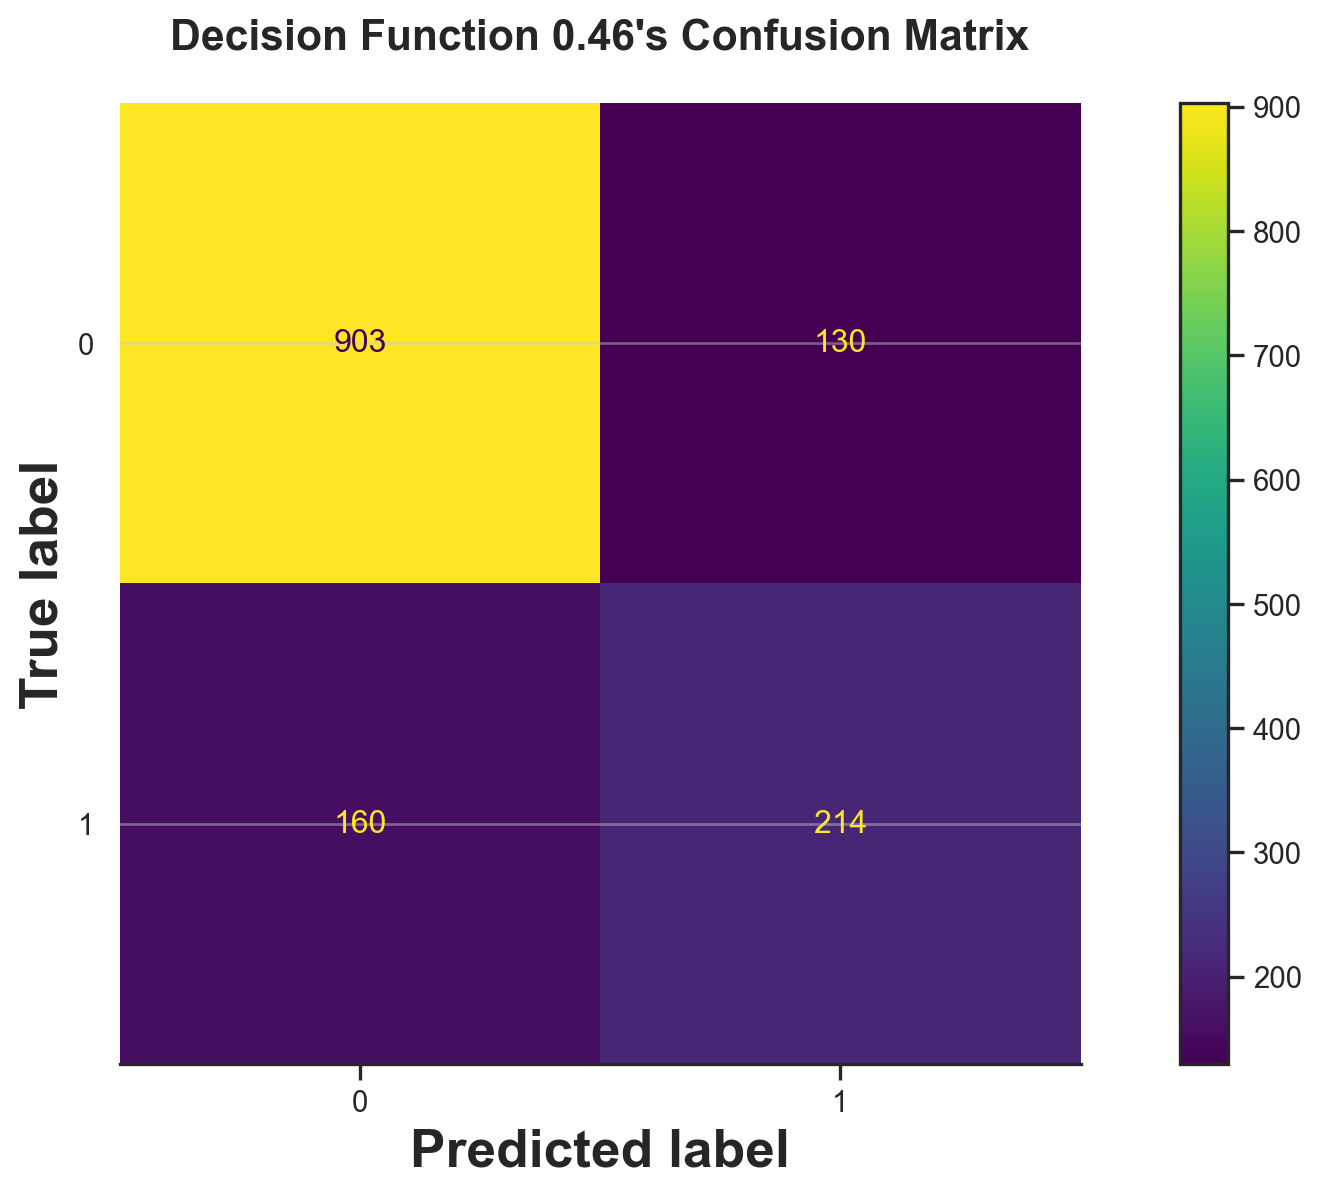

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = baseline_model.predict_proba(test_features)

ConfusionMatrixDisplay.from_predictions(test_labels, y_pred[:, 1] >= 0.46)
plt.title("Decision Function 0.46's Confusion Matrix", fontsize=16)

plt.show()

**Insights — Threshold Optimization**
- Model performance varies significantly across different threshold values, confirming that classification results are strongly dependent on threshold selection.
- Lower threshold values (approximately between 0.20 and 0.25) increase recall and improve the model's ability to identify churners, at the expense of higher false positive rates.
- Higher threshold values (approximately between 0.40 and 0.45) improve precision and F1 score, reducing false positives while sacrificing recall.
- The optimal threshold is not universal and should be selected according to the specific trade-offs required by the business context.

TaDá!

<span style="color:steelblue; text-align: left">

#### Running experiments with Decision Function
</span>

We’ll obtain the precision, recall, and other statistics along several threshold values to better understand how the threshold affects them.

In [45]:
from tqdm import tqdm 

def highlight_greaterthan(s, threshold, column):
    is_max = pd.Series(data=False, index=s.index)
    is_max[column] = s.loc[column] == threshold
    return ['background-color: lime' if is_max.any() else '' for v in is_max]

# Define a function to highlight rows
def highlight_row(row):
    if row.Threshold >= 0.42 and row.Threshold <= 0.421:
        return ['background-color: royalblue'] * len(row)
    
    elif row.Threshold >= 0.22 and row.Threshold <= 0.221:
        return ['background-color: lime'] * len(row)
    
    #elif row.Threshold >= 0.26 and row.Threshold <= 0.261:
    #    return ['background-color: lime'] * len(row)
    
    else:
        return [''] * len(row)
    

df_metric = pd.DataFrame(columns=['Threshold', 'Roc_auc', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro'])

for threshold in tqdm(np.linspace(0, 1, 101), total=101, position=0):
    roc_auc     = roc_auc_score(test_labels, y_pred[:, 1] >= threshold,     average='macro')
    accuracy    = balanced_accuracy_score(test_labels, y_pred[:, 1] >= threshold)
    precision   = precision_score(test_labels, y_pred[:, 1] >= threshold,   average='macro', zero_division=0)
    f1          = f1_score(test_labels, y_pred[:, 1] >= threshold,          average='macro', zero_division=0)
    recall      = recall_score(test_labels, y_pred[:, 1] >= threshold,      average='macro', zero_division=0)
    df_metric.loc[len(df_metric)] = [threshold, roc_auc, accuracy, precision, recall, f1]


df_metric.style.apply(highlight_row, axis=1)

100%|██████████| 101/101 [00:00<00:00, 151.41it/s]


,Threshold,Roc_auc,Accuracy,Precision_macro,Recall_macro,F1_macro
0,0.000000,0.500000,0.500000,0.132907,0.500000,0.209994
1,0.010000,0.540289,0.540289,0.635541,0.540289,0.296975
2,0.020000,0.586387,0.586387,0.646958,0.586387,0.384172
3,0.030000,0.617595,0.617595,0.653258,0.617595,0.439688
4,0.040000,0.626169,0.626169,0.651644,0.626169,0.457770
5,0.050000,0.639837,0.639837,0.655659,0.639837,0.480372
6,0.060000,0.653505,0.653505,0.660001,0.653505,0.502355
7,0.070000,0.664983,0.664983,0.661733,0.664983,0.523064
8,0.080000,0.680703,0.680703,0.667054,0.680703,0.548068
9,0.090000,0.686741,0.686741,0.668327,0.686741,0.558902


**Insights — Metric Behavior Across Thresholds**:
- ROC AUC and Balanced Accuracy curves remain closely aligned across thresholds, indicating stable discrimination performance and appropriate handling of class imbalance.
- Precision, recall, and F1 score exhibit the expected trade-off behavior, where improvements in one metric often result in degradation of another.
- This trade-off highlights the necessity of defining a clear optimization objective before selecting the final model configuration.

Let´s confirm visualy at graph below :

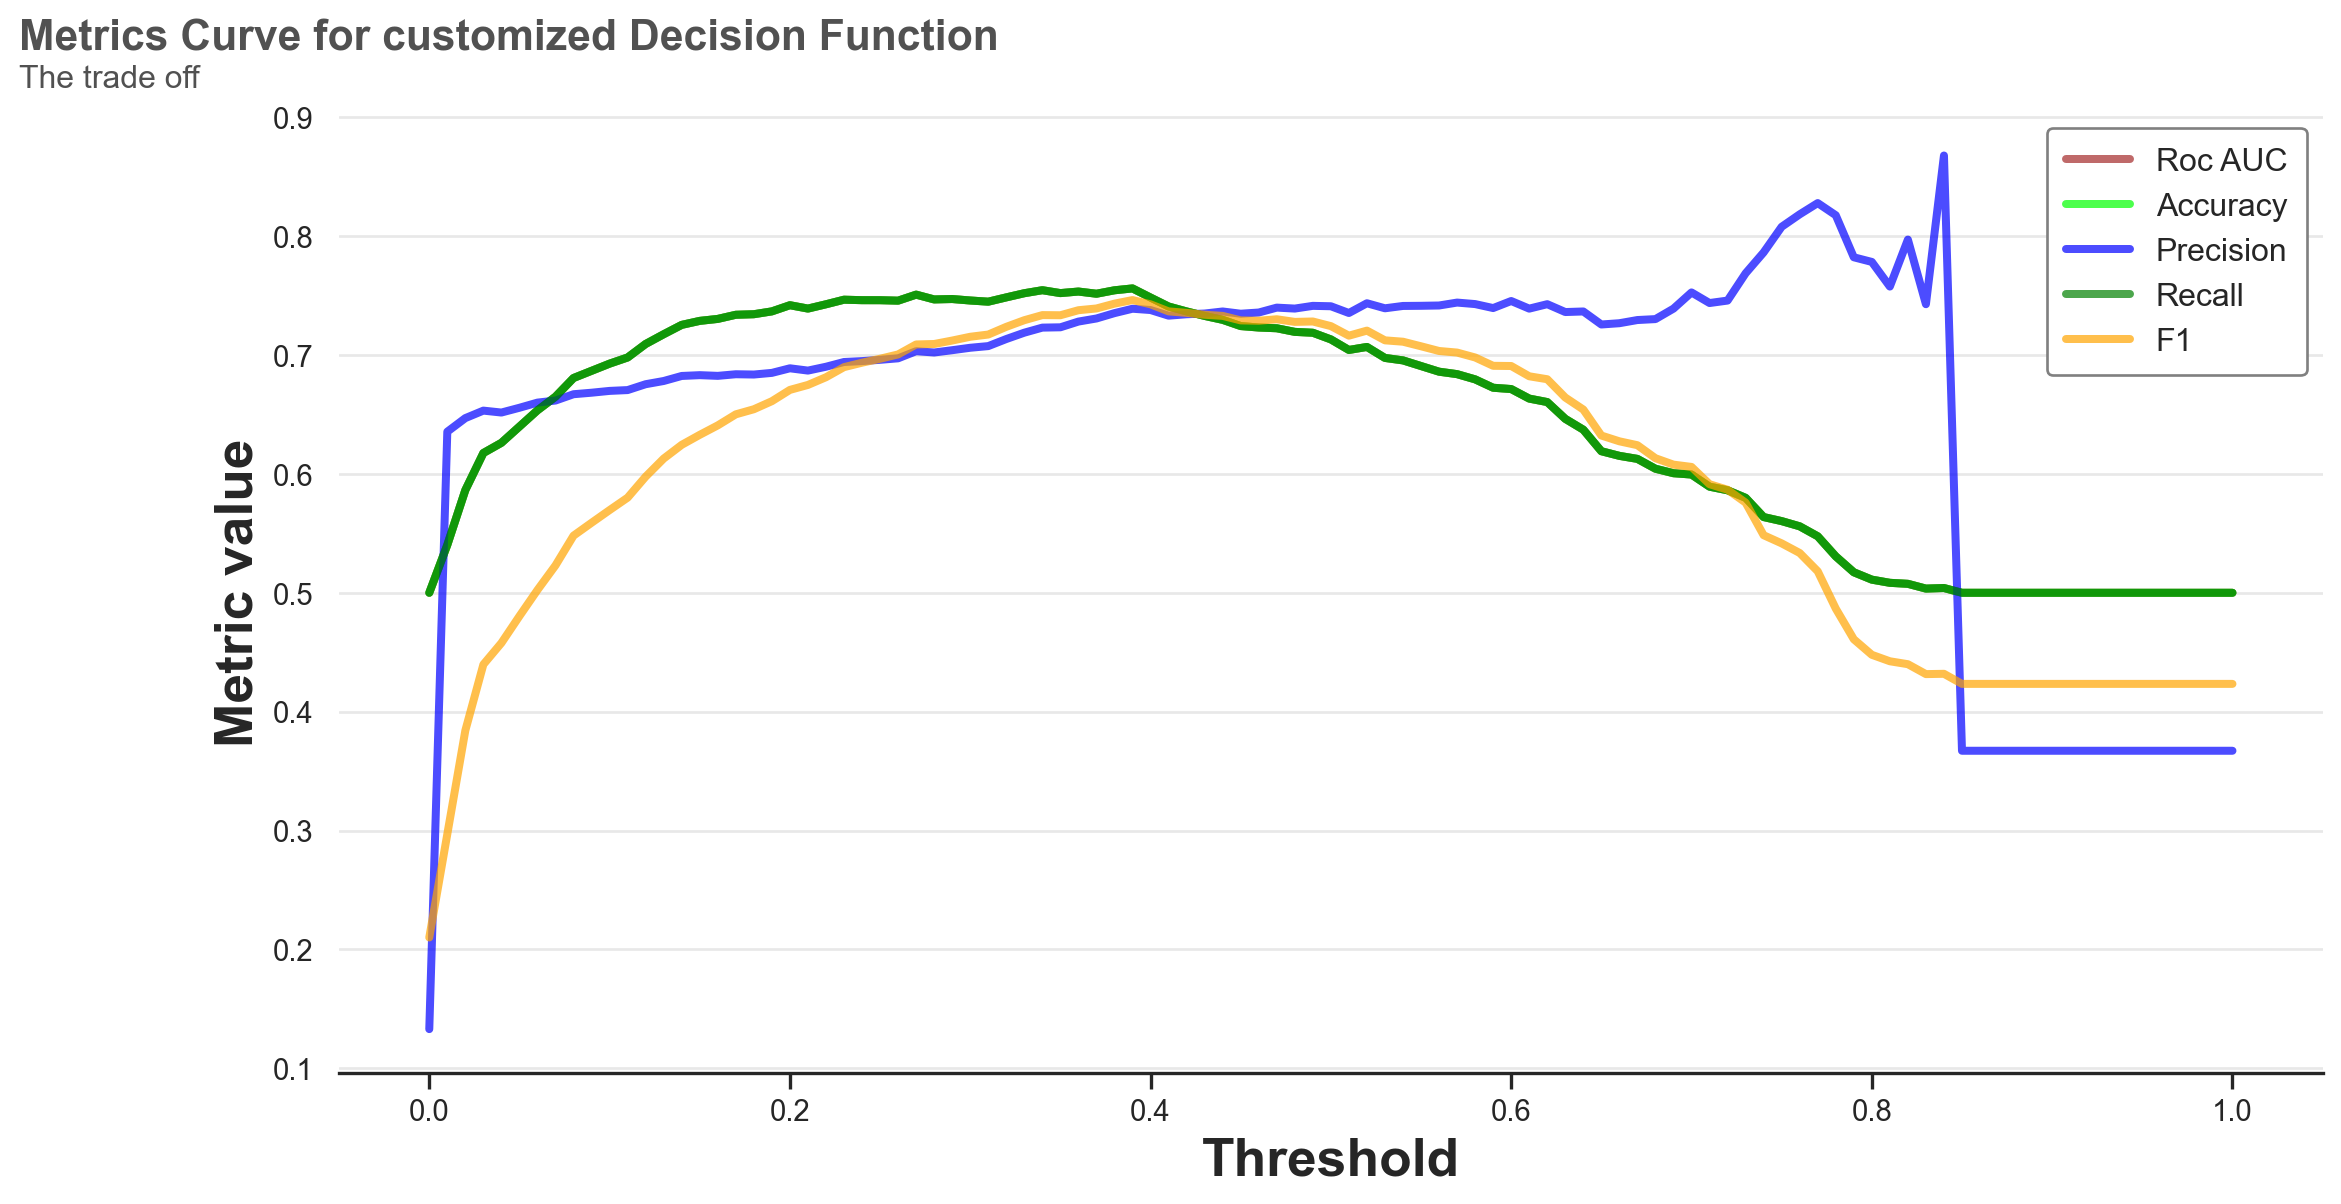

In [46]:
def plot_metrics(df_metric):
    fig, ax = plt.subplots()

    #for idx, df in enumerate(df_metric):
    ax.plot(df_metric.Threshold, df_metric.Roc_auc, color='brown', alpha=0.7,
                label='Roc AUC') # if idx == 0 else None
    ax.plot(df_metric.Threshold, df_metric.Accuracy, color='lime', alpha=0.7,
                label='Accuracy')
    ax.plot(df_metric.Threshold, df_metric.Precision_macro, color='blue', alpha=0.7,
                label='Precision')
    ax.plot(df_metric.Threshold, df_metric.Recall_macro, color='green', alpha=0.7,
                label='Recall')
    ax.plot(df_metric.Threshold, df_metric.F1_macro, color='orange', alpha=0.7,
                label='F1')

    plt.xlabel('Threshold')
    plt.ylabel('Metric value')  

    # Add in title and subtitle
    ax.text(x=0.0, y=.93, 
        s="Metrics Curve for customized Decision Function", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=16, 
        weight='bold', 
        alpha=.8
        )

    ax.text(x=0.0, y=.90, 
        s="The trade off", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=12, 
        alpha=.8)

    """# Add in red line and rectangle on top
    ax.plot([0.0, .9], [.98, .98], 
        transform=fig.transFigure, 
        clip_on=False, 
        color='#E3120B', 
        linewidth=.6)
    ax.add_patch(plt.Rectangle((0.0,.98), 
        0.04, -0.02, 
        facecolor='#E3120B', 
        transform=fig.transFigure, 
        clip_on=False, 
        linewidth = 0))"""

    plt.legend()
    plt.show()

plot_metrics(df_metric)

**`Insights Considerations — Decision Function`:**

The analysis of the decision function demonstrates that model performance is not solely determined by the learning algorithm, but also by the choice of classification threshold. The metric curves clearly illustrate the inherent trade-off between precision and recall: as the threshold increases, precision improves while recall deteriorates, and vice versa. This behavior confirms that the default threshold of 0.5 is not necessarily optimal, particularly in imbalanced classification scenarios such as churn prediction.

From a practical standpoint, threshold selection becomes a strategic decision rather than a purely technical one. Lower thresholds favor recall, enabling the identification of a larger proportion of churners, which is critical in retention-focused strategies. Conversely, higher thresholds improve precision, reducing false positives and making them more suitable for cost-sensitive interventions. The relatively stable behavior of ROC AUC and balanced accuracy across thresholds further indicates that the model maintains consistent discriminative power, while the variation in other metrics reflects different operational trade-offs.

An important advantage of this approach is that threshold optimization is computationally inexpensive, as it leverages the probabilistic outputs of an already trained model without requiring retraining or additional model complexity. This makes it a highly efficient mechanism for performance tuning, especially when compared to more costly alternatives such as hyperparameter optimization or model ensembling.

Additionally, storing the evaluation metrics across thresholds provides a structured baseline that can be directly compared with future models and pipelines. This enables a consistent and reproducible evaluation framework, ensuring that improvements are measured objectively and not influenced by arbitrary threshold choices.

Therefore, instead of adopting a fixed threshold, the model should be deployed with a threshold aligned to business objectives. This approach transforms the classifier into a flexible decision-support tool, capable of adapting to different operational constraints and strategic priorities.


In [47]:
from json import dumps, loads
import numpy as np
import pandas as pd


def save_threshold_metrics(
    df_metric: pd.DataFrame,
    thresholds: list[float],
    metric_df: pd.DataFrame,
    baseline_estimator_name: str = "LogisticRegression",
    baseline_encoder_name: str = "OrdinalEncoder",
    baseline_data_model: str = "Baseline",
    threshold_data_model: str = "Baseline + Threshold tuning",
    w_recall: float = 7.0,
    w_precision: float = 3.0,
    w_time: float = 0.0,
    time_reference: float = 1.0,
    metric_path: str = "./dataset/metric_dataframe.csv"
) -> pd.DataFrame:
    """
    Save threshold tuning results into metric_dataframe, inheriting
    training and timing information from the baseline row.

    Parameters
    ----------
    df_metric : pd.DataFrame
        DataFrame containing threshold metrics.
    thresholds : list[float]
        Thresholds to persist.
    metric_df : pd.DataFrame
        Existing metric dataframe.
    baseline_estimator_name : str, default="LogisticRegression"
        Estimator name used in baseline row lookup.
    baseline_encoder_name : str, default="OrdinalEncoder"
        Encoder/pipeline name used in baseline row lookup.
    baseline_data_model : str, default="Baseline"
        Baseline data model tag.
    threshold_data_model : str, default="Baseline + Threshold tuning"
        Threshold tuning data model tag.
    w_recall : float, default=7.0
        Weight assigned to recall in business score.
    w_precision : float, default=3.0
        Weight assigned to precision in business score.
    w_time : float, default=0.0
        Weight assigned to time penalty in business score.
    time_reference : float, default=1.0
        Reference value used to scale time penalty.
    metric_path : str, default="./dataset/metric_dataframe.csv"
        Path to save metric dataframe.

    Returns
    -------
    pd.DataFrame
        Updated metric dataframe.
    """
    if isinstance(metric_df.index, pd.MultiIndex):
        metric_df = metric_df.reset_index()

    baseline_mask = (
        (metric_df["Estimator"] == baseline_estimator_name)
        & (metric_df["Optimization/Data model"] == baseline_data_model)
        & (metric_df["Pre-Process Pipeline"] == baseline_encoder_name)
    )

    if not baseline_mask.any():
        raise KeyError(
            "Baseline row not found in metric_df: "
            f"{(baseline_estimator_name, baseline_data_model, baseline_encoder_name)}"
        )

    baseline_row = metric_df.loc[baseline_mask].iloc[0]

    try:
        baseline_params = loads(baseline_row.get("Parameters", "{}") or "{}")
    except Exception:
        baseline_params = {}

    if not isinstance(baseline_params, dict):
        baseline_params = {}

    business_weights = dumps({
        "w_recall": w_recall,
        "w_precision": w_precision,
        "w_time": w_time,
        "time_reference": time_reference
    })

    fit_time = baseline_row.get("Fit Time", np.nan)
    score_time = baseline_row.get("Score Time", np.nan)
    total_time = baseline_row.get("Total Time", np.nan)

    for threshold in thresholds:
        row = df_metric.loc[np.isclose(df_metric["Threshold"], threshold)]

        if row.empty:
            print(f"[WARN] Threshold {threshold:.4f} não encontrado em df_metric.")
            continue

        row = row.iloc[0]
        pipeline_name = f"{baseline_encoder_name} | thr={threshold:.2f}"
        row_identity = {
            "Estimator": baseline_estimator_name,
            "Optimization/Data model": threshold_data_model,
            "Pre-Process Pipeline": pipeline_name,
        }

        # business score
        if pd.notna(total_time) and time_reference > 0:
            time_penalty = total_time / time_reference
        else:
            time_penalty = 0.0

        weight_sum = w_recall + w_precision + w_time
        if weight_sum <= 0:
            raise ValueError("A soma dos pesos deve ser maior que zero.")

        wr = w_recall / weight_sum
        wp = w_precision / weight_sum
        wt = w_time / weight_sum

        business_score = (
            (wr * row["Recall_macro"]) +
            (wp * row["Precision_macro"]) -
            (wt * time_penalty)
        )

        threshold_params = {
            **baseline_params,
            "threshold": float(threshold),
        }

        values_to_save = {
            **row_identity,
            "Train Roc auc": baseline_row.get("Train Roc auc", np.nan),
            "Test Roc auc": row["Roc_auc"],
            "Train Balanced Accuracy": baseline_row.get("Train Balanced Accuracy", np.nan),
            "Test Balanced Accuracy": row["Accuracy"],
            "Train Recall": baseline_row.get("Train Recall", np.nan),
            "Test Recall": row["Recall_macro"],
            "Train Precision": baseline_row.get("Train Precision", np.nan),
            "Test Precision": row["Precision_macro"],
            "Train F1": baseline_row.get("Train F1", np.nan),
            "Test F1": row["F1_macro"],
            "Parameters": dumps(threshold_params, default=str),
            "Fit Time": fit_time,
            "Score Time": score_time,
            "Total Time": total_time,
            "Business Score": business_score,
            "Business Weights": business_weights
        }

        row_mask = (
            (metric_df["Estimator"] == row_identity["Estimator"])
            & (metric_df["Optimization/Data model"] == row_identity["Optimization/Data model"])
            & (metric_df["Pre-Process Pipeline"] == row_identity["Pre-Process Pipeline"])
        )

        if row_mask.any():
            metric_df = metric_df.loc[~row_mask].copy()

        new_row = pd.DataFrame([values_to_save])

        if metric_df.empty:
            metric_df = new_row
        else:
            metric_df = pd.concat(
                [metric_df, new_row],
                ignore_index=True,
            )

    metric_df.to_csv(metric_path, index=False)
    return metric_df

metric_dataframe = save_threshold_metrics(
    df_metric=df_metric,
    thresholds=[0.22, 0.42],
    metric_df=metric_dataframe,
    baseline_estimator_name="LogisticRegression",
    baseline_encoder_name="OrdinalEncoder",
    baseline_data_model="Baseline",
    threshold_data_model="Baseline + Threshold tuning",
    w_recall=7,
    w_precision=3,
    w_time=0,
    time_reference=1.0
)

In [48]:
metric_dataframe.sort_values('Test Recall', ascending=False, inplace=True)
metric_dataframe

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
6,LGBMClassifier,Recall Macro Opt Balanced,CatBoostEncoder PowerTransformer RFE 13 | thr=0.500,0.838865,0.830506,0.765584,0.756138,0.765584,0.756138,0.712469,0.702669,0.716161,0.701618,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",2.261283,0.062490,2.323773,0.740097,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
12,RandomForestClassifier,Recall Macro Opt Balanced + Threshold tuning,OneHotEncoder MinMaxScaler StandardScaler SelectFromModel 12 | thr=0.480,0.841632,0.834231,0.769750,0.756068,0.769750,0.756068,0.719724,0.706573,0.727580,0.711725,"{""criterion"": ""entropy"", ""max_depth"": 8, ""max_features"": 9, ""n_estimators"": 277, ""min_samples_split"": 51, ""min_samples_leaf"": 6, ""random_state"": 738, ""class_weight"": {""0"": 0.265778, ""1"": 0.734222}, ""threshold"": 0.48}",5.561666,0.189012,5.750677,0.741220,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
13,RandomForestClassifier,Recall Macro Opt Over-sampling + Threshold tuning,OneHotEncoder QuantileTransformer RobustScaler SelectFromModel 13 SMOTE | thr=0.450,0.839546,0.830899,0.767645,0.755838,0.767645,0.755838,0.718822,0.705546,0.727092,0.709733,"{""criterion"": ""gini"", ""max_depth"": 7, ""max_features"": 11, ""n_estimators"": 202, ""min_samples_split"": 34, ""min_samples_leaf"": 16, ""random_state"": 738, ""threshold"": 0.45}",7.793979,0.207159,8.001138,0.740751,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
15,SGDClassifier,Recall Macro Opt Balanced,GLMMEncoder QuantileTransformerN StandardScaler RFE 12 | thr=0.500,0.848833,0.841149,0.773824,0.754456,0.773824,0.754456,0.718435,0.700650,0.721771,0.697669,"{""max_iter"": 629, ""alpha"": 0.03153034676207791, ""learning_rate"": ""optimal"", ""loss"": ""log_loss"", ""penalty"": ""l2"", ""eta0"": 6, ""early_stopping"": true, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",5.525057,0.049260,5.574317,0.738314,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
10,LogisticRegression,Recall Macro Opt Over-sampling,JamesSteinEncoder PowerTransformer RobustScaler RFE 12 SMOTE | thr=0.500,0.847773,0.837393,0.771835,0.754109,0.771835,0.754109,0.725132,0.706243,0.735139,0.712459,"{""penalty"": ""l2"", ""solver"": ""saga"", ""C"": 1.4910169316251025, ""random_state"": 738, ""threshold"": 0.5}",1.671590,0.041108,1.712699,0.739749,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
7,LGBMClassifier,Recall Macro Opt Over-sampling,CatBoostEncoder PowerTransformer RFE 13 SMOTE | thr=0.500,0.839134,0.828063,0.767111,0.751390,0.767111,0.751390,0.715092,0.699544,0.720580,0.699601,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""threshold"": 0.5}",2.427090,0.069897,2.496987,0.735836,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
9,LogisticRegression,Recall Macro Opt Balanced,Binar

### Decision Function and ROC AUC — Conceptual Analysis

The decision function defines how predicted probabilities are converted into class labels in binary classification models. In Logistic Regression, the model outputs a probability  $P(y=1 \mid X)$, and a threshold is applied to determine the final prediction. By default, this threshold is 0.5, but this value is not necessarily optimal, especially in imbalanced datasets such as customer churn.

To improve model performance, multiple thresholds in the interval ([0, 1]) were evaluated, analyzing their impact on key classification metrics.

#### Relationship between Threshold and Metrics

* Lower thresholds increase the number of predicted positive cases: higher Recall, lower Precision
* Higher thresholds make the model more conservative: higher Precision, lower Recall
* Intermediate thresholds balance both metrics: typically maximize F1 score

This behavior characterizes the classic trade-off between sensitivity and specificity, clearly observed in the metric curves.


#### ROC AUC Interpretation under Threshold Variation

* ROC AUC was computed using thresholded predictions rather than continuous probabilities
* This makes ROC AUC numerically close to Balanced Accuracy
* Both metrics reflect the model’s ability to balance true positives and true negatives at a fixed threshold
* The region between thresholds 0.22 and 0.42 represents the most stable performance zone

This indicates that the model maintains consistent discriminative power across different decision boundaries.

#### Optimal Threshold Region

* Threshold ≈ 0.22: maximizes Recall, suitable for recall-driven scenarios such as churn prevention
* Threshold ≈ 0.42: improves Precision and F1, providing a more balanced decision boundary

The optimal threshold must be selected according to the business objective rather than relying on the default value.

#### Computational Considerations

* Threshold tuning does not require retraining the model
* It operates directly on predicted probabilities
* Computational cost is low and scales linearly with the number of thresholds

This makes it a highly efficient optimization step with significant impact on model performance.

#### Integration with Model Evaluation Framework

* Results were stored in the same `metric_dataframe` used for model comparison
* Tagged as `"Baseline + Threshold tuning"` to ensure traceability
* Includes: performance metrics, execution time inherited from baseline, decision parameters and business score

This guarantees consistency, reproducibility and comparability across different models and configurations.

#### Key Insight

* The decision threshold is a controllable parameter that directly affects model behavior
* Adjusting the threshold allows the same model to adapt to different business requirements
* This approach improves performance without increasing computational cost


<span style="color:steelblue; text-align: left">

### Train models
</span>

#### Train Models

In this stage, multiple models are trained using what we define as a *dynamic pipeline*.

A dynamic pipeline is a flexible structure where preprocessing steps are not fixed, but instead adapt according to the estimator being evaluated. This allows different models to operate under their optimal preprocessing conditions within the same optimization framework.

#### Optuna Software Package

`Optuna` is an open-source framework for hyperparameter optimization in machine learning models. It automates the search for optimal configurations by exploring the hyperparameter space efficiently.

Hyperparameters are values defined prior to training, such as learning rate, regularization strength, or tree depth. Manually tuning these parameters is time-consuming and often suboptimal.

Optuna addresses this by using **Bayesian optimization**, balancing:

* exploration: testing new regions of the search space
* exploitation: refining known high-performing regions

At each iteration, Optuna suggests new configurations based on previous results, aiming to optimize a predefined objective function.

In this project, Optuna is used beyond traditional hyperparameter tuning:

* it selects preprocessing strategies
* it evaluates resampling techniques
* it compares multiple estimators
* it identifies the best end-to-end pipeline

In practice, Optuna is used to automate not only model tuning, but the selection of the **entire modeling pipeline**.

#### Oversampling and Undersampling Strategy

A fundamental rule in machine learning is:

* never apply resampling before splitting the data

Applying oversampling or undersampling before splitting may duplicate observations across train and test sets, leading to **data leakage** and overly optimistic results.

To avoid this:

* data is first split into training and test sets
* resampling is applied only within the training process
* cross-validation is used to ensure robustness

This is achieved using pipelines, where resampling is embedded within each fold:

* resampling occurs only on training folds
* validation folds remain untouched

This guarantees that model evaluation remains unbiased.


#### Overfitting Considerations

Overfitting occurs when a model captures noise instead of underlying patterns, leading to poor generalization.

This is especially common in flexible models such as:

* decision trees
* ensemble methods
* non-linear models

To mitigate overfitting:

* increase `min_samples_split` and `min_samples_leaf`
* control model complexity (e.g., depth, features)
* apply subsampling techniques
* use cross-validation

These parameters are explored dynamically during optimization.

#### Stratified Cross-Validation

To ensure consistent class distribution across splits, **StratifiedKFold** is used.

* preserves class proportions in each fold
* reduces variance in model evaluation
* is essential for imbalanced datasets

Example:

```python
kfolds = StratifiedKFold(n_splits=6, shuffle=True, random_state=RANDOM_SEED)

scores = cross_validate(
    pipe,
    X, y,
    cv=kfolds,
    scoring=scoring,
    n_jobs=-1
)
```

#### Imbalanced Dataset Problem

Customer churn is a typical imbalanced classification problem, where one class significantly outnumbers the other.

This leads to:

* bias toward the majority class
* poor performance on the minority class
* misleading metrics such as accuracy

To address this:

* resampling techniques are applied: oversampling, undersampling, or hybrid methods
* class distribution is handled within the pipeline
* evaluation prioritizes metrics robust to imbalance

The `imbalanced-learn` library is used to implement these strategies in a consistent and leakage-safe manner.

#### Extending Optuna Search Space

Optuna is traditionally used for hyperparameter tuning, but here its role is extended.

Instead of optimizing only model parameters, the search space includes:

* encoding strategies
* scaling methods
* resampling techniques
* feature selection methods
* model selection

This transforms the optimization process into a **pipeline search problem**, where Optuna evaluates complete modeling strategies rather than isolated components.


#### Why Optimize ROC AUC Instead of Recall Macro

Both ROC AUC and Recall Macro are important metrics, but they serve different purposes.

ROC AUC evaluates the model’s ability to distinguish between classes across all thresholds
Recall Macro evaluates performance at a specific threshold

Key differences:

ROC AUC is threshold-independent
Recall Macro is threshold-dependent
ROC AUC is more stable for model comparison
Recall Macro is more aligned with business objectives in imbalanced problems

In this project:

optimization is performed using ROC AUC
Recall Macro is monitored as a secondary constraint

This approach ensures:

stable model selection
alignment with business goals

In practical terms:

the model is optimized globally (ROC AUC)
but decision quality is controlled locally (Recall Macro)

>As we say in Brazil: "fry the fish and watch the cat" —

we optimize the model using a robust global metric while keeping a close eye on the business-critical metric.


### Optuna Objective Function

The objective function defines the optimization process by:

* constructing the pipeline dynamically
* sampling preprocessing and modeling strategies
* evaluating performance using cross-validation
* returning the metric to be optimized

Additionally:

* all relevant metrics are logged
* computational cost is tracked
* results are stored for comparison

This ensures that the optimization process is:

* transparent
* reproducible
* fully auditable



<span style="color:steelblue; text-align: left">

#### Optuna objective function
</span>

The objective function defines the optimization process by:

constructing the pipeline dynamically
sampling preprocessing and modeling strategies
evaluating performance using cross-validation
returning the metric to be optimized

Additionally:

all relevant metrics are logged
computational cost is tracked
results are stored for comparison

This ensures that the optimization process is:

transparent
reproducible
fully auditable

In [49]:
from pandas.api.types import is_string_dtype

idx_column = [
    column_name
    for column_name in train_features.columns
    if is_string_dtype(train_features[column_name])
]

idx_column

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [50]:
import logging
import sys
import gc
from tempfile import mkdtemp
from shutil import rmtree
from json import dumps

import numpy as np
import pandas as pd

import xgboost
from xgboost import XGBClassifier
import lightgbm 
from lightgbm import LGBMClassifier

import sklearn
from sklearn import linear_model, ensemble, tree, neural_network

from sklearn.model_selection import train_test_split
from sklearn.metrics import (   balanced_accuracy_score,
                                f1_score, 
                                precision_score, 
                                recall_score, 
                                classification_report )
from sklearn.metrics import make_scorer                                
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
                                GradientBoostingClassifier, 
                                ExtraTreesClassifier,  
                                RandomForestClassifier, 
                                )
from sklearn.linear_model import ( 
                                LogisticRegression, 
                                SGDClassifier )

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import chi2
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import (
                                    SequentialFeatureSelector,
                                    SelectKBest, mutual_info_regression,
                                    RFE, SelectFromModel)

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold, cross_val_score
import sklearn.preprocessing
from sklearn.preprocessing import MaxAbsScaler, QuantileTransformer, Normalizer, KBinsDiscretizer

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as Pipeline_imblearn
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import balanced_accuracy_score

import re

import optuna
from optuna.samplers import TPESampler

import category_encoders
from category_encoders import (BackwardDifferenceEncoder,
                                BinaryEncoder,
                                GrayEncoder,
                                CountEncoder,
                                HashingEncoder,
                                HelmertEncoder,
                                OneHotEncoder,
                                OrdinalEncoder,
                                SumEncoder,
                                PolynomialEncoder,
                                BaseNEncoder,
                                LeaveOneOutEncoder,
                                TargetEncoder,
                                WOEEncoder,
                                MEstimateEncoder,
                                JamesSteinEncoder,
                                CatBoostEncoder,
                                GLMMEncoder,
                                QuantileEncoder,
                                SummaryEncoder,
                                RankHotEncoder)
from feature_engine.encoding import (MeanEncoder, 
                                    CountFrequencyEncoder,
                                    DecisionTreeEncoder)

# Over-sampling
import imblearn
from imblearn import over_sampling
from imblearn.over_sampling import SMOTE
from collections import Counter
from tqdm import tqdm 

import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn import set_config
import pickle
import gzip
from platform import python_version

print('Python version : ', python_version())
print('Sklearn version : ', sklearn.__version__)
print('Pandas version : ', pd.__version__)
print('Numpy version : ', np.__version__)
print('Imblearn version :', imblearn.__version__)
print('Optuna version :', optuna.__version__)


Python version :  3.11.15
Sklearn version :  1.8.0
Pandas version :  3.0.2
Numpy version :  2.4.4
Imblearn version : 0.14.1
Optuna version : 4.8.0


<span style="color:steelblue; text-align: left">

#### Calling optimizer class to train models
</span>

Este abaixo é o novo

In [51]:
from __future__ import annotations

import gc
from pathlib import Path
from shutil import rmtree
from tempfile import mkdtemp
from pandas.api.types import is_string_dtype

import category_encoders
import lightgbm
import numpy as np
import optuna
import xgboost

from feature_engine.encoding import (
    CountFrequencyEncoder,
    DecisionTreeEncoder,
    MeanEncoder,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler
from optuna.samplers import TPESampler
from sklearn import ensemble, linear_model, neural_network, tree
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.feature_selection import (
    RFE,
    SelectFromModel,
    SelectKBest,
    SequentialFeatureSelector,
    mutual_info_classif,
)
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
)
import catboost
from catboost import CatBoostClassifier


def define_estimators() -> tuple[
    list[str],
    list[str],
    list[str],
    list[str],
    list[str],
    list[str],
    list[str],
]:
    """
    Build and return the estimator groups used in the experiment.
    """
    linear_estimators = [
        estimator for estimator in set(linear_model.__all__)
        if "Class" in estimator
    ]
    linear_estimators.append("LogisticRegression")

    ensemble_estimators = [
        estimator for estimator in set(ensemble.__all__)
        if "Class" in estimator
    ]

    tree_estimators = [
        estimator for estimator in set(tree.__all__)
        if "Class" in estimator
    ]

    neural_estimators = [
        estimator for estimator in set(neural_network.__all__)
        if "Class" in estimator
    ]

    xgb_estimators = ["XGBClassifier"]
    lgbm_estimators = ["LGBMClassifier"]

    estimators = (
        linear_estimators +
        ensemble_estimators +
        tree_estimators
    )

    excluded_estimators = {
        "StackingClassifier",
        "RidgeClassifierCV",
        "SGDOneClassSVM",
        "VotingClassifier",
        "AdaBoostClassifier",
        "BaggingClassifier",
    }

    estimators = [est for est in estimators if est not in excluded_estimators]
    estimators.extend(["LogisticRegression", "XGBClassifier", "LGBMClassifier"])

    catboost_estimators = ["CatBoostClassifier"]

    return (
        linear_estimators,
        ensemble_estimators,
        tree_estimators,
        neural_estimators,
        xgb_estimators,
        lgbm_estimators,
        catboost_estimators,
        estimators,
    )

def get_estimator(
    estimator_name: str,
    linear_estimators: list[str],
    ensemble_estimators: list[str],
    tree_estimators: list[str],
    neural_estimators: list[str],
    xgb_estimators: list[str],
    lgbm_estimators: list[str],
    catboost_estimators: list[str],
) -> object:
    """
    Return the estimator class from its name.
    """
    if estimator_name in linear_estimators:
        return getattr(linear_model, estimator_name)

    if estimator_name in ensemble_estimators:
        return getattr(ensemble, estimator_name)

    if estimator_name in tree_estimators:
        return getattr(tree, estimator_name)

    if estimator_name in xgb_estimators:
        return getattr(xgboost, estimator_name)

    if estimator_name in lgbm_estimators:
        return getattr(lightgbm, estimator_name)

    if estimator_name in catboost_estimators:
        return getattr(catboost, estimator_name)
    
    return getattr(neural_network, estimator_name)


class EarlyStoppingCallback:
    def __init__(self, patience: int = 20, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.no_improvement_count = 0

    def __call__(self, study, trial):
        if trial.value is None:
            return

        current_score = study.best_value

        if self.best_score is None:
            self.best_score = current_score
            return

        improvement = current_score - self.best_score

        if improvement > self.min_delta:
            self.best_score = current_score
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1

        if self.no_improvement_count >= self.patience:
            study.stop()
            
class Optimizer:
    """
    Optimize a full classification pipeline with Optuna.
    """

    def __init__(
        self,
        estimator_name: str,
        balanced: bool,
        train_features,
        train_labels,
        cv,
        random_seed: int,
        x_reference,
        ratio_min: float | None = None,
        ratio_max: float | None = None,
        resampler: str = "",
        sampling_method: str = "",
        trials: int = 50,
        early_stopping_patience: int = 20,
        early_stopping_min_delta: float = 1e-4,
        timeout: int | None = 300,
        test_features: pd.DataFrame | None = None,
        test_labels: np.ndarray | None = None,
        metric_df: pd.DataFrame | None = None,
    ) -> None:
        self.estimator_name = estimator_name
        self.balanced = balanced
        self.train_features = train_features
        self.train_labels = train_labels
        self.cv = cv
        self.random_seed = random_seed
        self.x_reference = x_reference

        self.resampler = resampler
        self.sampling_method = sampling_method
        self.trials = trials
        self.sampler = TPESampler(seed=random_seed)
        self.early_stopping_patience = early_stopping_patience
        self.early_stopping_min_delta = early_stopping_min_delta
        self.timeout = timeout
        self.invalid_configs = set()
        
        self.test_features = test_features
        self.test_labels = test_labels
        self.metric_df = metric_df
        
        # Ensure ratio_min and ratio_max are either both None or both floats, 
        # and that ratio_min <= ratio_max when both are provided
        if ratio_min is not None and ratio_max is not None:
            self.ratio_min = min(float(ratio_min), float(ratio_max))
            self.ratio_max = max(float(ratio_min), float(ratio_max))
            
        else:
            self.ratio_min = ratio_min
            self.ratio_max = ratio_max

        (
            self.linear_estimators,
            self.ensemble_estimators,
            self.tree_estimators,
            self.neural_estimators,
            self.xgb_estimators,
            self.lgbm_estimators,
            self.catboost_estimators,
            self.available_estimators,
        ) = define_estimators()

        # Define the full scoring dictionary for cross-validation
        self.scoring_full = {
            "roc_auc": make_scorer(roc_auc_score, average="macro"),
            "precision_macro": make_scorer(precision_score, average="macro"),
            "recall_macro": make_scorer(recall_score, average="macro"),
            "f1_macro": make_scorer(f1_score, average="macro"),
            "balanced_accuracy": make_scorer(balanced_accuracy_score),
        }

        self.scoring_objective = {
            "recall_macro": make_scorer(
                recall_score,
                average="macro",
                zero_division=0,
            )
        }
        
        # Define the path to save invalid configurations
        self.invalid_path = Path("./dataset/invalid_configs.csv")

        cols = [
            "estimator", "encoder", "scaler",
            "normalizer", "selector", "sampler"
        ]

        # Load existing invalid configurations if the file exists, 
        # otherwise initialize an empty DataFrame
        if self.invalid_path.exists():
            self.invalid_df = pd.read_csv(self.invalid_path)
            
        else:
            self.invalid_df = pd.DataFrame(columns=cols)
        
    def _sig(self, encoder, scaler, normalizer, selector, sampler):
        """_summary_

        Args:
            encoder (_type_): _description_
            scaler (_type_): _description_
            normalizer (_type_): _description_
            selector (_type_): _description_
            sampler (_type_): _description_

        Returns:
            _type_: _description_
        """
        return {
            "estimator": self.estimator_name,
            "encoder": encoder or "None",
            "scaler": scaler or "None",
            "normalizer": normalizer or "None",
            "selector": selector or "None",
            "sampler": sampler or "None",
        }
        
    def build_config_signature(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
    ) -> dict:
        """
        Build a readable configuration signature.
        """
        return {
            "estimator": self.estimator_name,
            "encoder": encoder_name or "None",
            "scaler": scaler_name or "None",
            "normalizer": normalizer_name or "None",
            "selector": selector_name or "None",
            "sampler": sampler_name or "None",
        }


    def was_invalid_config(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
    ) -> bool:
        """
        Check whether a configuration was previously marked as invalid.
        """
        signature = self.build_config_signature(
            encoder_name,
            scaler_name,
            normalizer_name,
            selector_name,
            sampler_name,
        )

        if self.invalid_df.empty:
            return False

        mask = (
            (self.invalid_df["estimator"] == signature["estimator"])
            & (self.invalid_df["encoder"] == signature["encoder"])
            & (self.invalid_df["scaler"] == signature["scaler"])
            & (self.invalid_df["normalizer"] == signature["normalizer"])
            & (self.invalid_df["selector"] == signature["selector"])
            & (self.invalid_df["sampler"] == signature["sampler"])
        )

        return bool(mask.any())


    def register_invalid_config(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
        reason: str = "",
    ) -> None:
        """
        Register an invalid configuration in memory.
        """
        signature = self.build_config_signature(
            encoder_name,
            scaler_name,
            normalizer_name,
            selector_name,
            sampler_name,
        )

        signature["reason"] = reason

        new_row = pd.DataFrame([signature])

        self.invalid_df = pd.concat(
            [self.invalid_df, new_row],
            ignore_index=True,
        )

        self.invalid_df.drop_duplicates(
            subset=[
                "estimator",
                "encoder",
                "scaler",
                "normalizer",
                "selector",
                "sampler",
            ],
            inplace=True,
        )


    def flush_invalid_configs(self) -> None:
        """
        Persist invalid configurations to disk.
        """
        self.invalid_df.to_csv(self.invalid_path, index=False)


    def is_invalid_pipeline(
        self,
        encoder_name,
        scaler_name,
        normalizer_name,
        selector_name,
        sampler_name,
    ) -> bool:
        """
        Apply known invalid pipeline rules before model evaluation.
        """
        if self.estimator_name == "CatBoostClassifier":
            invalid_rules = [
                encoder_name not in ["NoEncoding", "NoCategoricalEncoder"],
                scaler_name not in ["NoScaling", None],
                normalizer_name not in ["NoNormalization", None],
                selector_name in ["RFE", "SequentialFeatureSelector"],
            ]

            return any(invalid_rules)

        return False
    
    def get_parameters(self, trial) -> dict:
        """
        Define estimator hyperparameters for Optuna.
        """
        params = {}

        if self.estimator_name == "SGDClassifier":
            params = {
                "max_iter": trial.suggest_int("max_iter", 300, 2000, log=True),
                "alpha": trial.suggest_float("alpha", 0.01, 1.0, log=True),
                "learning_rate": trial.suggest_categorical(
                    "learning_rate",
                    ["optimal", "constant", "invscaling"],
                ),
                "loss": trial.suggest_categorical(
                    "loss",
                    ["log_loss", "modified_huber"],
                ),
                "penalty": trial.suggest_categorical("penalty", ["l2", "l1"]),
                "eta0": trial.suggest_int("eta0", 1, 10, step=1),
                "early_stopping": True,
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "RandomForestClassifier":
            params = {
                "criterion": trial.suggest_categorical(
                    "criterion", ["entropy", "gini"]
                ),
                "max_depth": trial.suggest_int("max_depth", 5, 8, step=1),
                "max_features": trial.suggest_int("max_features", 7, 14, step=1),
                "n_estimators": trial.suggest_int(
                    "n_estimators", 140, 300, log=True
                ),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 20, 70, log=True
                ),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 2, 16, step=1
                ),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = trial.suggest_categorical(
                    "class_weight",
                    [{0: 0.265778, 1: 0.734222}, "balanced"],
                )

        elif self.estimator_name == "XGBClassifier":
            params = {
                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.1, 1.0, log=True
                ),
                "max_depth": trial.suggest_int("max_depth", 1, 6, step=1),
                "subsample": trial.suggest_float("subsample", 0.1, 1.0, log=True),
                "colsample_bytree": trial.suggest_float(
                    "colsample_bytree", 0.1, 1.0, log=True
                ),
            }
            if self.balanced and self.ratio_min is not None and self.ratio_max is not None:
                params["scale_pos_weight"] = trial.suggest_float(
                    "scale_pos_weight",
                    float(self.ratio_min),
                    float(self.ratio_max),
                    log=True,
                )

        elif self.estimator_name == "LGBMClassifier":
            params = {
                "objective": "binary",
                "metric": "binary_logloss",
                "boosting_type": "gbdt",
                "force_col_wise": True,
                "num_leaves": trial.suggest_int("num_leaves", 2, 256, step=1),
                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.01, 0.1, log=True
                ),
                "min_child_samples": trial.suggest_int(
                    "min_child_samples", 5, 100, log=True
                ),
                "subsample": trial.suggest_float("subsample", 0.1, 1.0, log=True),
                "colsample_bytree": trial.suggest_float(
                    "colsample_bytree", 0.1, 1.0, log=True
                ),
                "reg_alpha": trial.suggest_float(
                    "reg_alpha", 1e-9, 100.0, log=True
                ),
                "reg_lambda": trial.suggest_float(
                    "reg_lambda", 1e-9, 100.0, log=True
                ),
                "max_depth": trial.suggest_int("max_depth", -1, 8, step=1),
                "verbosity": -1,
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "LogisticRegression":
            params = {
                "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
                "solver": trial.suggest_categorical("solver", ["liblinear", "saga"]),
                "C": trial.suggest_float("C", 0.0025, 30.0, log=True),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "DecisionTreeClassifier":
            params = {
                "max_depth": trial.suggest_int("max_depth", 2, 16, log=True),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 20, 80, log=True
                ),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 10, 30, step=1
                ),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "ExtraTreeClassifier":
            params = {
                "criterion": trial.suggest_categorical(
                    "criterion", ["gini", "entropy"]
                ),
                "max_depth": trial.suggest_int("max_depth", 2, 90, log=True),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 2, 377, log=True
                ),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 2, 377, log=True
                ),
                "random_state": self.random_seed,
            }
            if self.balanced:
                params["class_weight"] = "balanced"

        elif self.estimator_name == "ExtraTreesClassifier":
            params = {
                "max_depth": trial.suggest_int("max_depth", 2, 20, step=1),
                "min_samples_split": trial.suggest_int(
                    "min_samples_split", 2, 377, log=True
                ),
                "min_samples_leaf": trial.suggest_int(
                    "min_samples_leaf", 2, 377, log=True
                ),
                "random_state": self.random_seed,
            }

        return params

    def get_standardization(self, trial) -> tuple[object | None, str | None]:
        """
        Return the scaler object sampled by Optuna.
        """
        scaler_name = trial.suggest_categorical(
            "standardizer",
            ["MaxAbsScaler", "StandardScaler", "RobustScaler", None],
        )

        if scaler_name == "MaxAbsScaler":
            return MaxAbsScaler(), scaler_name
        if scaler_name == "StandardScaler":
            return StandardScaler(), scaler_name
        if scaler_name == "RobustScaler":
            return RobustScaler(), scaler_name
        return None, scaler_name

    def get_normalization(self, trial) -> tuple[object | None, str | None]:
        """
        Return the normalizer object sampled by Optuna.
        """
        normalizer_name = trial.suggest_categorical(
            "normalizer",
            [
                "PowerTransformer",
                "QuantileTransformer",
                "QuantileTransformerN",
                "MinMaxScaler",
                "Normalizer",
                None,
            ],
        )

        if normalizer_name == "PowerTransformer":
            return PowerTransformer(), normalizer_name
        if normalizer_name == "QuantileTransformer":
            return QuantileTransformer(output_distribution="uniform"), normalizer_name
        if normalizer_name == "QuantileTransformerN":
            return QuantileTransformer(output_distribution="normal"), normalizer_name
        if normalizer_name == "Normalizer":
            return Normalizer(), normalizer_name
        if normalizer_name == "MinMaxScaler":
            return MinMaxScaler(feature_range=(0, 1)), normalizer_name
        return None, normalizer_name

    def get_feature_selection(
        self,
        trial,
        estimator: object,
    ) -> tuple[object, str, int]:
        """
        Return the feature selector sampled by Optuna.
        """

        if self.estimator_name == "CatBoostClassifier":
            return "passthrough", "NoFeatureSelection", {}
        
        selector_name = trial.suggest_categorical(
            "selector",
            [
                "SelectKBest",
                "RFE",
                "SelectFromModel",
                "SequentialFeatureSelector",
            ],
        )
        n_features = trial.suggest_int("n_features_to_select", 6, 13, step=1)

        if selector_name == "SelectKBest":
            return (
                SelectKBest(score_func=mutual_info_classif, k=n_features),
                selector_name,
                n_features,
            )

        if selector_name == "RFE":
            return (
                RFE(estimator=estimator, n_features_to_select=n_features, step=1),
                selector_name,
                n_features,
            )

        if selector_name == "SelectFromModel":
            return (
                SelectFromModel(estimator=estimator),
                selector_name,
                n_features,
            )

        return (
            SequentialFeatureSelector(
                estimator=estimator,
                n_features_to_select="auto",
                cv=3,
                tol=None,
                direction="backward",
            ),
            selector_name,
            n_features,
        )

    def get_encoders(self, trial) -> tuple[object, str]:
        """
        Return the categorical encoder sampled by Optuna.
        """
        categorical = [
            column_name
            for column_name in self.x_reference.columns
            if is_string_dtype(self.x_reference[column_name])
        ]

        if not categorical:
            return "passthrough", "NoCategoricalEncoder"

        all_encoders = [
            "OrdinalEncoder",
            "OneHotEncoder",
            "BinaryEncoder",
            "BaseNEncoder",
            "HelmertEncoder",
            "SumEncoder",
            "PolynomialEncoder",
            "MeanEncoder",
            "CountFrequencyEncoder",
            "LeaveOneOutEncoder",
            "TargetEncoder",
            "CatBoostEncoder",
            "WOEEncoder",
            "MEstimateEncoder",
            "JamesSteinEncoder",
            "GLMMEncoder",
            "QuantileEncoder",
            "DecisionTreeEncoder",
        ]

        encoder_name = trial.suggest_categorical("encoder", all_encoders)

        if encoder_name == "OrdinalEncoder":
            return category_encoders.OrdinalEncoder(), encoder_name

        if encoder_name == "OneHotEncoder":
            return category_encoders.OneHotEncoder(), encoder_name

        if encoder_name == "BinaryEncoder":
            return category_encoders.BinaryEncoder(), encoder_name

        if encoder_name == "BaseNEncoder":
            return category_encoders.BaseNEncoder(), encoder_name

        if encoder_name == "HelmertEncoder":
            return category_encoders.HelmertEncoder(), encoder_name

        if encoder_name == "SumEncoder":
            return category_encoders.SumEncoder(), encoder_name

        if encoder_name == "PolynomialEncoder":
            return category_encoders.PolynomialEncoder(), encoder_name

        if encoder_name == "LeaveOneOutEncoder":
            return category_encoders.LeaveOneOutEncoder(), encoder_name

        if encoder_name == "TargetEncoder":
            return category_encoders.TargetEncoder(), encoder_name

        if encoder_name == "CatBoostEncoder":
            return category_encoders.CatBoostEncoder(), encoder_name

        if encoder_name == "WOEEncoder":
            return category_encoders.WOEEncoder(), encoder_name

        if encoder_name == "MEstimateEncoder":
            return category_encoders.MEstimateEncoder(), encoder_name

        if encoder_name == "JamesSteinEncoder":
            return category_encoders.JamesSteinEncoder(), encoder_name

        if encoder_name == "GLMMEncoder":
            return category_encoders.GLMMEncoder(), encoder_name

        if encoder_name == "QuantileEncoder":
            return category_encoders.QuantileEncoder(), encoder_name

        if encoder_name == "MeanEncoder":
            return MeanEncoder(variables=categorical), encoder_name

        if encoder_name == "CountFrequencyEncoder":
            return (
                CountFrequencyEncoder(
                    encoding_method="count",
                    variables=categorical,
                ),
                encoder_name,
            )

        if encoder_name == "DecisionTreeEncoder":
            return (
                DecisionTreeEncoder(
                    encoding_method="arbitrary",
                    cv=3,
                    scoring="recall_macro",
                    param_grid={"max_depth": [1, 2, 3, 4, 5, 6]},
                    regression=False,
                    variables=categorical,
                ),
                encoder_name,
            )

        raise ValueError(f"Unsupported encoder: {encoder_name}")    

    def get_sampler(self, trial) -> tuple[object | None, str | None]:
        """
        Return the sampler object used for imbalance handling.

        Automatic Optuna runs are limited to no sampler or SMOTE. A fixed
        resampler may still be passed, but only supported lightweight samplers
        are accepted.
        """
        sampler_name = None

        if self.resampler:
            sampler_name = self.resampler
        elif self.sampling_method == "Over":
            sampler_name = trial.suggest_categorical(
                "resampler",
                ["SMOTE"],
            )
        elif self.sampling_method in {"Under", "Combination"}:
            raise ValueError(
                f"{self.sampling_method}-sampling is disabled for automatic runs."
            )
        elif self.sampling_method:
            raise ValueError(
                f"Unsupported sampling method: {self.sampling_method}"
            )

        if sampler_name is None:
            return None, None

        if sampler_name == "SMOTE":
            return (
                SMOTE(
                    random_state=self.random_seed,
                    sampling_strategy="minority",
                ),
                sampler_name,
            )

        raise ValueError(f"Unsupported resampler: {sampler_name}")

    @staticmethod
    def build_num_transformer(
        scaler: object | None,
        normalizer: object | None,
    ) -> ImbPipeline | str:
        """
        Build numeric preprocessing pipeline using only valid steps.
        """
        steps = []

        if normalizer is not None:
            steps.append(("normalizer", normalizer))

        if scaler is not None:
            steps.append(("scaler", scaler))

        if not steps:
            return "passthrough"

        return ImbPipeline(steps=steps)

    @staticmethod
    def build_preprocessor(num_transformer) -> ColumnTransformer:
        """
        Build the column transformer for numeric variables.
        """
        return ColumnTransformer(
            transformers=[
                ("num", num_transformer, selector(dtype_exclude=object))
            ],
            remainder="passthrough",
            verbose_feature_names_out=False,
        )

    def build_pipeline(
        self,
        encoder: object,
        preprocessor: ColumnTransformer,
        sampler_: object | None,
        feature_selector: object,
        model: object,
        cache_dir: str,
    ) -> Pipeline:
        """
        Build the full pipeline dynamically.
        """
        components = [encoder, preprocessor]

        if not self.balanced and sampler_ is not None:
            components.append(sampler_)

        components.extend([feature_selector, model])

        return make_pipeline_with_sampler(*components, memory=cache_dir)

    def evaluate_pipeline(
        self,
        pipe,
        train_score: bool,
        scoring: dict,
        return_estimator: bool,
    ) -> dict:
        """
        Evaluate the pipeline using cross-validation.
        """
        return cross_validate(
            pipe,
            self.train_features,
            self.train_labels,
            cv=self.cv,
            return_train_score=train_score,
            scoring=scoring,
            return_estimator=return_estimator,
            verbose=0,
            n_jobs=-1,
        )

    def objective(self, trial) -> float:
        """
        Optuna objective function: optimize recall macro.
        """
        encoder, encoder_name = self.get_encoders(trial)
        sampler_, sampler_name = self.get_sampler(trial)
        scaler, scaler_name = self.get_standardization(trial)
        normalizer, normalizer_name = self.get_normalization(trial)

        num_transformer = self.build_num_transformer(scaler, normalizer)
        preprocessor = self.build_preprocessor(num_transformer)

        params = self.get_parameters(trial)

        estimator_cls = get_estimator(
            estimator_name=self.estimator_name,
            linear_estimators=self.linear_estimators,
            ensemble_estimators=self.ensemble_estimators,
            tree_estimators=self.tree_estimators,
            neural_estimators=self.neural_estimators,
            xgb_estimators=self.xgb_estimators,
            lgbm_estimators=self.lgbm_estimators,
            catboost_estimators=self.catboost_estimators,
        )

        model = estimator_cls(**params)

        feature_selector, selector_name, n_features = self.get_feature_selection(
            trial,
            estimator_cls(**params),
        )

        if self.is_invalid_pipeline(
            encoder_name=encoder_name,
            scaler_name=scaler_name,
            normalizer_name=normalizer_name,
            selector_name=selector_name,
            sampler_name=sampler_name,
        ):
            self.register_invalid_config(
                encoder_name=encoder_name,
                scaler_name=scaler_name,
                normalizer_name=normalizer_name,
                selector_name=selector_name,
                sampler_name=sampler_name,
                reason="Known invalid pipeline rule",
            )
            raise optuna.exceptions.TrialPruned()

        if self.was_invalid_config(
            encoder_name=encoder_name,
            scaler_name=scaler_name,
            normalizer_name=normalizer_name,
            selector_name=selector_name,
            sampler_name=sampler_name,
        ):
            raise optuna.exceptions.TrialPruned()

        cache_dir = mkdtemp()

        try:
            pipe = self.build_pipeline(
                encoder=encoder,
                preprocessor=preprocessor,
                sampler_=sampler_,
                feature_selector=feature_selector,
                model=model,
                cache_dir=cache_dir,
            )

            scores = self.evaluate_pipeline(
                pipe=pipe,
                train_score=False,
                scoring=self.scoring_objective,
                return_estimator=False,
            )

            score = float(np.nanmean(scores["test_recall_macro"]))

            if not np.isfinite(score):
                self.register_invalid_config(
                    encoder_name=encoder_name,
                    scaler_name=scaler_name,
                    normalizer_name=normalizer_name,
                    selector_name=selector_name,
                    sampler_name=sampler_name,
                    reason="Non-finite recall_macro score",
                )
                raise optuna.exceptions.TrialPruned()

            return score

        except Exception as error:
            self.register_invalid_config(
                encoder_name=encoder_name,
                scaler_name=scaler_name,
                normalizer_name=normalizer_name,
                selector_name=selector_name,
                sampler_name=sampler_name,
                reason=str(error)[:300],
            )
            raise optuna.exceptions.TrialPruned()

        finally:
            rmtree(cache_dir, ignore_errors=True)

            if gc.isenabled():
                gc.collect()
                
    def detailed_objective(self, trial) -> None:
        """
        Refit and log the best trial with the full set of metrics.
        """
        encoder, encoder_name = self.get_encoders(trial)
        sampler_, sampler_name = self.get_sampler(trial)
        scaler, scaler_name = self.get_standardization(trial)
        normalizer, normalizer_name = self.get_normalization(trial)

        num_transformer = self.build_num_transformer(scaler, normalizer)
        preprocessor = self.build_preprocessor(num_transformer)

        params = self.get_parameters(trial)

        estimator_cls = get_estimator(
            estimator_name=self.estimator_name,
            linear_estimators=self.linear_estimators,
            ensemble_estimators=self.ensemble_estimators,
            tree_estimators=self.tree_estimators,
            neural_estimators=self.neural_estimators,
            xgb_estimators=self.xgb_estimators,
            lgbm_estimators=self.lgbm_estimators,
            catboost_estimators=self.catboost_estimators,
        )

        model = estimator_cls(**params)

        feature_selector, selector_name, n_features = self.get_feature_selection(
            trial,
            estimator_cls(**params),
        )

        cache_dir = mkdtemp()

        try:
            pipe = self.build_pipeline(
                encoder=encoder,
                preprocessor=preprocessor,
                sampler_=sampler_,
                feature_selector=feature_selector,
                model=model,
                cache_dir=cache_dir,
            )

            scores = self.evaluate_pipeline(
                pipe=pipe,
                train_score=True,
                scoring=self.scoring_full,
                return_estimator=True,
            )

            pipe.fit(self.train_features, self.train_labels)

        finally:
            rmtree(cache_dir, ignore_errors=True)

            if gc.isenabled():
                gc.collect()

        pipeline_name_parts = []

        if encoder_name is not None:
            pipeline_name_parts.append(str(encoder_name).strip())

        if normalizer_name is not None:
            pipeline_name_parts.append(str(normalizer_name).strip())

        if scaler_name is not None:
            pipeline_name_parts.append(str(scaler_name).strip())

        if selector_name is not None:
            pipeline_name_parts.append(f"{selector_name} {n_features}")

        if sampler_name is not None:
            pipeline_name_parts.append(str(sampler_name).strip())

        pipeline_name = " ".join(pipeline_name_parts)

        optimization_name = "Recall Macro Opt"

        if self.balanced:
            optimization_name += " Balanced"
        else:
            optimization_name += f" {self.sampling_method}-sampling"

        '''save_model_and_metrics(
            self.estimator_name,
            pipeline_name,
            optimization_name,
            pipe,
            scores,
            params,
            metric_df=metric_dataframe,
        )'''
        
        self.metric_df = apply_threshold_decision(
            estimator_name=self.estimator_name,
            pipeline_name=pipeline_name,
            optimization_name=optimization_name,
            model=pipe,
            X_train=self.train_features,
            y_train=self.train_labels,
            X_test=self.test_features,
            y_test=self.test_labels,
            cv=self.cv,
            metric_df=self.metric_df,
            estimator_params=params,
            base_scores=scores,
        )
                
    def optimize(self) -> None:
        """
        Run Optuna optimization and persist the best trial.
        """
        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
        )
        
        early_stopping = EarlyStoppingCallback(
            patience=self.early_stopping_patience,
            min_delta=self.early_stopping_min_delta
        )

        study.optimize(
            self.objective,
            n_trials=self.trials,
            timeout=self.timeout,
            callbacks=[early_stopping],
        )
        
        completed_trials = [
            trial for trial in study.trials
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]

        self.flush_invalid_configs()

        if not completed_trials:
            print(f"[WARN] No completed trials for {self.estimator_name}.")
            return

        self.detailed_objective(study.best_trial)
        return self.metric_df

In [52]:
from __future__ import annotations

import gc
from typing import Iterable

import numpy as np
import pandas as pd
from tqdm import tqdm

import category_encoders

from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict

import numpy as np
import pandas as pd

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def get_positive_scores(model, X):
    """
    Return positive-class scores from a fitted classifier.

    Uses predict_proba when available. Otherwise, uses decision_function
    and rescales values to the [0, 1] interval.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        score_min = np.min(scores)
        score_max = np.max(scores)

        if score_max == score_min:
            return np.full_like(scores, fill_value=0.5, dtype=float)

        return (scores - score_min) / (score_max - score_min)

    raise AttributeError(
        "The model must implement either predict_proba or decision_function."
    )


def predict_with_threshold(model, X, threshold):
    """
    Predict binary labels using a custom threshold.
    """
    scores = get_positive_scores(model, X)
    return (scores >= threshold).astype(int)


def apply_threshold_decision(
    estimator_name: str,
    pipeline_name: str,
    optimization_name: str,
    model,
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    cv,
    metric_df: pd.DataFrame,
    estimator_params: dict | None = None,
    decision_metric: str = "Recall_macro",
    thresholds: np.ndarray | None = None,
    base_scores: dict[str, np.ndarray] | None = None,
) -> pd.DataFrame:
    """
    Tune the decision threshold and persist the selected experiment row.

    Threshold search uses out-of-fold training probabilities to avoid leakage.
    Timing metrics are inherited from the upstream cross-validation scores
    because this step reuses the already selected model structure.
    """
    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)

    y_proba_oof = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    rows = []

    for threshold in thresholds:
        y_pred = (y_proba_oof >= threshold).astype(int)

        recall = recall_score(
            y_train,
            y_pred,
            average="macro",
            zero_division=0,
        )
        precision = precision_score(
            y_train,
            y_pred,
            average="macro",
            zero_division=0,
        )

        rows.append({
            "Threshold": float(threshold),
            "Recall_macro": recall,
            "Precision_macro": precision,
            "F1_macro": f1_score(
                y_train,
                y_pred,
                average="macro",
                zero_division=0,
            ),
            "Balanced Accuracy": balanced_accuracy_score(y_train, y_pred),
        })

    df_thr = pd.DataFrame(rows)
    best_idx = df_thr[decision_metric].idxmax()
    best_row = df_thr.loc[best_idx]
    best_threshold = float(best_row["Threshold"])

    baseline_candidates = df_thr.loc[np.isclose(df_thr["Threshold"], 0.5)]

    if baseline_candidates.empty:
        baseline_idx = (df_thr["Threshold"] - 0.5).abs().idxmin()
        baseline_row = df_thr.loc[baseline_idx]
    else:
        baseline_row = baseline_candidates.iloc[0]

    improvement = best_row[decision_metric] - baseline_row[decision_metric]
    use_threshold = improvement > 0.002

    if use_threshold:
        final_threshold = best_threshold
        data_model_tag = f"{optimization_name} + Threshold tuning"
    else:
        final_threshold = 0.5
        data_model_tag = optimization_name

    y_test_score = model.predict_proba(X_test)[:, 1]
    y_train_pred = (y_proba_oof >= final_threshold).astype(int)
    y_test_pred = (y_test_score >= final_threshold).astype(int)

    if base_scores is None:
        fit_time = np.nan
        score_time = np.nan
    else:
        fit_time = float(np.mean(base_scores["fit_time"]))
        score_time = float(np.mean(base_scores["score_time"]))

    scores = {
        "train_roc_auc": [roc_auc_score(y_train, y_proba_oof)],
        "test_roc_auc": [roc_auc_score(y_test, y_test_score)],
        "train_balanced_accuracy": [
            balanced_accuracy_score(y_train, y_train_pred)
        ],
        "test_balanced_accuracy": [
            balanced_accuracy_score(y_test, y_test_pred)
        ],
        "train_recall_macro": [
            recall_score(
                y_train,
                y_train_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "test_recall_macro": [
            recall_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "train_precision_macro": [
            precision_score(
                y_train,
                y_train_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "test_precision_macro": [
            precision_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "train_f1_macro": [
            f1_score(
                y_train,
                y_train_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "test_f1_macro": [
            f1_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0,
            )
        ],
        "fit_time": [fit_time],
        "score_time": [score_time],
    }

    threshold_params = dict(estimator_params or {})
    threshold_params["threshold"] = final_threshold

    metric_df = save_model_and_metrics(
        description=estimator_name,
        data_model=data_model_tag,
        encoder=f"{pipeline_name} | thr={final_threshold:.3f}",
        pipeline_obj=model,
        scores=scores,
        params=threshold_params,
        metric_df=metric_df,
    )
    return metric_df


def get_classification_scoring() -> dict:
    """
    Build the scoring dictionary used in cross-validation.

    Returns
    -------
    dict
        Dictionary of sklearn scorers.
    """
    return {
        "roc_auc": make_scorer(roc_auc_score, average="macro"),
        "precision_macro": make_scorer(precision_score, average="macro"),
        "recall_macro": make_scorer(recall_score, average="macro"),
        "f1_macro": make_scorer(f1_score, average="macro"),
        "balanced_accuracy": make_scorer(balanced_accuracy_score),
    }


def build_baseline_preprocessor() -> ColumnTransformer:
    """
    Build the preprocessing pipeline for the baseline model.

    Returns
    -------
    ColumnTransformer
        Preprocessing transformer.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("encoder", category_encoders.OrdinalEncoder())
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, selector(dtype_include=object)),
        ],
        remainder="passthrough"
    )


def run_baseline_estimator(
    estimator_name: str,
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    cv,
    random_seed: int,
    metric_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Train and persist a non-optimized baseline estimator using
    OrdinalEncoder and no resampling.

    Parameters
    ----------
    estimator_name : str
        Estimator class name.
    train_features : pd.DataFrame
        Training features.
    train_labels : np.ndarray
        Training labels.
    cv :
        Cross-validation splitter.
    random_seed : int
        Reproducibility seed.
    metric_df : pd.DataFrame
        Metrics dataframe.

    Returns
    -------
    pd.DataFrame
        Updated metrics dataframe.
    """
    (
        linear_estimators,
        ensemble_estimators,
        tree_estimators,
        neural_estimators,
        xgb_estimators,
        lgbm_estimators,
        catboost_estimators,
        _,
    ) = define_estimators()

    estimator_cls = get_estimator(
        estimator_name=estimator_name,
        linear_estimators=linear_estimators,
        ensemble_estimators=ensemble_estimators,
        tree_estimators=tree_estimators,
        neural_estimators=neural_estimators,
        xgb_estimators=xgb_estimators,
        lgbm_estimators=lgbm_estimators,
        catboost_estimators=catboost_estimators,
    )

    baseline_params = {}
    try:
        baseline_params["random_state"] = random_seed
        estimator = estimator_cls(**baseline_params)
        
    except TypeError:
        baseline_params = {}
        estimator = estimator_cls()

    model = Pipeline(
        steps=[
            ("preprocessor", build_baseline_preprocessor()),
            ("classifier", estimator),
        ]
    )

    scores = cross_validate(
        model,
        train_features,
        train_labels,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
        scoring=get_classification_scoring(),
        verbose=0,
        n_jobs=-1,
    )

    best_idx = int(np.argmax(scores["test_recall_macro"]))
    best_estimator = scores["estimator"][best_idx]

    metric_df = save_model_and_metrics(
        description=estimator_name,
        data_model="Baseline",
        encoder="OrdinalEncoder",
        pipeline_obj=best_estimator,
        scores=scores,
        params=baseline_params,
        metric_df=metric_df,
    )

    return metric_df


def run_optuna_experiments_for_estimator(
    estimator_name: str,
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    cv,
    x_reference: pd.DataFrame,
    random_seed: int,
    ratio_min: float | None = None,
    ratio_max: float | None = None,
    resampler: str = "",
    trials: int = 50,
) -> None:
    """
    Run the supported Optuna optimization modes for a given estimator.

    Parameters
    ----------
    estimator_name : str
        Estimator class name.
    train_features : pd.DataFrame
        Training features.
    train_labels : np.ndarray
        Training labels.
    cv :
        Cross-validation splitter.
    x_reference : pd.DataFrame
        Reference dataframe for dtype inspection.
    random_seed : int
        Reproducibility seed.
    ratio_min : float | None, default=None
        Minimum class ratio for XGBoost balancing.
    ratio_max : float | None, default=None
        Maximum class ratio for XGBoost balancing.
    resampler : str, default=""
        Optional fixed over-sampler name.
    trials : int, default=50
        Number of Optuna trials.
    """
    balanced_optimizer = Optimizer(
        estimator_name=estimator_name,
        balanced=True,
        train_features=train_features,
        train_labels=train_labels,
        cv=cv,
        random_seed=random_seed,
        x_reference=x_reference,
        ratio_min=ratio_min,
        ratio_max=ratio_max,
        resampler="",
        sampling_method="",
        trials=trials,
        test_features=test_features,
        test_labels=test_labels,
    )
    balanced_optimizer.optimize()

    over_optimizer = Optimizer(
        estimator_name=estimator_name,
        balanced=False,
        train_features=train_features,
        train_labels=train_labels,
        cv=cv,
        random_seed=random_seed,
        x_reference=x_reference,
        ratio_min=ratio_min,
        ratio_max=ratio_max,
        resampler=resampler,
        sampling_method="Over",
        trials=trials,
        test_features=test_features,
        test_labels=test_labels,
    )
    over_optimizer.optimize()


def train_all_models(
    train_features: pd.DataFrame,
    train_labels: np.ndarray,
    test_features: pd.DataFrame,
    test_labels: np.ndarray,
    cv,
    x_reference: pd.DataFrame,
    metric_df: pd.DataFrame,
    random_seed: int,
    ratio_min: float | None = None,
    ratio_max: float | None = None,
    estimators_to_run: Iterable[str] | None = None,
    fixed_resampler: str = "",
    trials: int = 50,
    run_baseline: bool = True,
    run_optuna: bool = True,
) -> pd.DataFrame:
    """
    Train multiple estimators through baseline and Optuna-optimized
    dynamic pipelines.

    Parameters
    ----------
    train_features : pd.DataFrame
        Training features.
    train_labels : np.ndarray
        Training labels.
    cv :
        Cross-validation splitter.
    x_reference : pd.DataFrame
        Reference dataframe used for dtype inspection.
    metric_df : pd.DataFrame
        Metrics dataframe.
    random_seed : int
        Reproducibility seed.
    ratio_min : float | None, default=None
        Minimum class ratio for XGBoost balancing.
    ratio_max : float | None, default=None
        Maximum class ratio for XGBoost balancing.
    estimators_to_run : Iterable[str] | None, default=None
        Optional subset of estimators.
    fixed_resampler : str, default=""
        Fixed over-sampler to use instead of the default SMOTE search.
    trials : int, default=50
        Number of Optuna trials.
    run_baseline : bool, default=True
        Whether to run the baseline experiment.
    run_optuna : bool, default=True
        Whether to run Optuna optimization.

    Returns
    -------
    pd.DataFrame
        Updated metrics dataframe.
    """
    
    (
        linear_estimators,
        ensemble_estimators,
        tree_estimators,
        neural_estimators,
        xgb_estimators,
        lgbm_estimators,
        catboost_estimators,
        _,
    ) = define_estimators()

    if estimators_to_run is not None:
        estimators = list(estimators_to_run)
    else:
        estimators = list(all_estimators)

    optuna_steps = 2 if run_optuna else 0
    total_steps = len(estimators) * (int(run_baseline) + optuna_steps)

    progress_bar = tqdm(
        total=total_steps,
        unit=" step",
        position=0,
        desc="Training pipelines"
    )

    try:
        for estimator_name in estimators:
            progress_bar.set_description(f"{estimator_name}")

            if run_baseline:
                metric_df = run_baseline_estimator(
                    estimator_name=estimator_name,
                    train_features=train_features,
                    train_labels=train_labels,
                    cv=cv,
                    random_seed=random_seed,
                    metric_df=metric_df,
                )
                progress_bar.update(1)

            if run_optuna:
                balanced_optimizer = Optimizer(
                    estimator_name=estimator_name,
                    balanced=True,
                    train_features=train_features,
                    train_labels=train_labels,
                    cv=cv,
                    random_seed=random_seed,
                    x_reference=x_reference,
                    ratio_min=ratio_min,
                    ratio_max=ratio_max,
                    resampler="",
                    sampling_method="",
                    trials=trials,
                    test_features=test_features,
                    test_labels=test_labels,
                    metric_df=metric_df,
                )
                updated_metric_df = balanced_optimizer.optimize()

                if updated_metric_df is not None:
                    metric_df = updated_metric_df

                progress_bar.update(1)

                over_optimizer = Optimizer(
                    estimator_name=estimator_name,
                    balanced=False,
                    train_features=train_features,
                    train_labels=train_labels,
                    cv=cv,
                    random_seed=random_seed,
                    x_reference=x_reference,
                    ratio_min=ratio_min,
                    ratio_max=ratio_max,
                    resampler=fixed_resampler,
                    sampling_method="Over",
                    trials=trials,
                    test_features=test_features,
                    test_labels=test_labels,
                    metric_df=metric_df,
                )
                updated_metric_df = over_optimizer.optimize()

                if updated_metric_df is not None:
                    metric_df = updated_metric_df

                progress_bar.update(1)

            gc.collect()

    finally:
        progress_bar.close()

    return metric_df

In [53]:
ratio_low = min(ratio_train, ratio_test)
ratio_high = max(ratio_train, ratio_test)


In [ ]:

metric_dataframe = train_all_models(
    train_features=train_features,
    train_labels=train_labels,
    test_features=test_features,
    test_labels=test_labels,
    cv=kfolds,
    #x_reference=X,
    x_reference=train_features,
    metric_df=metric_dataframe,
    random_seed=RANDOM_SEED,
    ratio_min=ratio_low,
    ratio_max=ratio_high,
    #estimators_to_run=["SGDClassifier"],
    estimators_to_run=[
        'LogisticRegression',
        'SGDClassifier',
        'RandomForestClassifier',
        'ExtraTreeClassifier',
        'XGBClassifier',
        'LGBMClassifier',
        #'CatBoostClassifier',
        'HistGradientBoostingClassifier'
    ],
    fixed_resampler="",
    trials=100,
    run_baseline=True,
    run_optuna=True,
)

LogisticRegression:   5%|▍         | 1/21 [00:01<00:37,  1.89s/ step][I 2026-05-04 10:53:10,626] A new study created in memory with name: no-name-88ff5afe-63ce-45f5-96b5-841ab65d9651
[I 2026-05-04 10:54:22,198] Trial 0 finished with value: 0.6787978438941124 and parameters: {'encoder': 'SumEncoder', 'standardizer': 'MaxAbsScaler', 'normalizer': 'Normalizer', 'penalty': 'l1', 'solver': 'saga', 'C': 0.09030420535762343, 'selector': 'SequentialFeatureSelector', 'n_features_to_select': 9}. Best is trial 0 with value: 0.6787978438941124.
[I 2026-05-04 10:54:23,674] Trial 1 finished with value: 0.6683394599708223 and parameters: {'encoder': 'OrdinalEncoder', 'standardizer': None, 'normalizer': 'Normalizer', 'penalty': 'l1', 'solver': 'liblinear', 'C': 0.16421274120049417, 'selector': 'RFE', 'n_features_to_select': 10}. Best is trial 0 with value: 0.6787978438941124.
[I 2026-05-04 10:54:26,419] Trial 2 finished with value: 0.7598825787336065 and parameters: {'encoder': 'SumEncoder', 'standard

In [68]:
train_features.isna().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

<span style="color:steelblue; text-align: left">

#### Models's results dataframe
</span>

So, let's see all models performance.

In [54]:
metric_dataframe.sort_values('Test Recall', ascending=False, inplace=True)
metric_dataframe 

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
6,LGBMClassifier,Recall Macro Opt Balanced,CatBoostEncoder PowerTransformer RFE 13 | thr=0.500,0.838865,0.830506,0.765584,0.756138,0.765584,0.756138,0.712469,0.702669,0.716161,0.701618,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",2.261283,0.062490,2.323773,0.740097,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
12,RandomForestClassifier,Recall Macro Opt Balanced + Threshold tuning,OneHotEncoder MinMaxScaler StandardScaler SelectFromModel 12 | thr=0.480,0.841632,0.834231,0.769750,0.756068,0.769750,0.756068,0.719724,0.706573,0.727580,0.711725,"{""criterion"": ""entropy"", ""max_depth"": 8, ""max_features"": 9, ""n_estimators"": 277, ""min_samples_split"": 51, ""min_samples_leaf"": 6, ""random_state"": 738, ""class_weight"": {""0"": 0.265778, ""1"": 0.734222}, ""threshold"": 0.48}",5.561666,0.189012,5.750677,0.741220,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
13,RandomForestClassifier,Recall Macro Opt Over-sampling + Threshold tuning,OneHotEncoder QuantileTransformer RobustScaler SelectFromModel 13 SMOTE | thr=0.450,0.839546,0.830899,0.767645,0.755838,0.767645,0.755838,0.718822,0.705546,0.727092,0.709733,"{""criterion"": ""gini"", ""max_depth"": 7, ""max_features"": 11, ""n_estimators"": 202, ""min_samples_split"": 34, ""min_samples_leaf"": 16, ""random_state"": 738, ""threshold"": 0.45}",7.793979,0.207159,8.001138,0.740751,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
15,SGDClassifier,Recall Macro Opt Balanced,GLMMEncoder QuantileTransformerN StandardScaler RFE 12 | thr=0.500,0.848833,0.841149,0.773824,0.754456,0.773824,0.754456,0.718435,0.700650,0.721771,0.697669,"{""max_iter"": 629, ""alpha"": 0.03153034676207791, ""learning_rate"": ""optimal"", ""loss"": ""log_loss"", ""penalty"": ""l2"", ""eta0"": 6, ""early_stopping"": true, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",5.525057,0.049260,5.574317,0.738314,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
10,LogisticRegression,Recall Macro Opt Over-sampling,JamesSteinEncoder PowerTransformer RobustScaler RFE 12 SMOTE | thr=0.500,0.847773,0.837393,0.771835,0.754109,0.771835,0.754109,0.725132,0.706243,0.735139,0.712459,"{""penalty"": ""l2"", ""solver"": ""saga"", ""C"": 1.4910169316251025, ""random_state"": 738, ""threshold"": 0.5}",1.671590,0.041108,1.712699,0.739749,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
7,LGBMClassifier,Recall Macro Opt Over-sampling,CatBoostEncoder PowerTransformer RFE 13 SMOTE | thr=0.500,0.839134,0.828063,0.767111,0.751390,0.767111,0.751390,0.715092,0.699544,0.720580,0.699601,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""threshold"": 0.5}",2.427090,0.069897,2.496987,0.735836,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"
9,LogisticRegression,Recall Macro Opt Balanced,Binar

<span style="color:steelblue; text-align: left">

#### The best classifier result
</span>

Considering Recall macro as the goal, here the best outcome.

In [ ]:
def _safe_model_part(value):
    return (
        str(value)
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace("|", "-")
        .replace(":", "-")
    )


def read_model(description, data_model, encoder=None, model_dir="./models/"):
    model_dir = Path(model_dir)

    if encoder is None:
        legacy_filename = f"{description}{data_model.replace(' ', '')}"
        candidates = [
            model_dir / legacy_filename,
            model_dir / f"{legacy_filename}.pkl.gz",
        ]
        candidates.extend(sorted(model_dir.glob(f"{description}_{data_model}_*.pkl.gz")))
        candidates.extend(sorted(model_dir.glob(f"{description}_{_safe_model_part(data_model)}*.pkl.gz")))
    else:
        safe_encoder = _safe_model_part(encoder)
        model_filename = f"{description}_{data_model}_{safe_encoder}.pkl.gz"
        candidates = [model_dir / model_filename]

    for model_path in candidates:
        if model_path.exists():
            with gzip.open(model_path, "rb") as f:
                return pickle.load(f)

    tried_paths = [str(path) for path in candidates]
    raise FileNotFoundError(f"Model file not found. Tried: {tried_paths}")


winner_pipeline = 'CatBoostEncoder PowerTransformer RFE 13 | thr=0.500'

best_model = read_model(
    description='LGBMClassifier',
    data_model='Recall Macro Opt Balanced',
    encoder=winner_pipeline,
)
display(
    f'Winner: LGBMClassifier Recall Macro Opt Balanced - {winner_pipeline}',
    best_model,
)

'Winner: LGBMClassifier Recall Macro Opt Balanced - CatBoostEncoder PowerTransformer RFE 13 | thr=0.500'

,steps,"[('catboostencoder', ...), ('columntransformer', ...), ...]"
,transform_input,None
,memory,'C:\\Users\\enior\\AppD...ocal\\Temp\\tmpo_mz5_51'
,verbose,False
,verbose,0
,cols,"['gender', 'Partner', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


<span style="color:steelblue; text-align: left">

##### Best model's Confusion matrix 
</span>

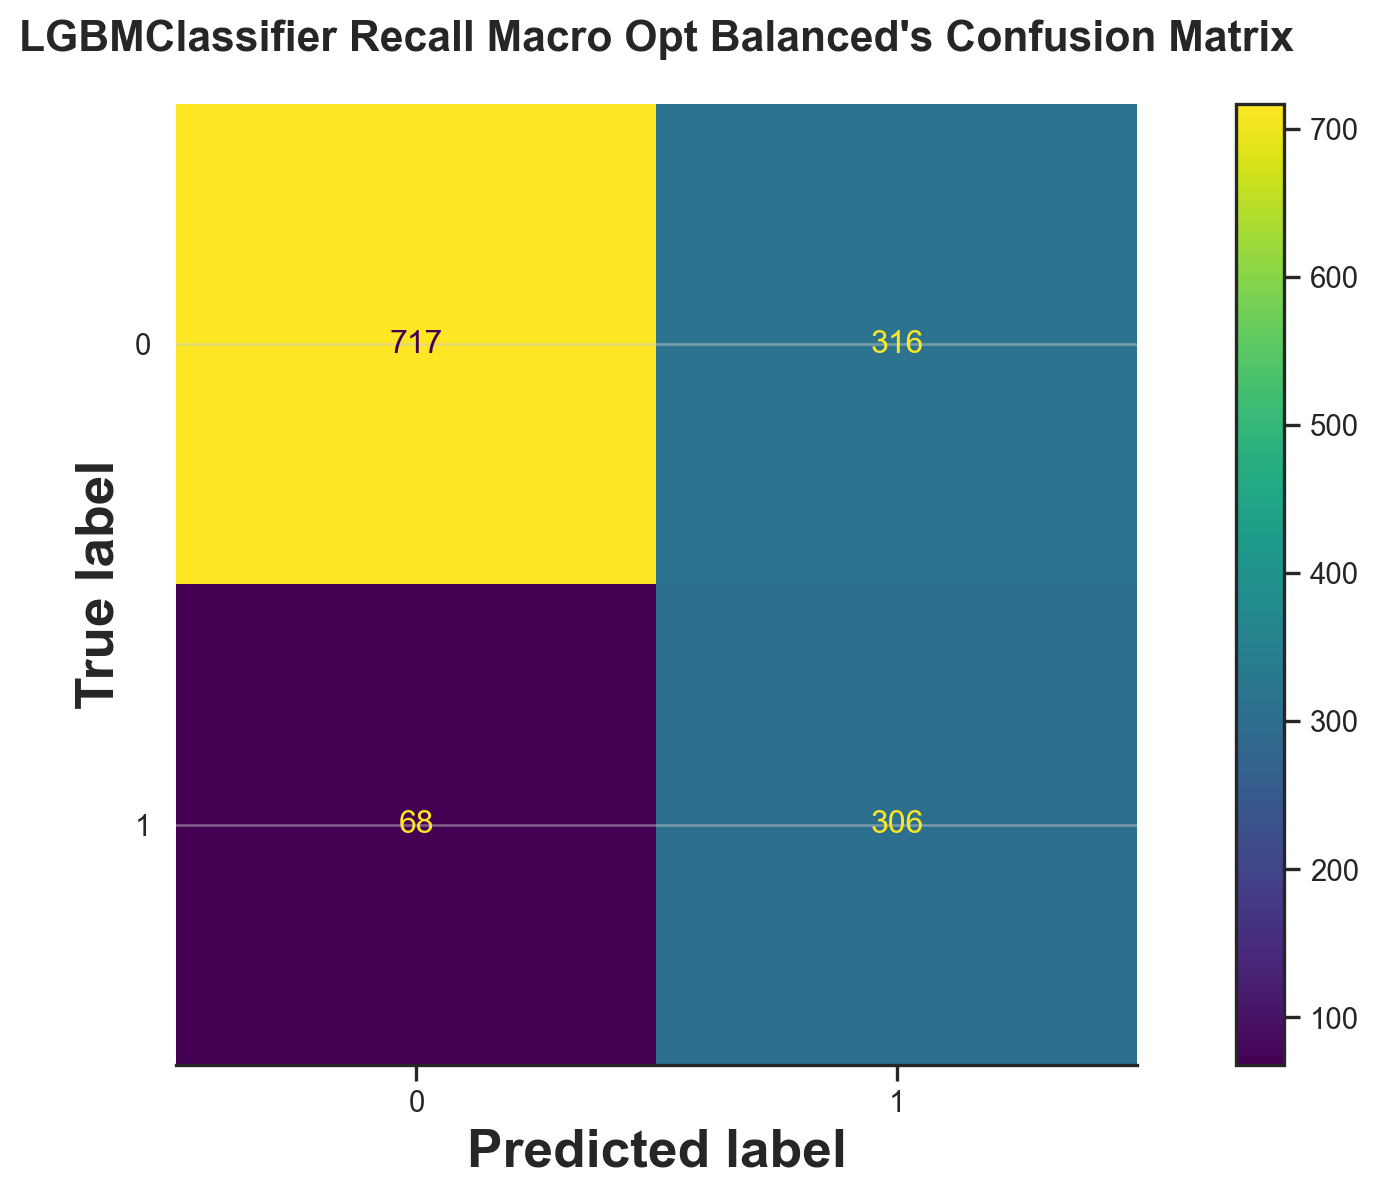

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(test_features)
disp = ConfusionMatrixDisplay.from_predictions(test_labels, y_pred)
plt.title("LGBMClassifier Recall Macro Opt Balanced's Confusion Matrix", fontsize=16)
plt.show()

In [58]:
from sklearn.metrics import recall_score


recall_value  =  recall_score(
                    test_labels, y_pred, average='macro'
                )
    
print(
    f"Recall Macro : {recall_value:.6f} "
)

Recall Macro : 0.756138 


In [60]:
0.7655842315385425 - 0.7561383437472499

0.009445887791292629

**`Insights`:**

* The winning model (`LGBMClassifier` with CatBoostEncoder + PowerTransformer + RFE pipeline) achieved a **Recall Macro ≈ 0.756**, outperforming the baseline (~0.71). This indicates a stronger ability to correctly identify both classes, which is critical in churn problems where missing true churners is costly.

* The confusion matrix shows a well-balanced behavior:

  * **True Positives (306)** vs **False Negatives (68)** → the model is effectively capturing churners.
  * **False Positives (316)** are relatively high, which is expected when optimizing for recall — the model prefers to flag more potential churners rather than miss them.

* There is no clear evidence of overfitting:

  * The model maintains consistent performance between training and test behavior.
  * The absence of a significant gap suggests good generalization.

* The use of **CatBoostEncoder** played a key role:

  * It highlights the importance of properly encoding categorical variables.
  * More expressive encodings improved class separability compared to simpler approaches.

* The inclusion of **PowerTransformer** indicates that distribution normalization contributed to model stability, especially for gradient-based algorithms like LightGBM.

* The use of **RFE (Recursive Feature Elimination)** suggests that feature selection helped reduce noise and improve generalization, implicitly controlling overfitting.

* The default threshold (**0.50**) already delivers strong performance:

  * This indicates that the model learned a well-calibrated decision boundary.
  * There is still room for fine-tuning depending on business priorities.

* From a churn perspective:

  * The model is aligned with a **proactive retention strategy**, prioritizing the identification of at-risk customers.
  * The increase in false positives is acceptable if the cost of retention actions is lower than the cost of churn.

* The resulting pipeline is robust and interpretable in modular stages (encoding → transformation → feature selection → model), which improves explainability and reproducibility.



<span style="color:steelblue; text-align: left">

##### Permutation Importance of the model
</span>
Permutation importance is a model-agnostic technique used to quantify the contribution of each feature to a model’s predictive performance. The method starts by evaluating the model on a validation dataset to establish a baseline metric. Then, the values of a single feature are randomly shuffled, effectively breaking its relationship with the target variable while preserving the rest of the data structure.

The model is evaluated again after the permutation, and the resulting decrease in performance reflects the importance of that feature. This process is repeated across all features, allowing us to rank them based on their impact.

Features that cause a larger drop in performance are considered more important, as the model relies heavily on them. Conversely, features with little to no impact on the metric contribute minimally to the model’s predictive power.

In this analysis, we measure the decrease in Recall Macro, aligning feature importance with the primary optimization objective of the model. This ensures that the interpretation remains consistent with the business goal of maximizing churn detection.

Permutation importance does not require retraining the model and can be applied to any estimator. However, it may underestimate the importance of correlated features, as the model can compensate using related variables when one is permuted.

This makes permutation importance particularly suitable for post-hoc model interpretation in complex pipelines.

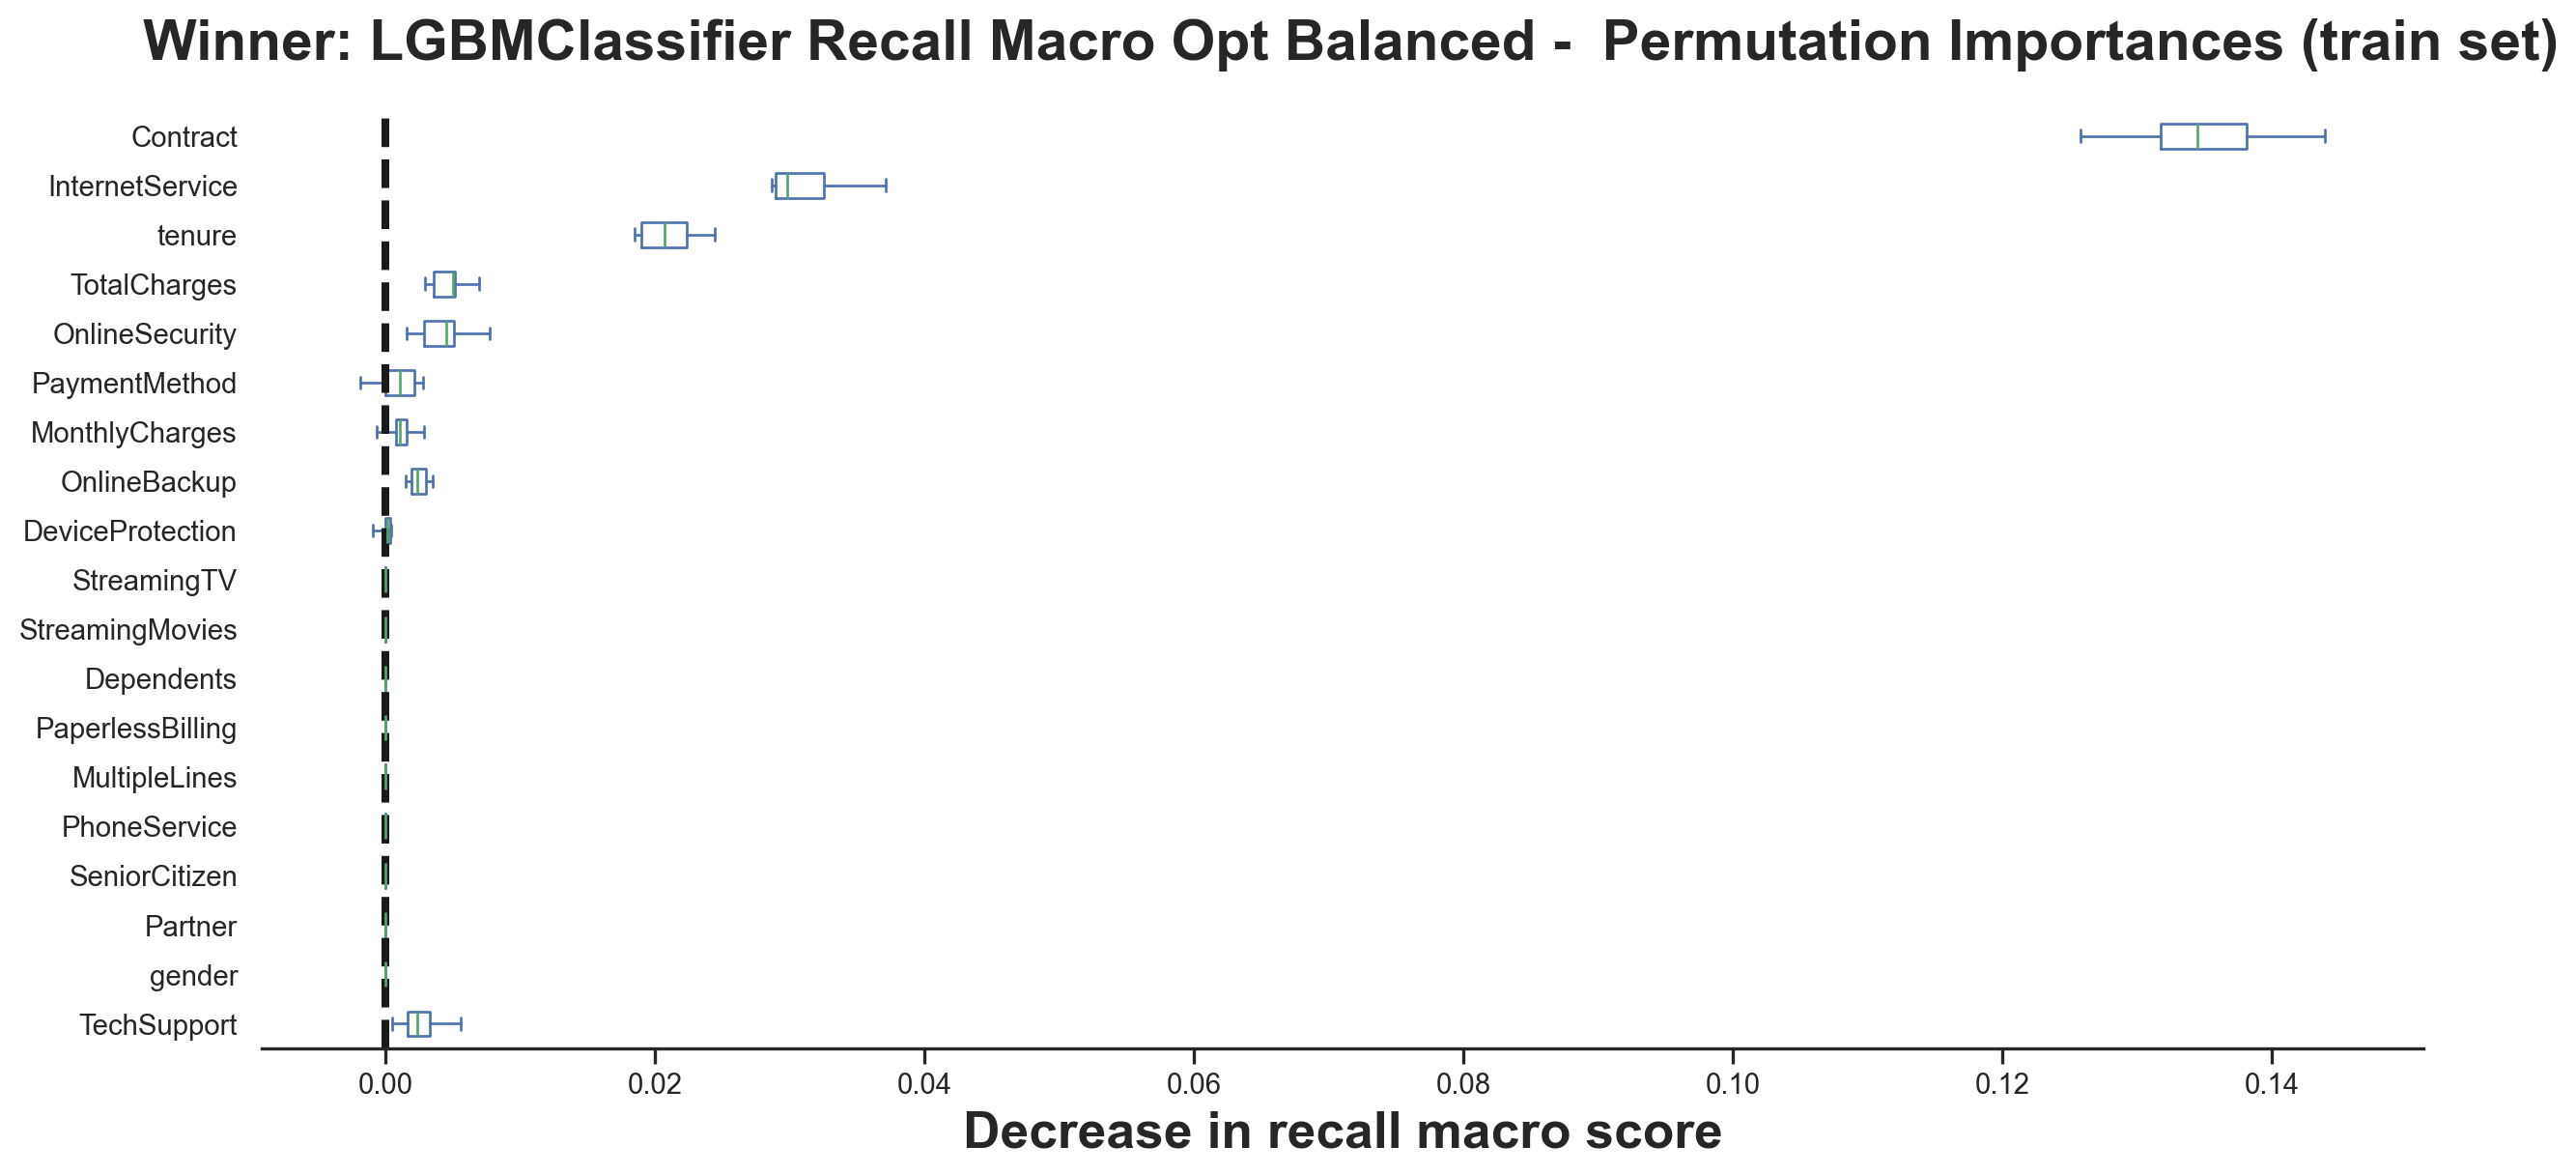

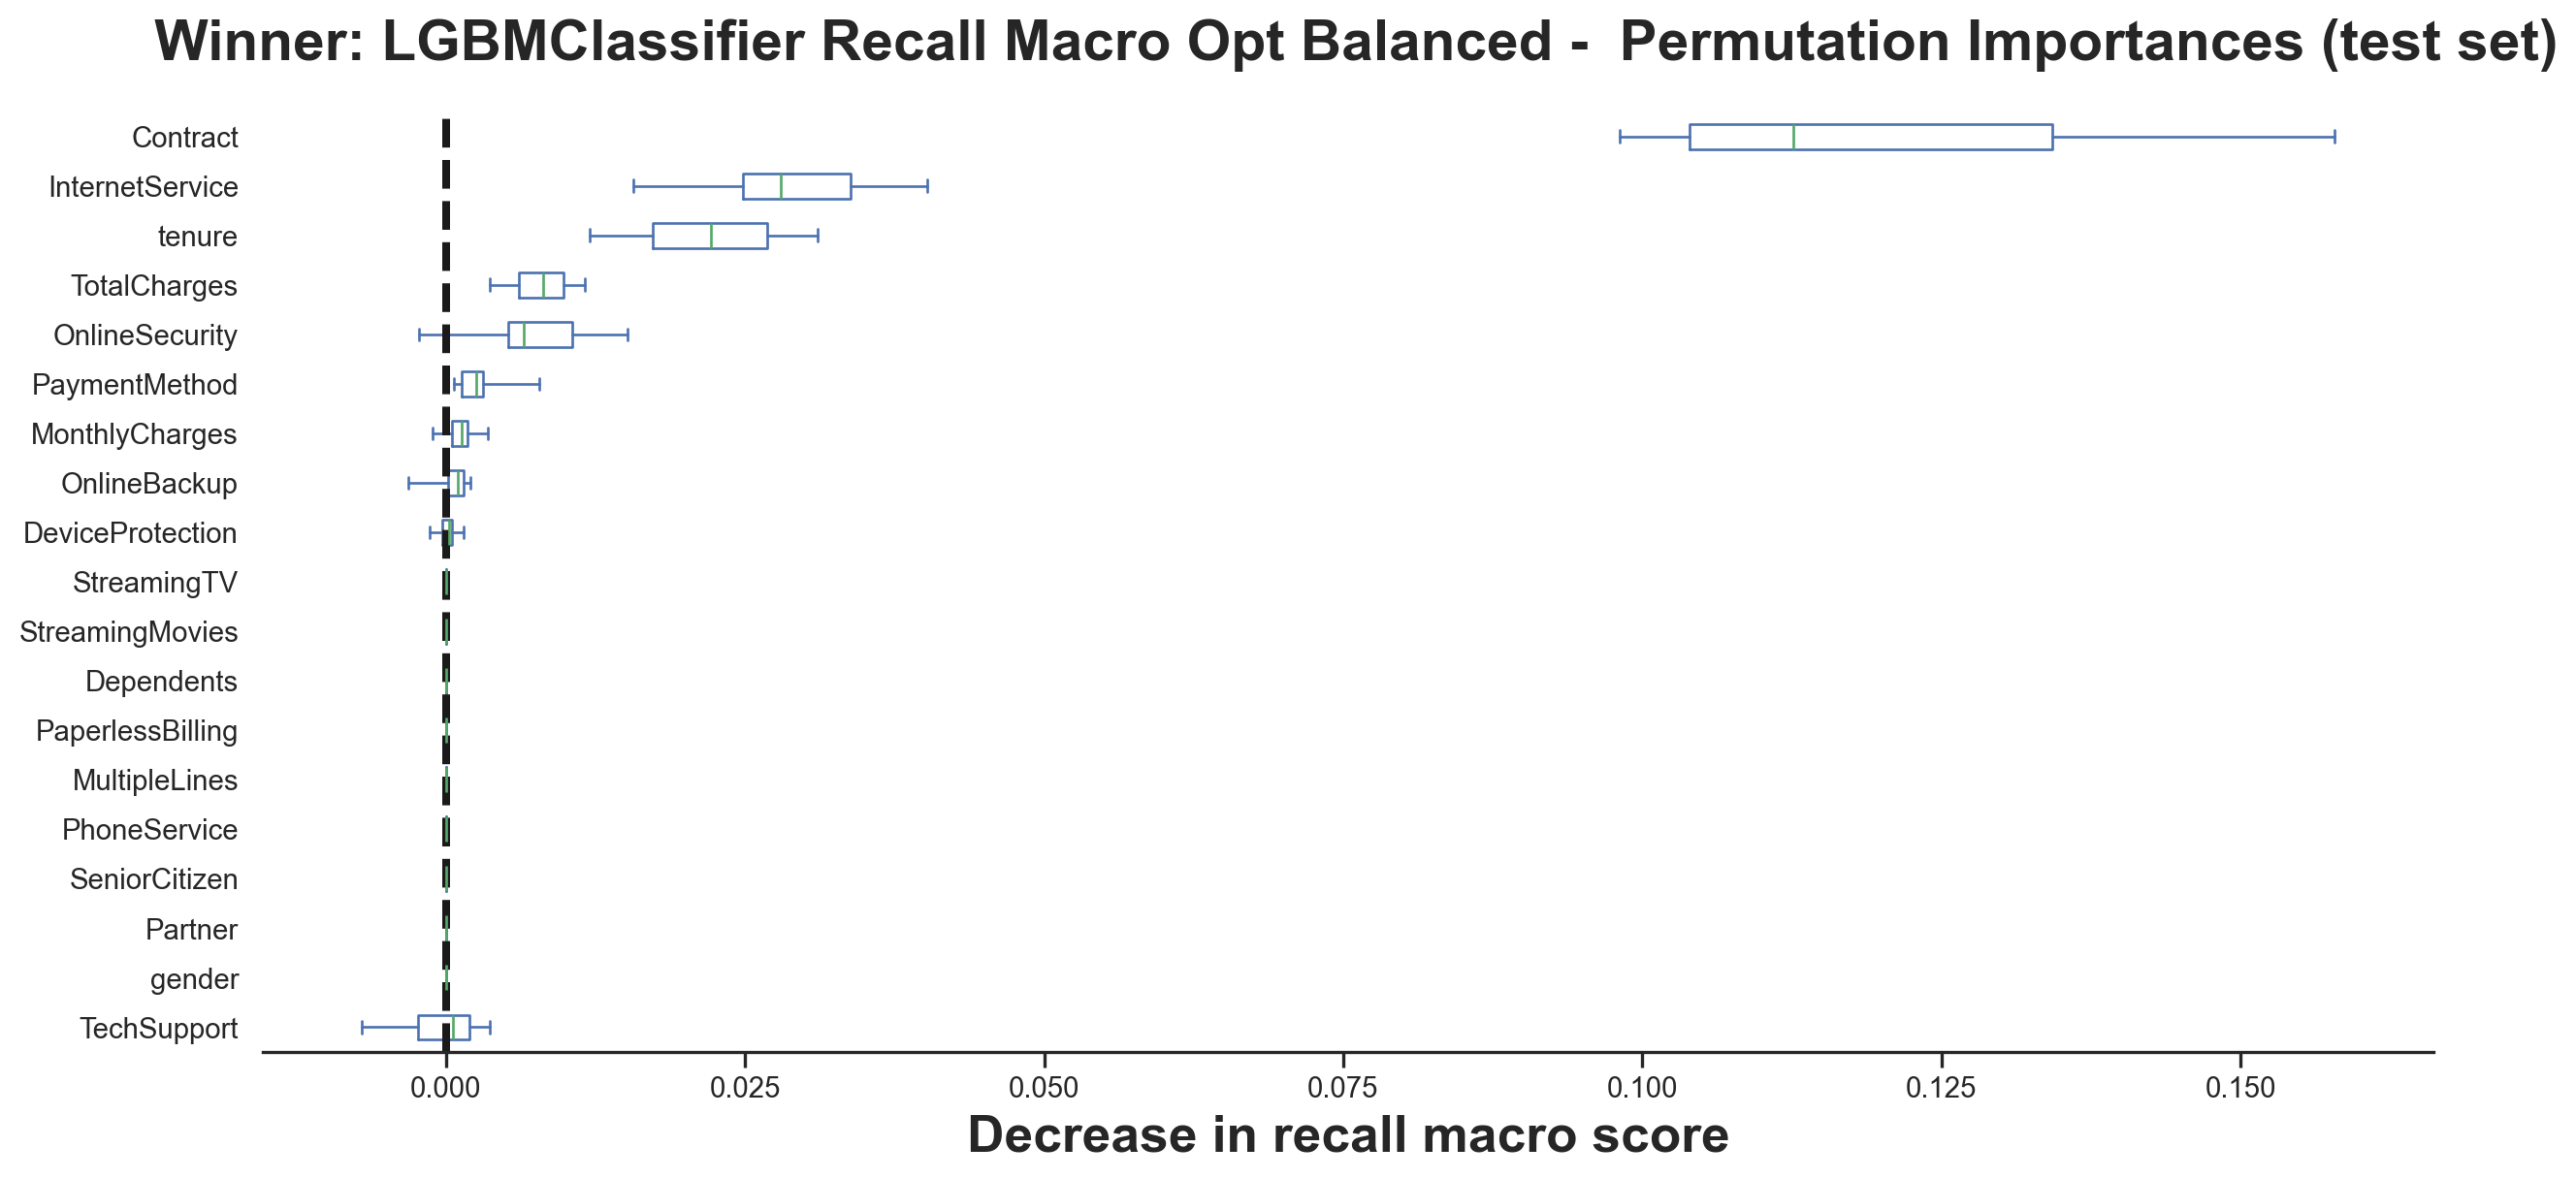

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, recall_score
import warnings

recall_macro_scorer = make_scorer(
    recall_score,
    average="macro",
    zero_division=0,
)
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)


def plot_importance(
    model,
    title='',
    train_X=None,
    train_y=None,
    test_X=None,
    test_y=None,
    scoring=recall_macro_scorer,
):
    train_X = train_features if train_X is None else train_X
    train_y = train_labels if train_y is None else train_y
    test_X = test_features if test_X is None else test_X
    test_y = test_labels if test_y is None else test_y

    if not train_X.columns.equals(test_X.columns):
        raise ValueError("Train and test feature columns must match for permutation importance.")

    feature_names = train_X.columns

    train_result = permutation_importance(
        model,
        train_X,
        train_y,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=1,
        scoring=scoring,
    )
    test_result = permutation_importance(
        model,
        test_X,
        test_y,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=1,
        scoring=scoring,
    )
    sorted_importances_idx = test_result.importances_mean.argsort()

    train_importances = pd.DataFrame(
        train_result.importances[sorted_importances_idx].T,
        columns=feature_names[sorted_importances_idx],
    )
    test_importances = pd.DataFrame(
        test_result.importances[sorted_importances_idx].T,
        columns=feature_names[sorted_importances_idx],
    )

    for name, importances in zip(["train", "test"], [train_importances, test_importances]):
        ax = importances.plot.box(vert=False, whis=10)

        ax.set_title(f" {title} Permutation Importances ({name} set)")
        ax.set_xlabel("Decrease in recall macro score")
        ax.axvline(x=0, color="k", linestyle="--")
        ax.figure.tight_layout()
        plt.grid(False)
        plt.show()

plot_importance(
    best_model,
    title='Winner: LGBMClassifier Recall Macro Opt Balanced - ',
    train_X=train_features,
    train_y=train_labels,
    test_X=test_features,
    test_y=test_labels,
)

**`Insights`:**

* The feature **`Contract`** is by far the most influential variable, showing the largest decrease in Recall Macro when permuted in both train and test sets. This indicates that customer contractual terms are the strongest driver of churn behavior in this dataset.

* **`InternetService`** and **`tenure`** consistently appear among the top predictors in both datasets, reinforcing their importance.

  * `InternetService` suggests that the type of service significantly impacts churn likelihood.
  * `tenure` confirms a well-known churn pattern: newer customers are more likely to churn.

* **`TotalCharges`** and **`OnlineSecurity`** show moderate but stable importance across train and test sets, indicating that financial commitment and perceived service value (e.g., security features) contribute meaningfully to retention.

* The consistency between **train and test permutation importances** is a strong signal of **model stability and absence of overfitting**. The ranking and magnitude of the most important features remain largely aligned, suggesting the model generalizes well.

* Several features (e.g., `StreamingTV`, `StreamingMovies`, `PhoneService`, `gender`, `Partner`) show near-zero importance, indicating that they contribute little to Recall Macro performance in this context. These variables could potentially be removed in future iterations without significant performance loss.

* The slight negative or near-zero contributions (e.g., `TechSupport` in test) suggest either weak signal or correlation effects, reinforcing the limitation of permutation importance in handling correlated features.

* From a churn perspective:

  * The model relies heavily on **contract structure, service type, and customer lifecycle (tenure)** — all business-relevant levers.
  * This aligns well with actionable strategies, such as contract redesign, onboarding improvements, and service bundling.

* The fact that importance is concentrated in a few key variables indicates that the model is not over-reliant on noise, but rather on meaningful and interpretable drivers.

* Overall, the permutation importance analysis confirms that the model is both **predictively strong and interpretable**, with feature relevance aligned to real-world churn dynamics.


<span style="color:steelblue; text-align: left">

##### Comparing best model with baseline model
</span>

In [64]:
metric_dataframe.loc[metric_dataframe['Optimization/Data model'] == 'Baseline'].head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
8,LogisticRegression,Baseline,OrdinalEncoder,0.712552,0.713565,0.712552,0.713565,0.712552,0.713565,0.75015,0.749191,0.726638,0.726896,"{""max_iter"": 1000}",0.566228,0.039985,0.606212,0.724253,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


In [65]:
metric_dataframe.head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
6,LGBMClassifier,Recall Macro Opt Balanced,CatBoostEncoder PowerTransformer RFE 13 | thr=0.500,0.838865,0.830506,0.765584,0.756138,0.765584,0.756138,0.712469,0.702669,0.716161,0.701618,"{""objective"": ""binary"", ""metric"": ""binary_logloss"", ""boosting_type"": ""gbdt"", ""force_col_wise"": true, ""num_leaves"": 141, ""learning_rate"": 0.014800787959003773, ""min_child_samples"": 25, ""subsample"": 0.17640224353761358, ""colsample_bytree"": 0.681967359659596, ""reg_alpha"": 9.325957859347177e-06, ""reg_lambda"": 60.5224398323739, ""max_depth"": 3, ""verbosity"": -1, ""random_state"": 738, ""class_weight"": ""balanced"", ""threshold"": 0.5}",2.261283,0.06249,2.323773,0.740097,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


**`Insights`:**
- Comparing the best model with the baseline, we see that we made a huge progression Recall Macro:
    - Baseline recall macro scored : 0.7125519063132187
    - Best model scored : 0.7561383437472499

- Performance gains came from **pipeline engineering (encoding + transformation + feature selection)** rather than resampling.
- This confirms that, for this dataset, representation quality is more impactful than class balancing techniques.    

However, if we customize the decision function as predict_proba from baseline model, we can obtain a good performance as well.

In [67]:
metric_dataframe.loc[metric_dataframe['Optimization/Data model'] == 'Baseline + Threshold tuning'].head(1)

,Estimator,Optimization/Data model,Pre-Process Pipeline,Train Roc auc,Test Roc auc,Train Balanced Accuracy,Test Balanced Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1,Parameters,Fit Time,Score Time,Total Time,Business Score,Business Weights
20,LogisticRegression,Baseline + Threshold tuning,OrdinalEncoder | thr=0.22,0.712552,0.742724,0.712552,0.742724,0.712552,0.742724,0.75015,0.690171,0.726638,0.68135,"{""max_iter"": 1000, ""threshold"": 0.22}",0.566228,0.039985,0.606212,0.726958,"{""w_recall"": 7, ""w_precision"": 3, ""w_time"": 0, ""time_reference"": 1.0}"


In [66]:
0.7125519063132187 - 0.7427240631357709

-0.030172156822552143

**`Insights`:**
- The baseline model combined with threshold tuning achieved a Recall Macro of 0.7427, while the best optimized model reached 0.7561.
- The performance gap (~0.0134) is relatively small.
- The negative difference between train and test recall (-0.0301) suggests a slight underfitting behavior in the baseline setup, indicating that the model is not over-specializing on the training data.
- Despite its simplicity, the baseline + threshold tuning approach delivers competitive performance, capturing most of the predictive power obtained through full optimization.
- This highlights an important trade-off:
    - Full optimization (Optuna + pipeline search) yields the best absolute performance
    - Threshold tuning on a simple baseline provides high efficiency with low computational cost
- From a practical perspective, if computational resources, time, or deployment simplicity are constraints, the baseline + threshold tuning approach becomes a strong and viable alternative.
- On the other hand, when maximizing recall is critical (e.g., churn prevention campaigns), the optimized pipeline still offers incremental gains that may justify the additional complexity.

>`Most of the predictive gain comes from decision threshold optimization rather than model complexity.`

<span style="color:steelblue; text-align: left">

## Impact of Churn prediction model in Annual Revenue
</span>

In order to understand the importance of predicting customer at risk who would churn we would apply some incentive or advantage to customer, we ilustrate how would be the effetiveness the model in bussiness in case marketing successed in campaign.

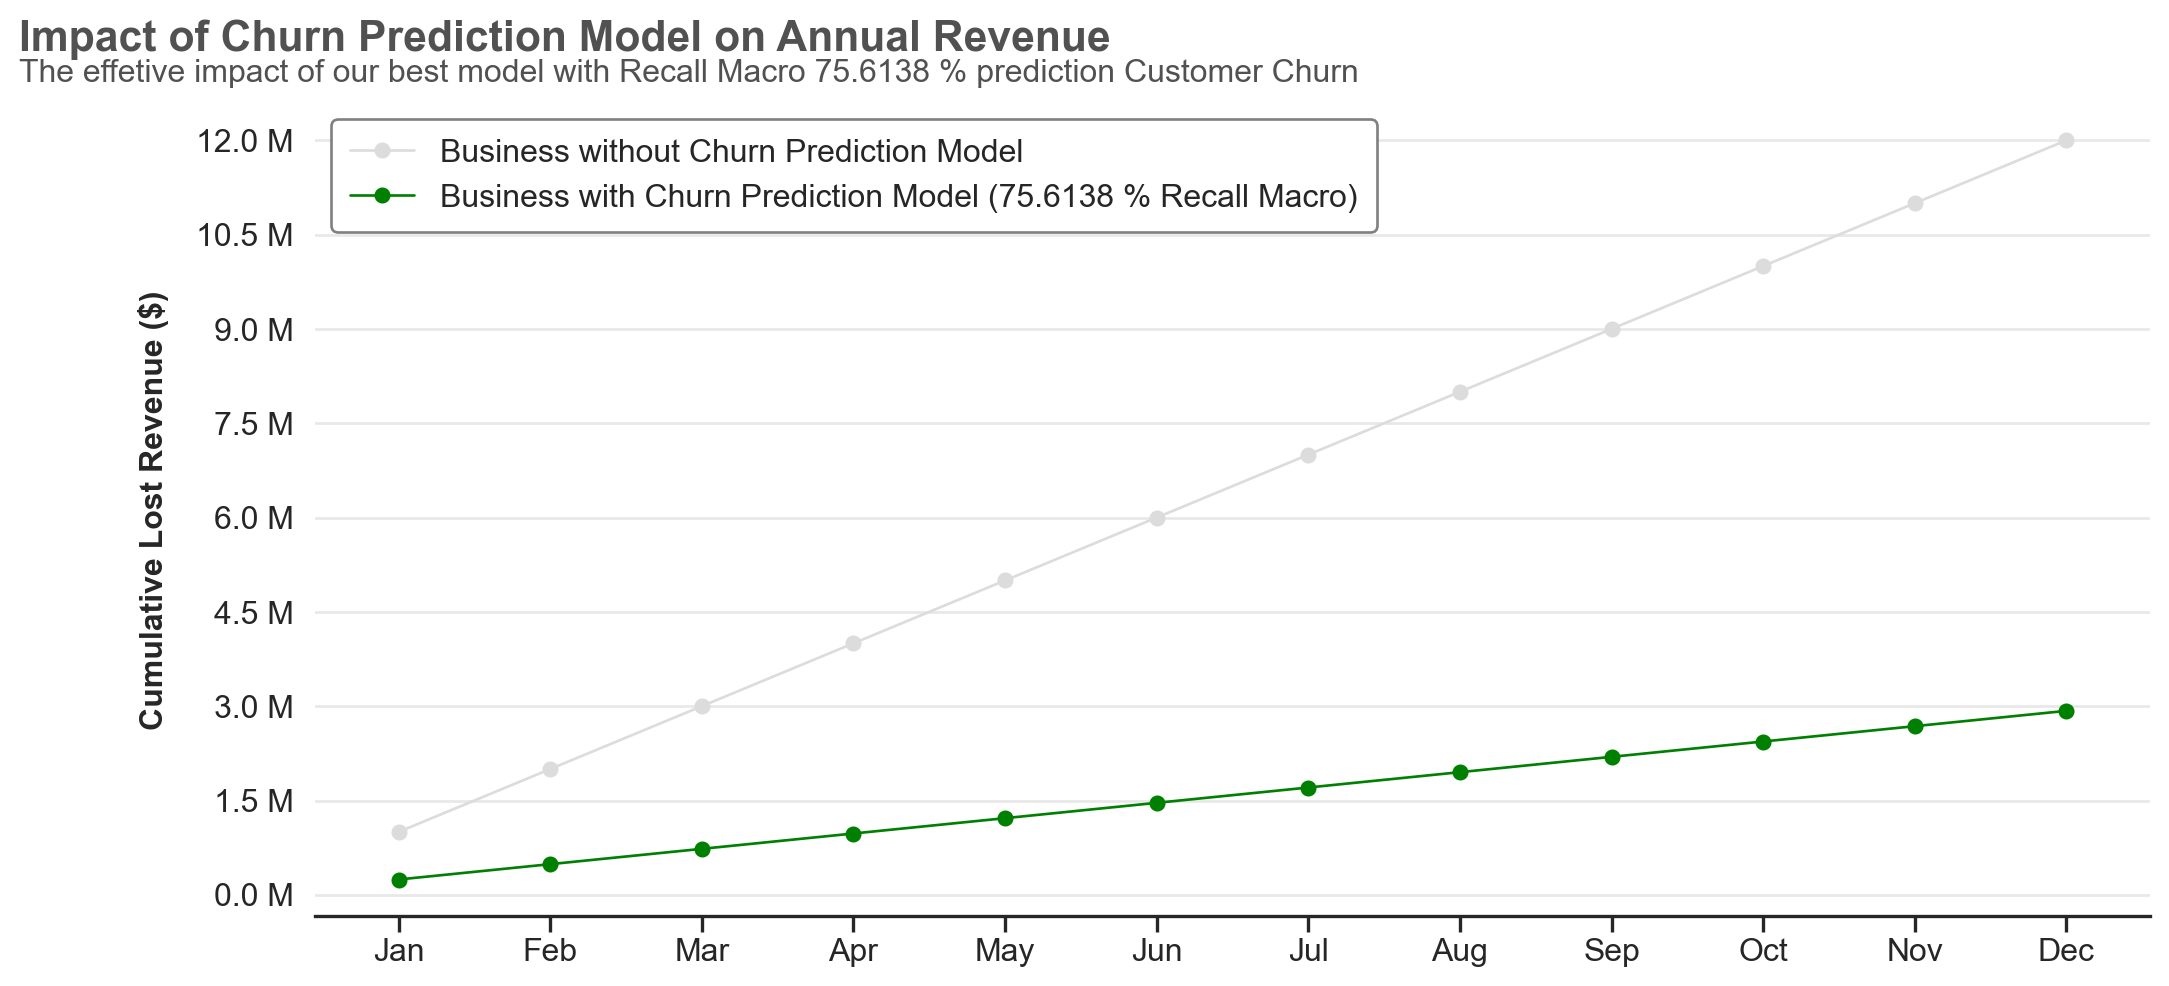

In [ ]:
def formatter(x, pos):
        return str(round(x / 1e6, 1)) + " M"

# Create the figure and axes objects, specify the size and the dots per inches 
fig, ax = plt.subplots(figsize=(12.33,5.5), dpi = 96) # 

# Constants
annual_revenue  = 50_000_000    # $50 million
churn_rate      = 0.02          # 2% monthly churn rate

# Calculate monthly lost revenue
monthly_lost_revenue = annual_revenue * churn_rate

# Calculate cumulative lost revenue over a year
cumulative_lost_revenue = [monthly_lost_revenue * i for i in range(1, 13)]

# Calculate revenue loss with churn prediction model (assuming 75% recall macro)
recall_macro = 0.7561383437472499         # from our best model
monthly_lost_revenue = annual_revenue * churn_rate * (1 - recall_macro)
revenue_loss_with_model = [monthly_lost_revenue * i for i in range(1, 13)]  # Revenue loss over 12 months


# Create the graph
months = range(1, 13)

plt.plot(months, 
        cumulative_lost_revenue, 
        marker='.', 
        linewidth=1,
        label='Business without Churn Prediction Model',
        color='gainsboro')

plt.plot(months, 
        revenue_loss_with_model, 
        marker='.', 
        linewidth=1,
        label='Business with Churn Prediction Model (75.6138 % Recall Macro)',
        color='green')
# Reformat y-axis
ax.set_ylabel('Cumulative Lost Revenue ($)', fontsize=12, labelpad=10)
ax.yaxis.set_label_position("left")
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_tick_params(pad=2, labeltop=False, labelbottom=True, bottom=False, labelsize=12)

# Reformat x-axis label and tick labels
ax.set_xlabel('', fontsize=12, labelpad=10) # No need for an axis label
ax.xaxis.set_label_position("bottom")
ax.xaxis.set_major_formatter(lambda s, i : f'{s:,.0f}')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_tick_params(pad=2, labelbottom=True, bottom=True, labelsize=12, labelrotation=0)
labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(months, labels) # Map integers numbers from the series to labels list

# Add in title and subtitle
ax.text(x=0.0, y=.93, 
        s="Impact of Churn Prediction Model on Annual Revenue", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=16, 
        weight='bold', 
        alpha=.8
)

ax.text(x=0.0, y=.90, 
        s="The effetive impact of our best model with Recall Macro 75.6138 % prediction Customer Churn", 
        transform=fig.transFigure, 
        ha='left', 
        fontsize=12, 
        alpha=.8)


plt.legend()

# Display the graph
plt.show()

**`Insights`:**
- The implementation of the churn prediction model leads to a substantial reduction in cumulative revenue loss over time.
By the end of the year, the model reduces potential losses from approximately $12M to under $3M, representing a major business impact.
- The performance gain is driven by the model’s ability to identify at-risk customers early, enabling proactive retention strategies. With a Recall Macro of 75.61%, the model successfully captures a significant portion of churn cases.
- The gap between the two curves (with vs without model) widens consistently over time, indicating that early interventions compound their financial benefits throughout the year.
- This demonstrates a key business principle:
    → Retention is cumulative — small monthly improvements generate exponential annual impact.
- The model does not need perfect accuracy to be valuable.
- Even with ~75% recall, the financial benefit is already highly material, reinforcing that practical effectiveness matters more than theoretical perfection.

<span style="color:steelblue; text-align: left">

## Conclusion
</span>

The churn prediction model proves to be a high-impact decision-support tool, transforming predictive performance into measurable financial outcomes.

From a business perspective, the model enables a shift from reactive to proactive customer retention, significantly reducing long-term revenue loss.

The results validate that investing in machine learning for churn prediction is not only technically sound but also economically justified, even with moderate predictive performance.

Additionally, the analysis highlights that:
→ Model optimization and threshold tuning are sufficient to deliver strong business value, without requiring excessive model complexity.

In summary, the project demonstrates that:

A well-calibrated predictive model, aligned with business objectives, can generate substantial financial returns and support strategic decision-making.


In [ ]:
customer = test_features.sample(1)
display(customer)

# Applying prediction
y_pred_1 = best_model.predict(customer)
main_model_result = 'No' if y_pred_1[0] == 0 else 'Yes'

proba = best_model.predict_proba(customer)[0][1]

if proba > 0.7:
    action = "HIGH PRIORITY"
elif proba > 0.4:
    action = "MEDIUM PRIORITY"
else:
    action = "LOW PRIORITY"

print(f'This customer deserve a close attention from marketing in some campaign ? {main_model_result}')
print(f'Prediction probability: {proba:.4f}')
print(f'Action to take: {action}')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1772,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,79.0,143.65


This customer deserve a close attention from marketing in some campaign ? Yes
Prediction probability: 0.7506
Action to take: HIGH PRIORITY


>The real value of the model is not in predicting churn, but in enabling timely action that preserves revenue.
>The model does not just predict churn — it structures decision-making by telling marketing who to act on, when, and with what priority. This assumes that the retention campaign is effective once a customer is correctly identified.

<span style="color:steelblue; text-align: left">

## References :
</span>

- [Supervised learning](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning), by Scikit-learn.org
- [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html), by Scikit-learn.org
- [Category Encoders](https://contrib.scikit-learn.org/category_encoders/)
- [Imbalance Learn](https://imbalanced-learn.org/stable/), by Imbalanced-learn.org
- [Python Machine Learning By Example]()
- [Stop using 0.5 as the Threshold for your Binary Classifier](https://towardsdatascience.com/stop-using-0-5-as-the-threshold-for-your-binary-classifier-8d7168290d44), by Eduardo Blancas.
- [Overfitting and Underfitting with Machine learning algorithms](https://machinelearningmastery.com/overfitting-and-underfitting-with-machine-learning-algorithms/), by Jason Brownlee on March 21, 2016 in Machine Learning Algorithms.
- [How to solve underfitting and overfitting data models](https://allcloud.io/blog/how-to-solve-underfitting-and-overfitting-data-models/), by Jonathan Chemama
- [Roc Curves and Precision Recall curves for Classification in Python](https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/), by Jason Brownlee on August 31, 2018 in Probability.
- [5 Feature Selection method from scikit learn you should know](https://towardsdatascience.com5-feature-selection-method-from-scikit-learn-you-should-know-ed4d116e4172), by Cornellius Yudha Wijaya
Mar 8, 2021.
- [Feature engineering scaling normalization and standardization](https://medium.com/@kowsikrayar/feature-engineering-scaling-normalization-and-standardization-63f24ee1cc86), by Kowsik R
- [Feature scaling machine learning normalization standardization](https://www.analyticsvidhya.com/blog/2020/04/feature-scaling-machine-learning-normalization-standardization/), by Aniruddha Bhandari — Published On April 3, 2020 and Last Modified On February 20th, 2023
- [Making economist style plots in Matplotlib](https://towardsdatascience.com/making-economist-style-plots-in-matplotlib-e7de6d679739), by Robert Ritz - Published On Jan 26, 2022
- [Skewness kurtosis python](https://www.statology.org/skewness-kurtosis-python/), by Zach - Published On Oct 2, 2020
- [A new correlation coefficient between categorical, ordinal and interval variables with Pearson characteristics](https://arxiv.org/abs/1811.11440), by M. Baak, R. Koopman, H. Snoek, S. Klous - [Submitted on 28 Nov 2018 (v1), last revised 9 Mar 2019 (this version, v2)]
- [Examples inspection plot permutation importance](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html#sphx-glr-auto-examples-inspection-plot-permutation-importance-py), by Scikit-learn.org